# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [ ]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib===3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 -q --user --no-warn-script-location

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

train_df = None
test_df = None

# Adjust the path if your file is in a specific subfolder within MyDrive
try:
    train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Train.csv')
    test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Test.csv')
    print('Train.csv and Test.csv loaded successfully.')
except FileNotFoundError:
    print("Error: Make sure 'Train.csv' and 'Test.csv' are in the root of your 'My Drive' or adjust the path.")
    print("Example: train_df = pd.read_csv('/content/drive/MyDrive/Your_Folder_Name/Train.csv')")

# Display the first 5 rows of the training data if loaded
if train_df is not None:
    print("\nFirst 5 rows of the training data:")
    display(train_df.head())

# Display the first 5 rows of the test data if loaded
if test_df is not None:
    print("\nFirst 5 rows of the test data:")
    display(test_df.head())

Train.csv and Test.csv loaded successfully.

First 5 rows of the training data:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0



First 5 rows of the test data:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


# **Data Overview**

In [ ]:
print('Shape of Training Data:', train_df.shape)
print('Shape of Test Data:', test_df.shape)

print('\nInfo of Training Data:')
train_df.info()

print('\nInfo of Test Data:')
test_df.info()

print('\nDescriptive Statistics of Training Data:')
display(train_df.describe())

print('\nDescriptive Statistics of Test Data:')
display(test_df.describe())

Shape of Training Data: (20000, 41)
Shape of Test Data: (5000, 41)

Info of Training Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000000,19982.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.271996,0.440430,2.484699,-0.083152,-0.053752,-0.995443,-0.879325,-0.548195,-0.016808,-0.012998,...,0.303799,0.049825,-0.462702,2.229620,1.514809,0.011316,-0.344025,0.890653,-0.875630,0.055500
std,3.441625,3.150784,3.388963,3.431595,2.104801,2.040970,1.761626,3.295756,2.160568,2.193201,...,5.500400,3.575285,3.183841,2.937102,3.800860,1.788165,3.948147,1.753054,3.012155,0.228959
min,-11.876451,-12.319951,-10.708139,-15.082052,-8.603361,-10.227147,-7.949681,-15.657561,-8.596313,-9.853957,...,-19.876502,-16.898353,-17.985094,-15.349803,-14.833178,-5.478350,-17.375002,-6.438880,-11.023935,0.000000
25%,-2.737146,-1.640674,0.206860,-2.347660,-1.535607,-2.347238,-2.030926,-2.642665,-1.494973,-1.411212,...,-3.420469,-2.242857,-2.136984,0.336191,-0.943809,-1.255819,-2.987638,-0.272250,-2.940193,0.000000
50%,-0.747917,0.471536,2.255786,-0.135241,-0.101952,-1.000515,-0.917179,-0.389085,-0.067597,0.100973,...,0.052073,-0.066249,-0.255008,2.098633,1.566526,-0.128435,-0.316849,0.919261,-0.920806,0.000000
75%,1.840112,2.543967,4.566165,2.130615,1.340480,0.380330,0.223695,1.722965,1.409203,1.477045,...,3.761722,2.255134,1.436935,4.064358,3.983939,1.175533,2.279399,2.057540,1.119897,0.000000
max,15.493002,13.089269,17.090919,13.236381,8.133797,6.975847,8.006091,11.679495,8.137580,8.108472,...,23.633187,16.692486,14.358213,15.291065,19.329576,7.467006,15.289923,7.759877,10.654265,1.000000



Descriptive Statistics of Test Data:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,4995.000000,4994.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,-0.277622,0.397928,2.551787,-0.048943,-0.080120,-1.042138,-0.907922,-0.574592,0.030121,0.018524,...,0.232567,-0.080115,-0.392663,2.211205,1.594845,0.022931,-0.405659,0.938800,-0.932406,0.056400
std,3.466280,3.139562,3.326607,3.413937,2.110870,2.005444,1.769017,3.331911,2.174139,2.145437,...,5.585628,3.538624,3.166101,2.948426,3.774970,1.785320,3.968936,1.716502,2.978193,0.230716
min,-12.381696,-10.716179,-9.237940,-14.682446,-7.711569,-8.924196,-8.124230,-12.252731,-6.785495,-8.170956,...,-17.244168,-14.903781,-14.699725,-12.260591,-12.735567,-5.079070,-15.334533,-5.451050,-10.076234,0.000000
25%,-2.743691,-1.649211,0.314931,-2.292694,-1.615238,-2.368853,-2.054259,-2.642088,-1.455712,-1.353320,...,-3.556267,-2.348121,-2.009604,0.321818,-0.866066,-1.240526,-2.984480,-0.208024,-2.986587,0.000000
50%,-0.764767,0.427369,2.260428,-0.145753,-0.131890,-1.048571,-0.939695,-0.357943,-0.079891,0.166292,...,-0.076694,-0.159713,-0.171745,2.111750,1.702964,-0.110415,-0.381162,0.959152,-1.002764,0.000000
75%,1.831313,2.444486,4.587000,2.166468,1.341197,0.307555,0.212228,1.712896,1.449548,1.511248,...,3.751857,2.099160,1.465402,4.031639,4.104409,1.237522,2.287998,2.130769,1.079738,0.000000
max,13.504352,14.079073,15.314503,12.140157,7.672835,5.067685,7.616182,10.414722,8.850720,6.598728,...,26.539391,13.323517,12.146302,13.489237,17.116122,6.809938,13.064950,7.182237,8.698460,1.000000


In [ ]:
# Convert the 'Target' column to float in train set
train_df['Target'] = train_df['Target'].astype(float)
# Convert the 'Target' column to float in test set
test_df['Target'] = test_df['Target'].astype(float)

In [ ]:
# Check for duplicates in the train data
train_df.duplicated().sum()

In [ ]:
# Check for duplicates in the test data
test_df.duplicated().sum()

In [ ]:
# Check for missing values in the train data
train_df.isnull().sum()

In [ ]:
# Check for missing values in the test data
test_df.isnull().sum()

In [ ]:
print('Distinct categories in Target column of training data:', train_df['Target'].unique())

# **Exploratory Data Analysis**

## Univariate analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of the Target variable in the training data
plt.figure(figsize=(6, 4))
sns.histplot(train_df['Target'], bins=2, kde=False)
plt.title('Distribution of Target Variable in Training Data')
plt.xticks([0, 1], labels=['No Failure (0)', 'Failure (1)'])
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None, title=''):
    """
    Function to draw a combined histogram and boxplot for a given feature.

    Args:
        data (pd.DataFrame): The DataFrame containing the feature.
        feature (str): The name of the feature to plot.
        figsize (tuple): Figure size for the plot.
        kde (bool): Whether to plot a kernel density estimate in the histogram.
        bins (int, optional): Number of bins for the histogram.
        title (str): Title for the plot.
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(nrows=2, # Number of rows of the subplot grid
                                           sharex=True, # x-axis will be shared among all subplots
                                           gridspec_kw={"height_ratios": (0.25, 0.75)}, # The ratio of the height of each row
                                           figsize=figsize # Size of the figure
                                          )
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color='skyblue') # Boxplot will be drawn on the top subplot

    if bins is None:
        # Let seaborn determine the number of bins automatically when bins is None
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, color='lightcoral')
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, color='lightcoral') # Use provided bins

    ax_hist2.axvline(data[feature].mean(), color='green', linestyle='--', label='Mean') # Add mean as a vertical line in the histogram
    ax_hist2.axvline(data[feature].median(), color='red', linestyle='-', label='Median') # Add median as a vertical line in the histogram
    ax_hist2.legend()
    ax_box2.set(xlabel='')
    if title:
        f2.suptitle(title, fontsize=16) # Set the title for the entire figure
    else:
        f2.suptitle(f'Distribution of {feature}', fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of the Target variable in the testing data
plt.figure(figsize=(6, 4))
sns.histplot(test_df['Target'], bins=2, kde=False)
plt.title('Distribution of Target Variable in Testing Data')
plt.xticks([0, 1], labels=['No Failure (0)', 'Failure (1)'])
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

In [ ]:
train_df["Target"].value_counts(1)

In [ ]:
test_df['Target'].value_counts(1)

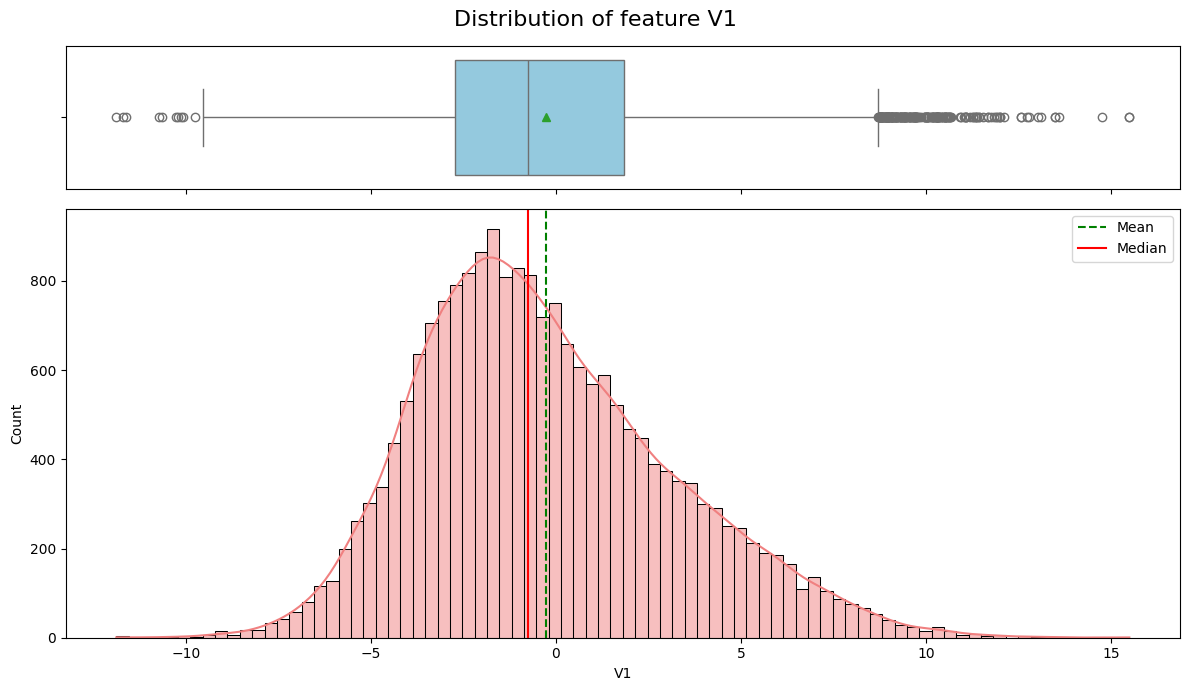

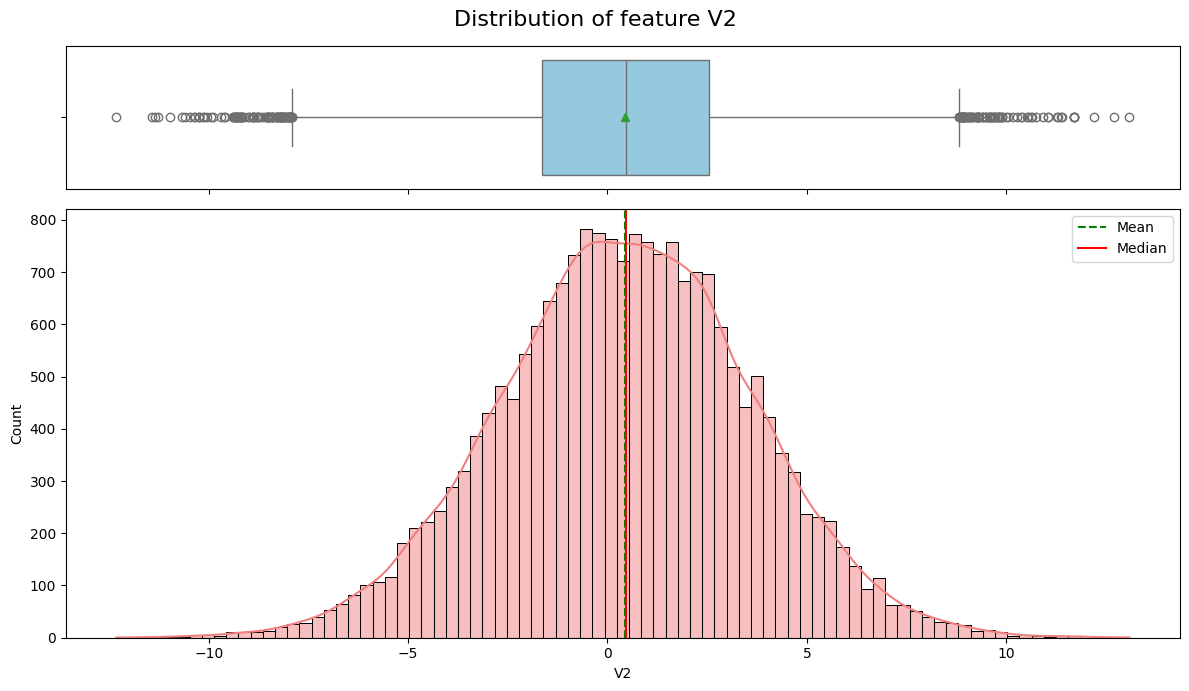

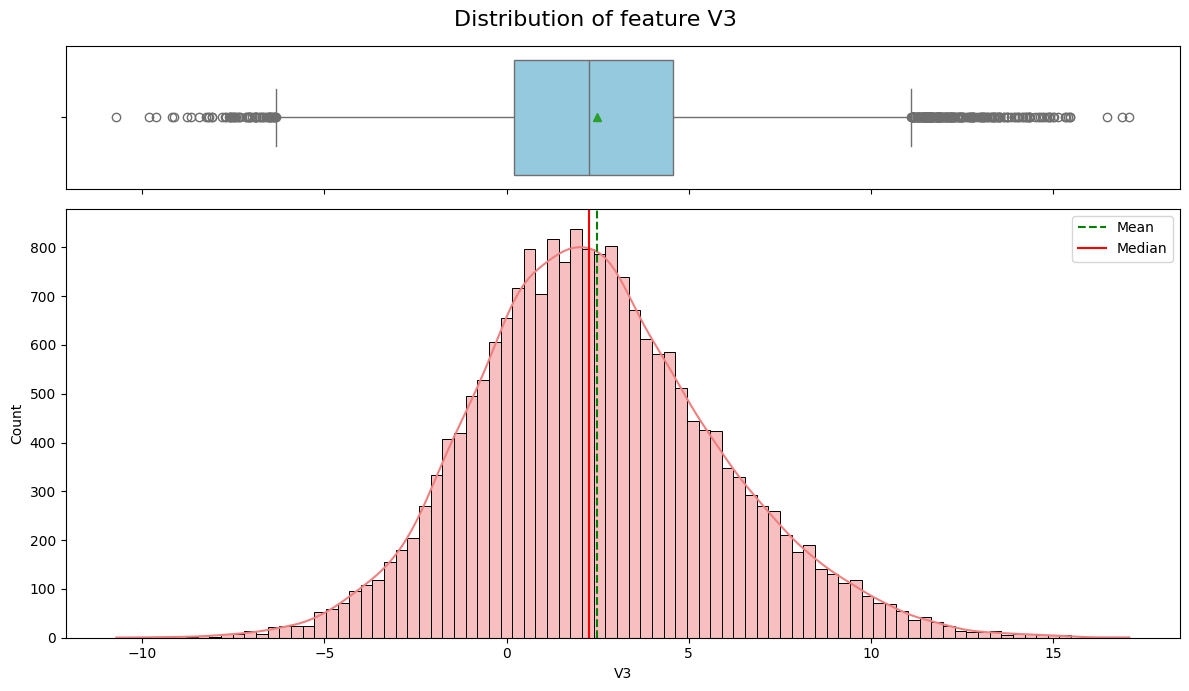

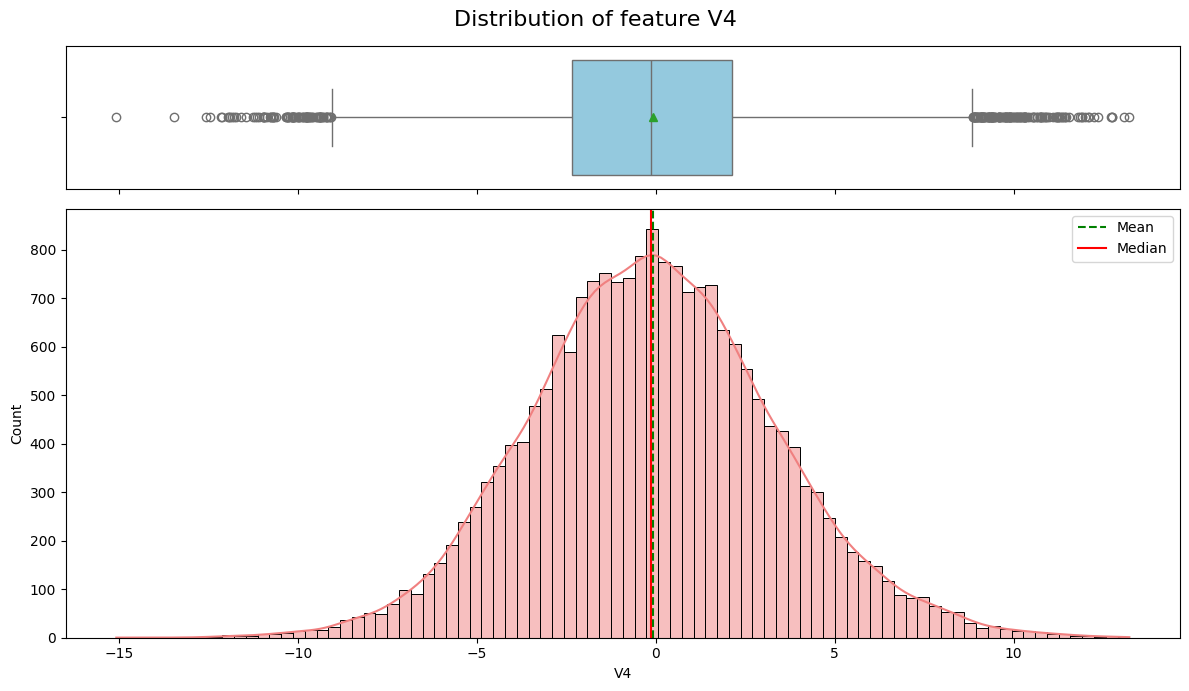

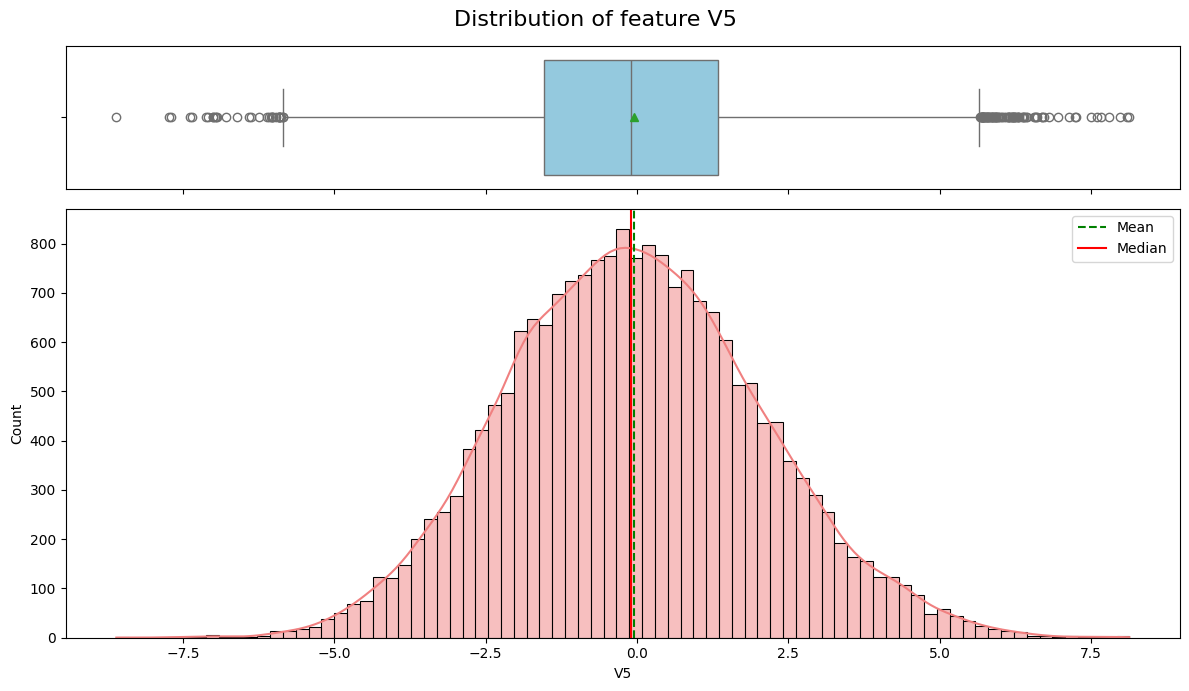

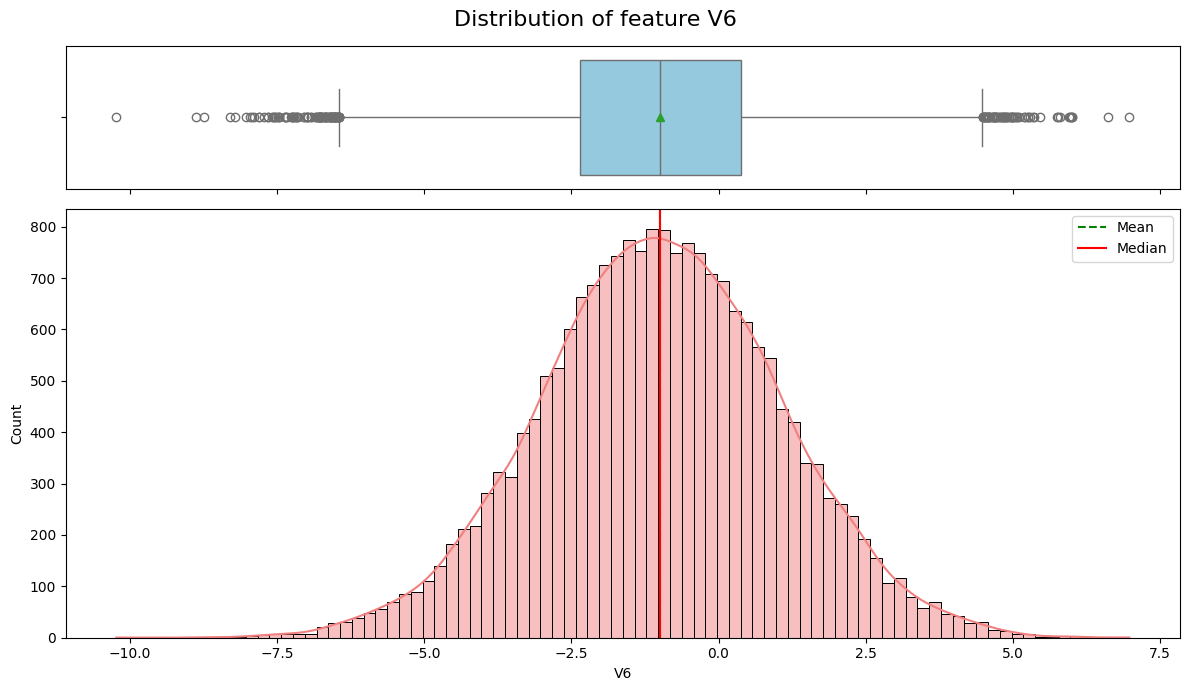

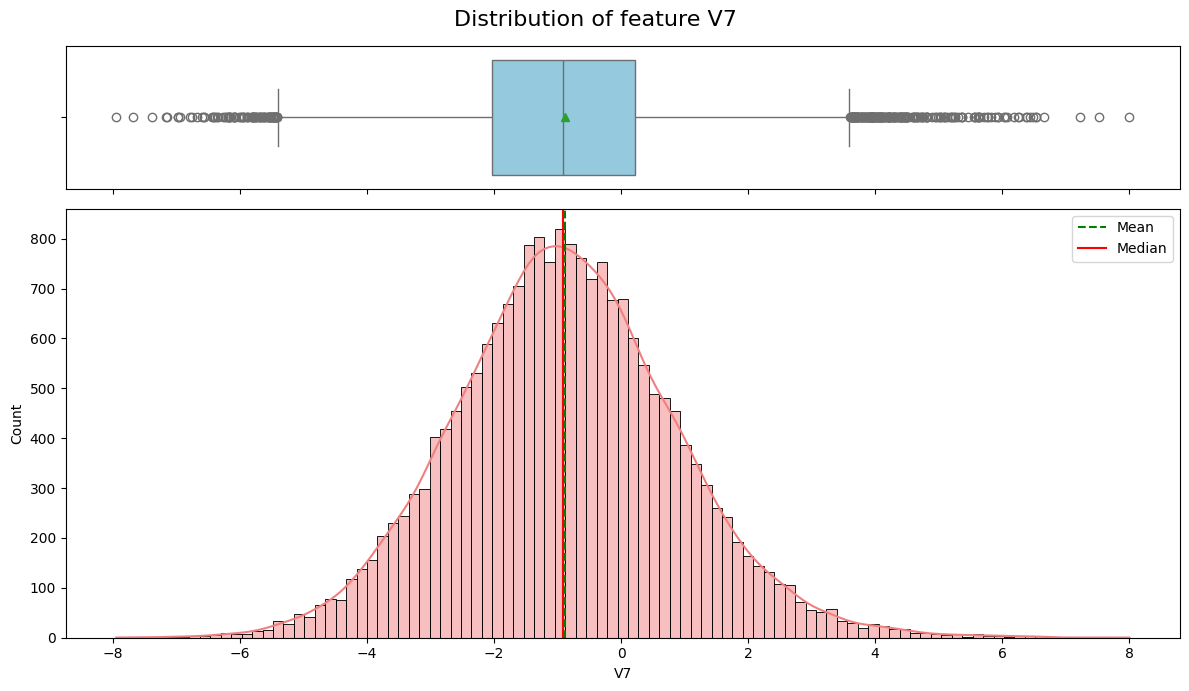

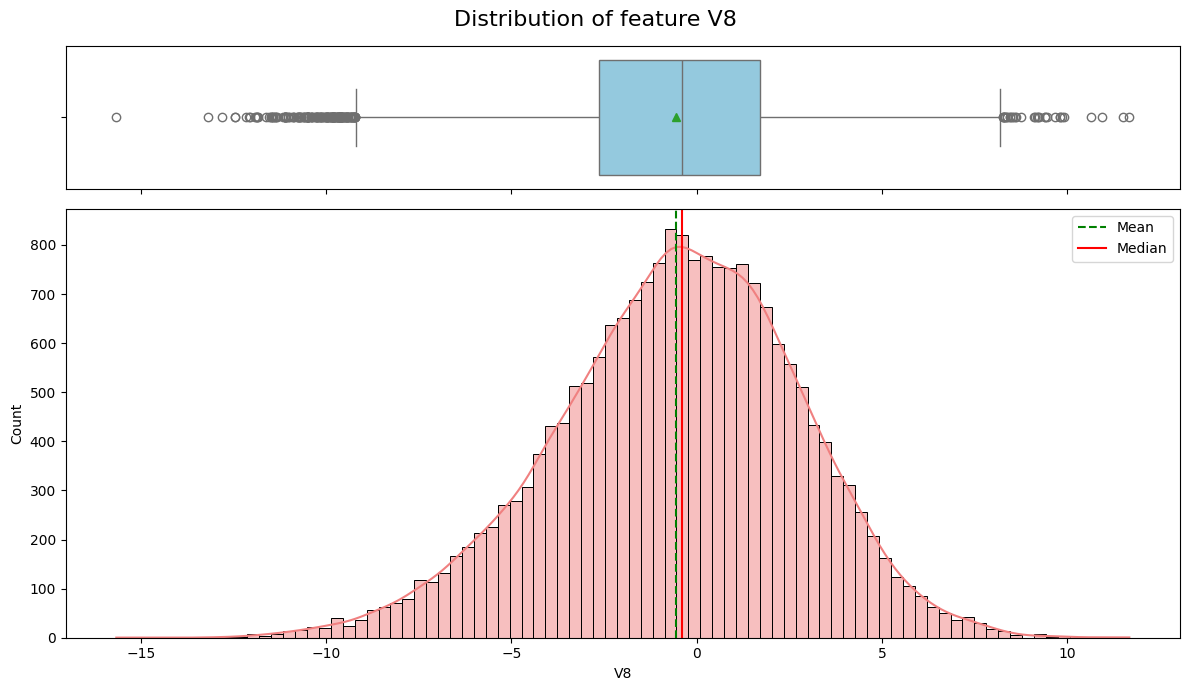

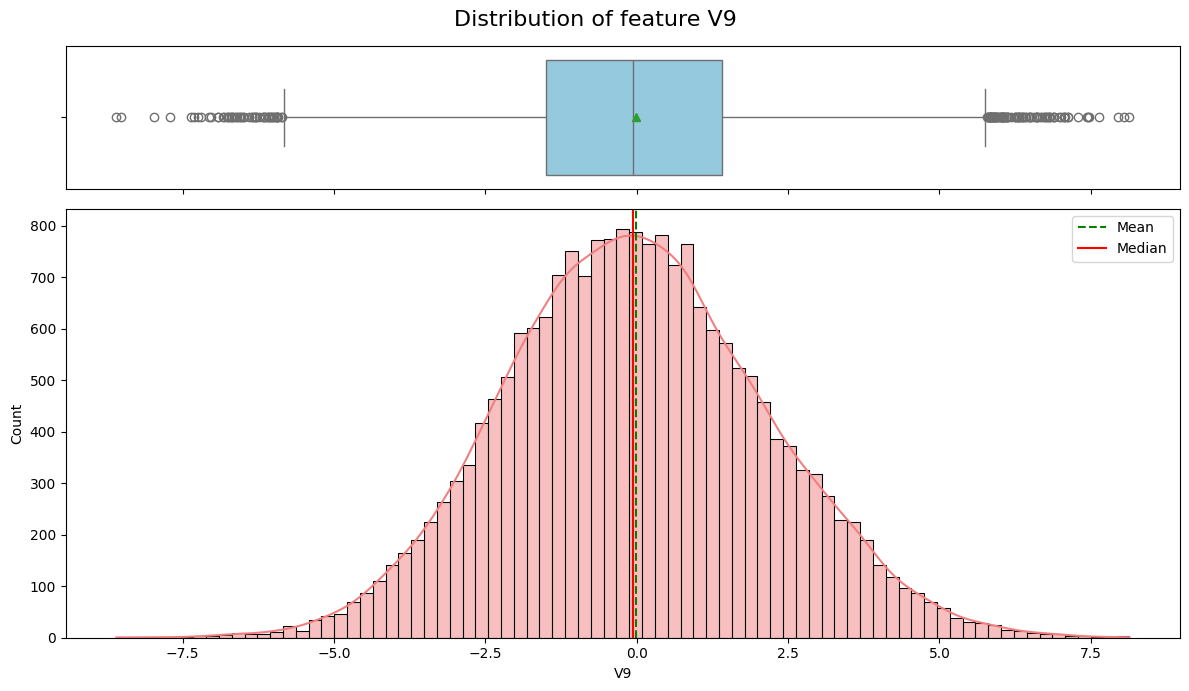

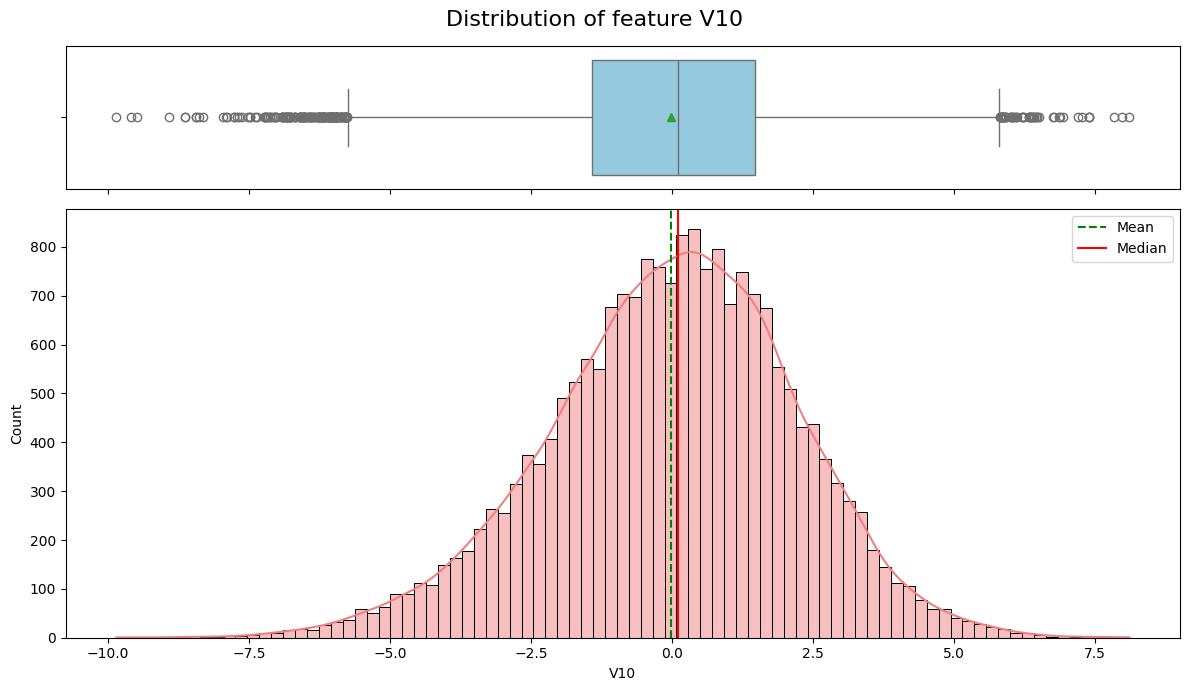

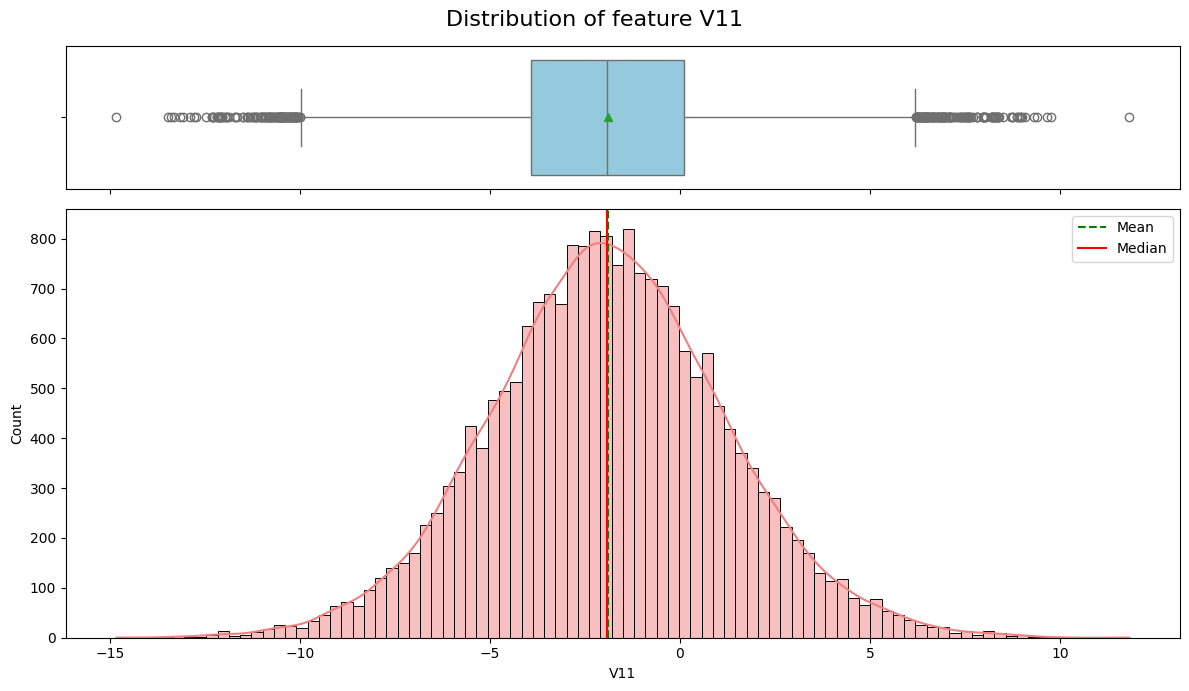

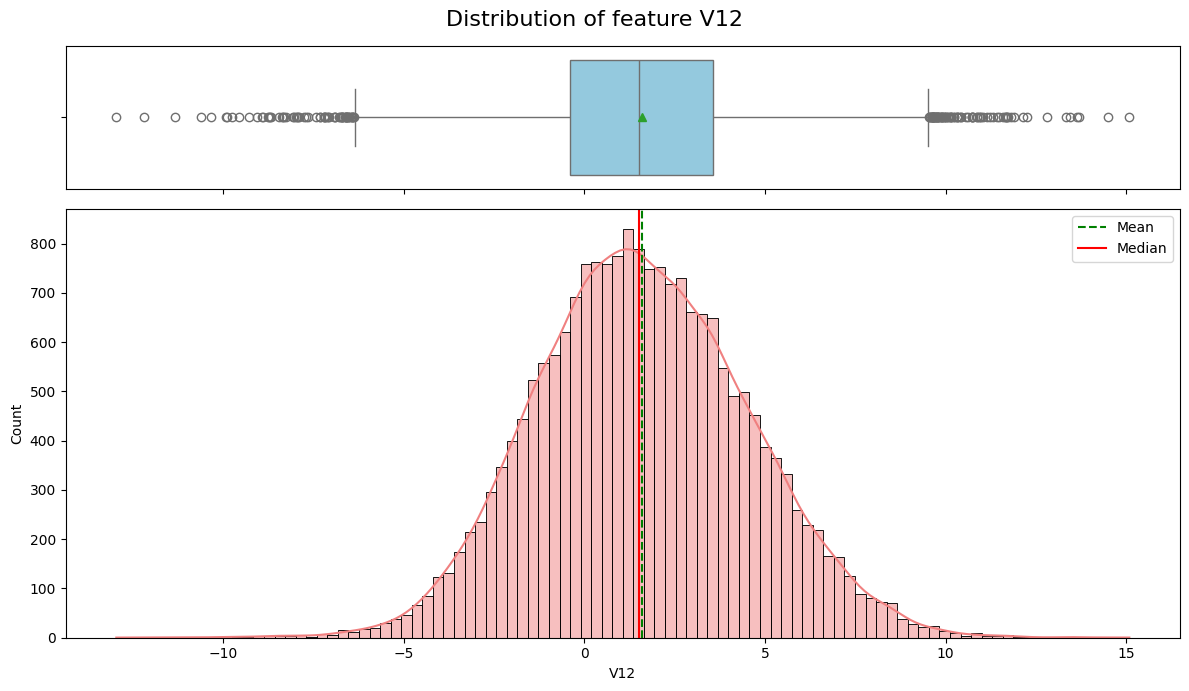

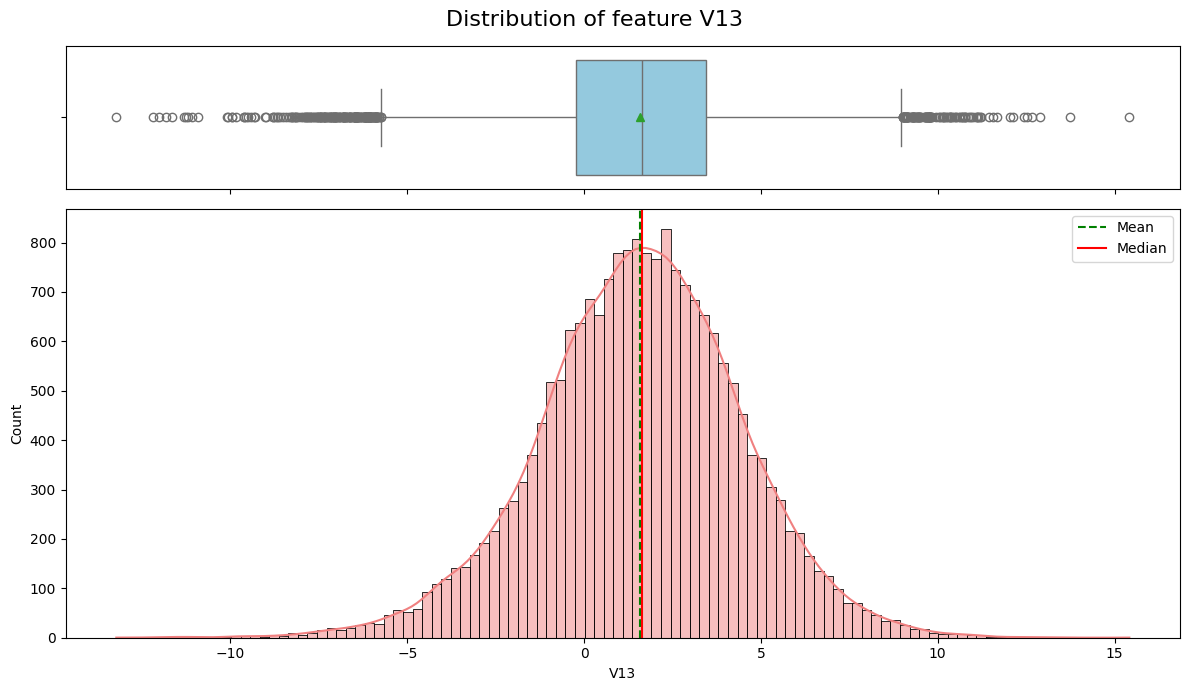

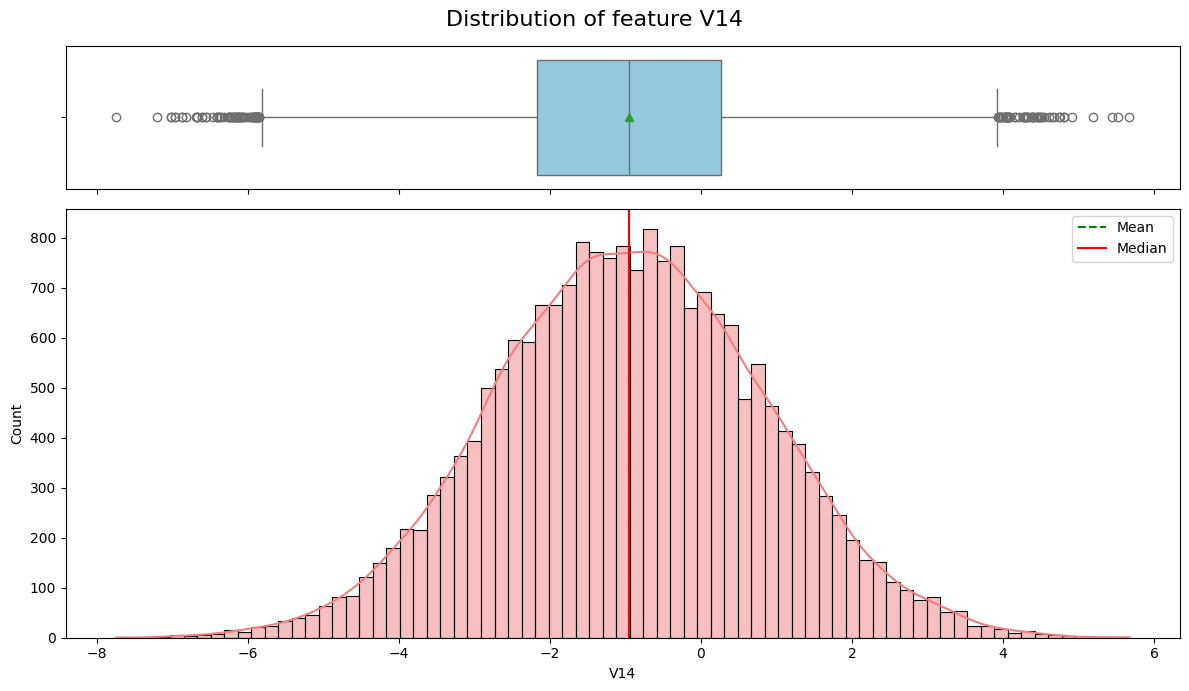

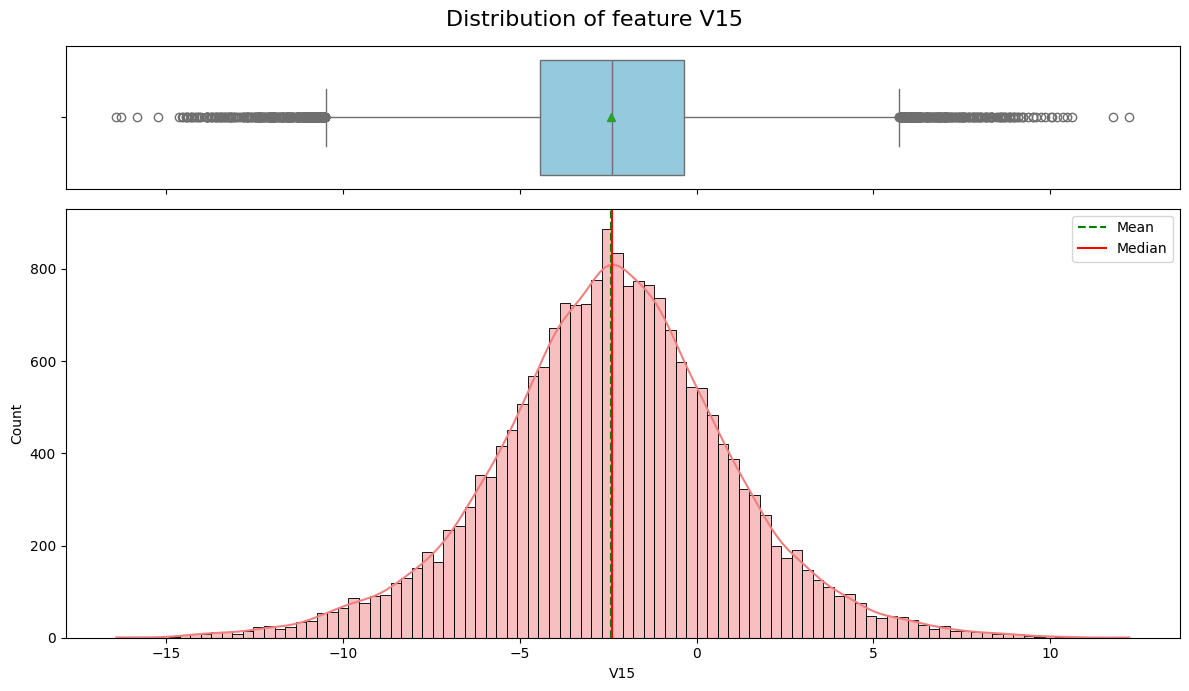

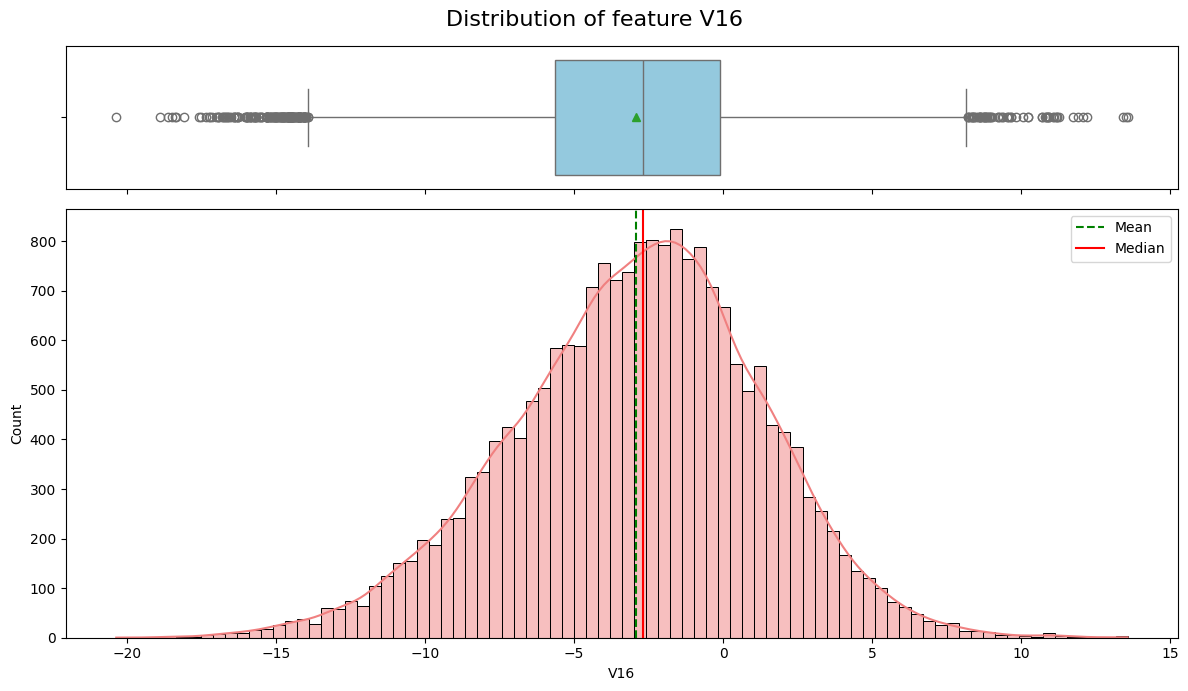

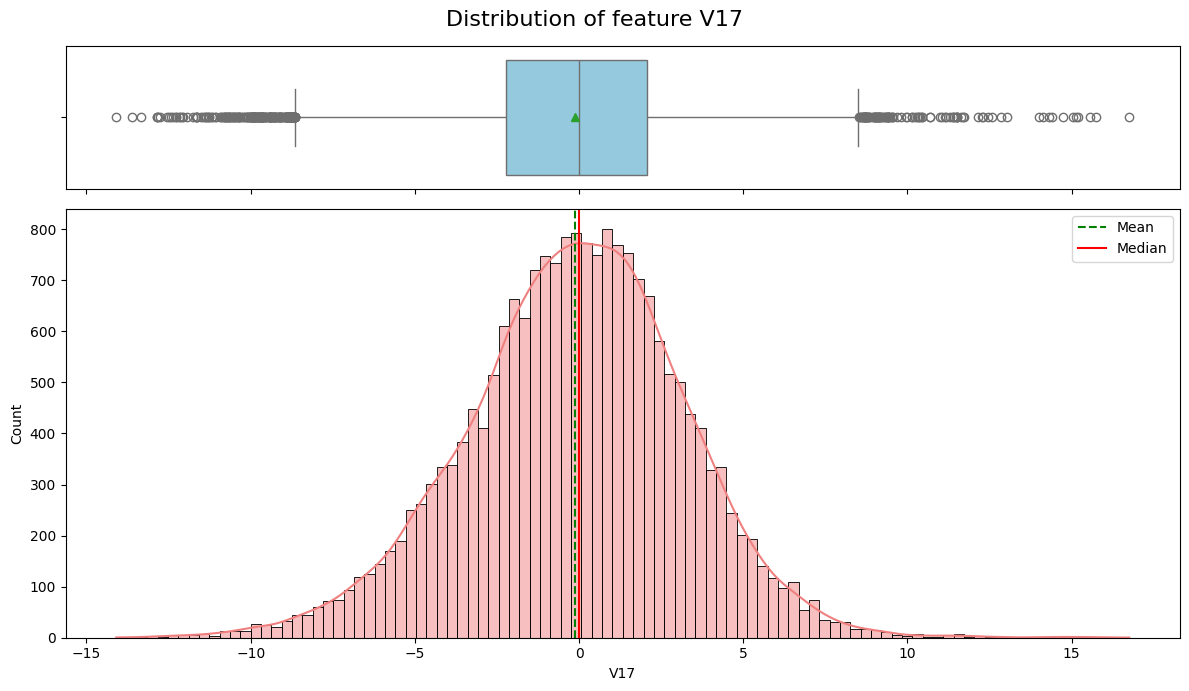

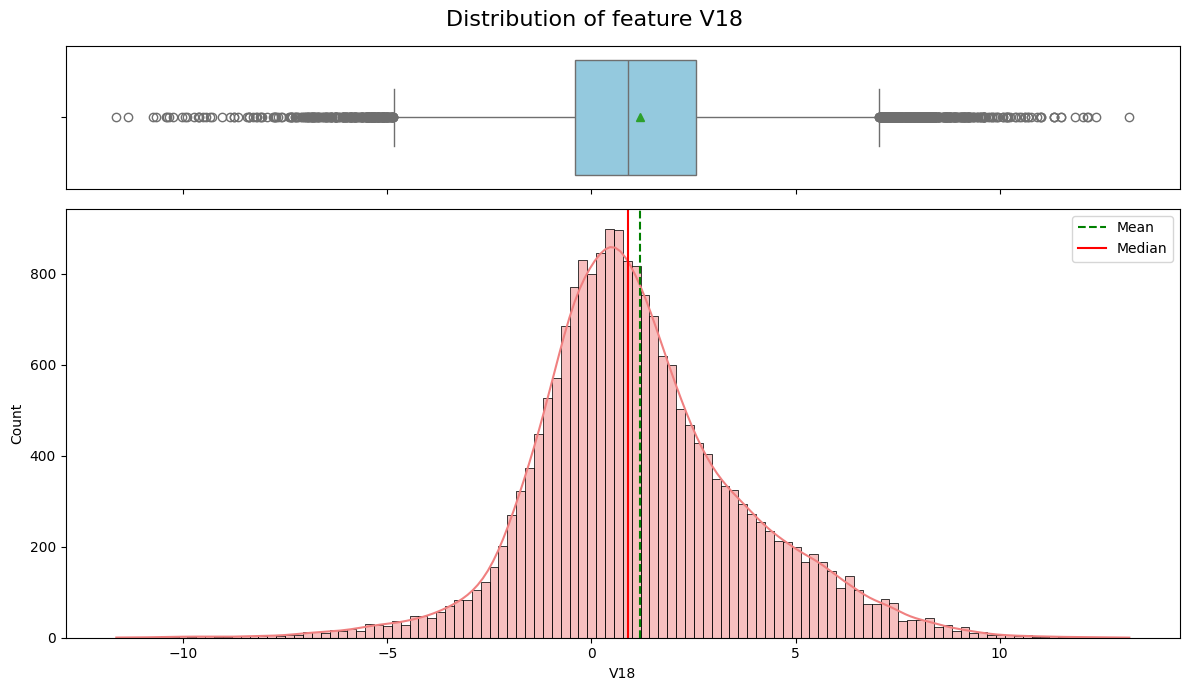

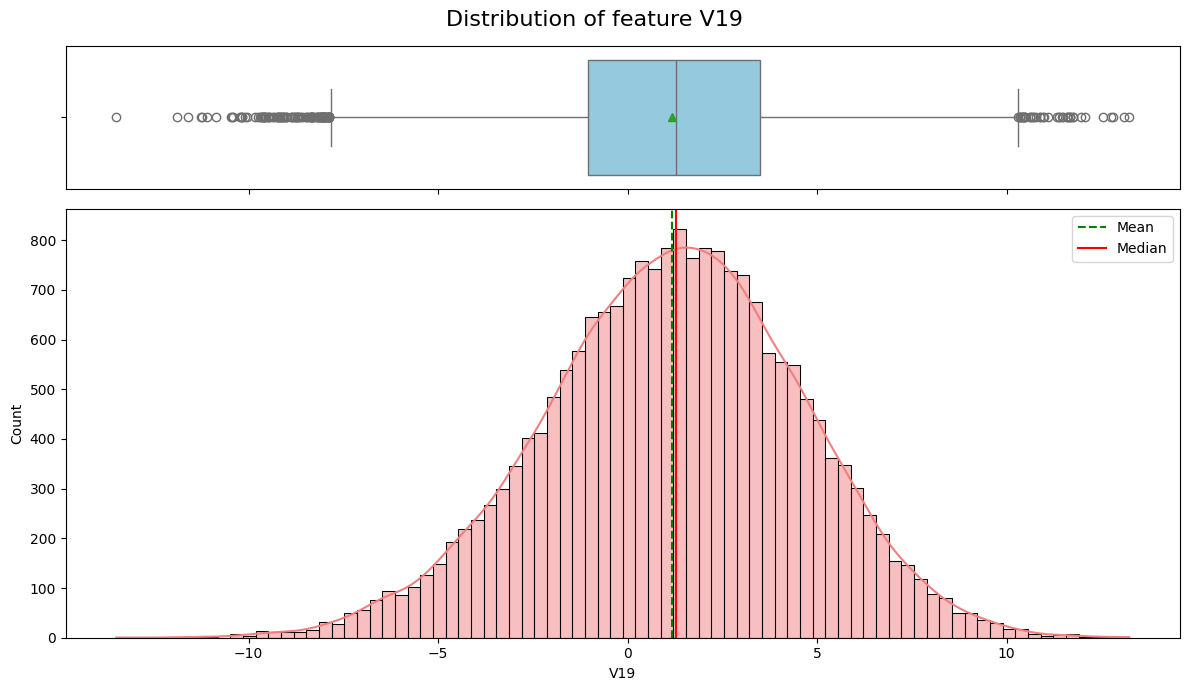

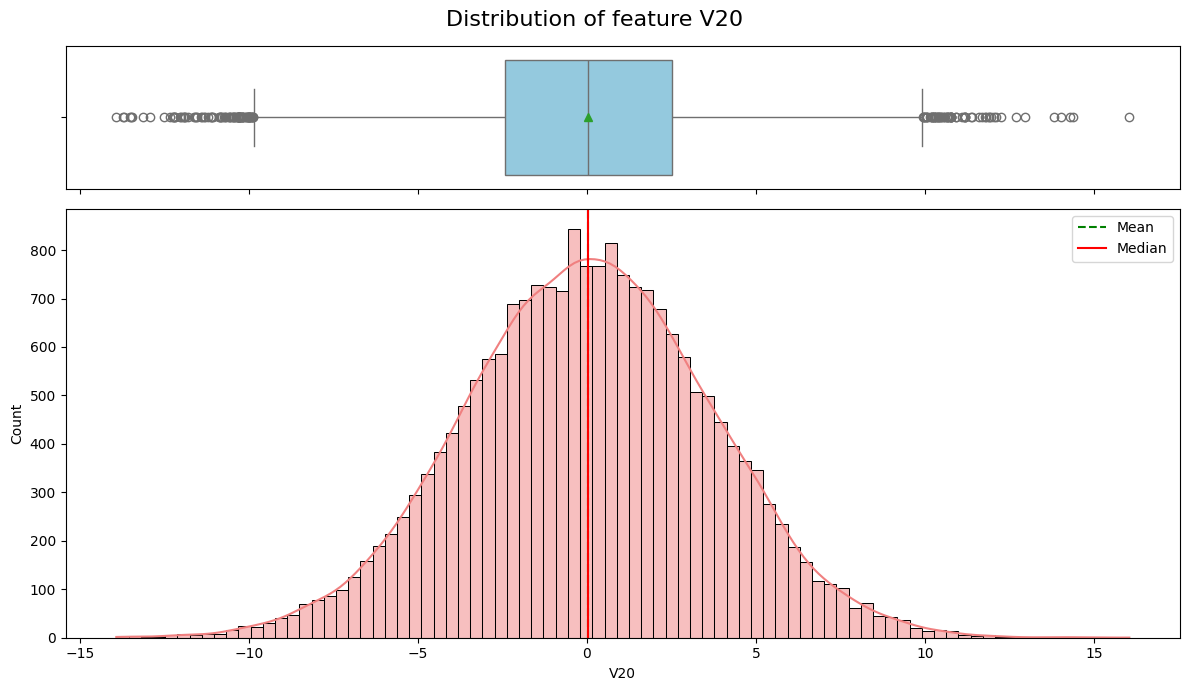

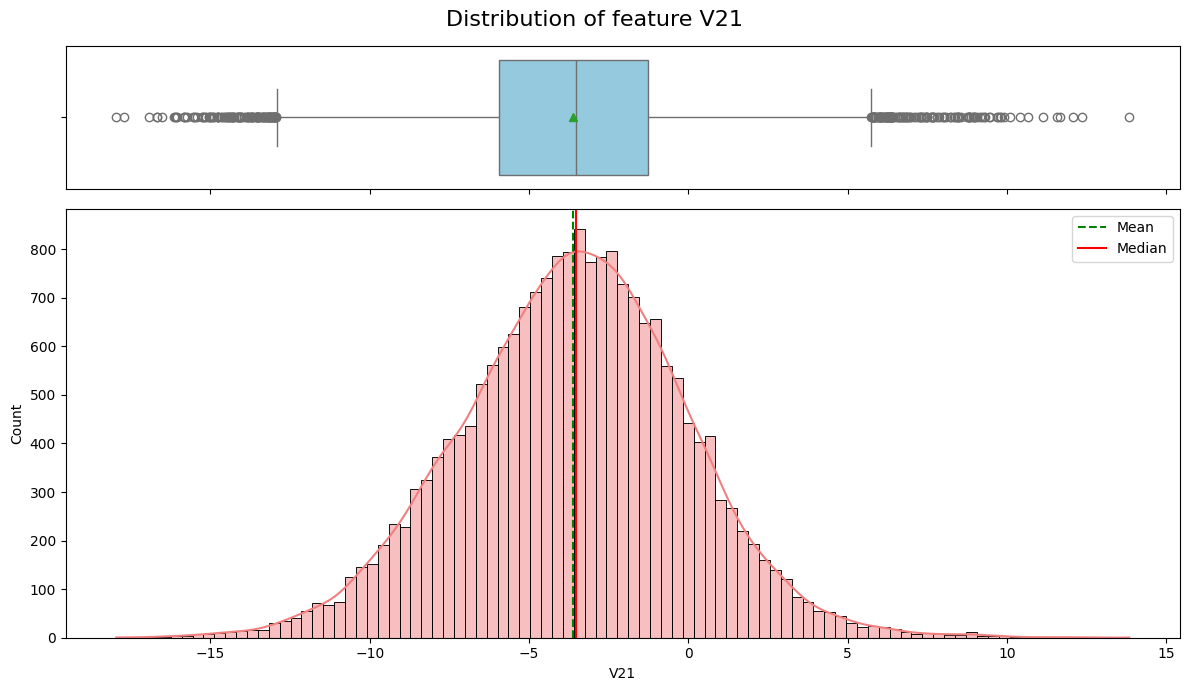

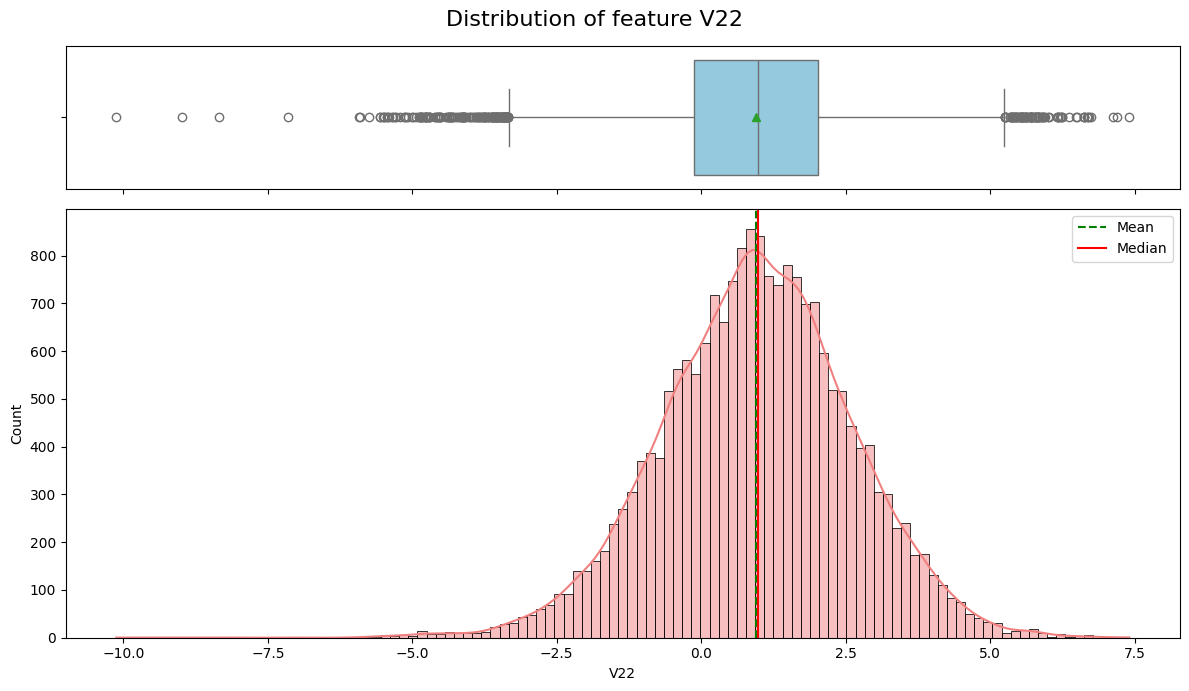

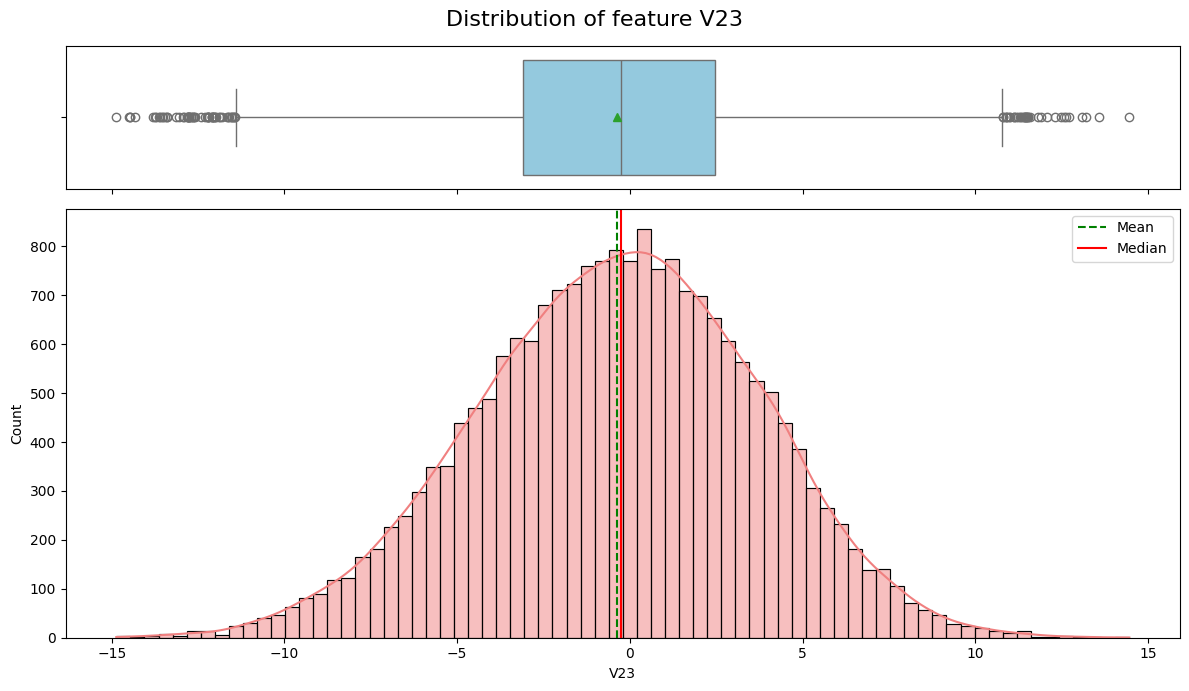

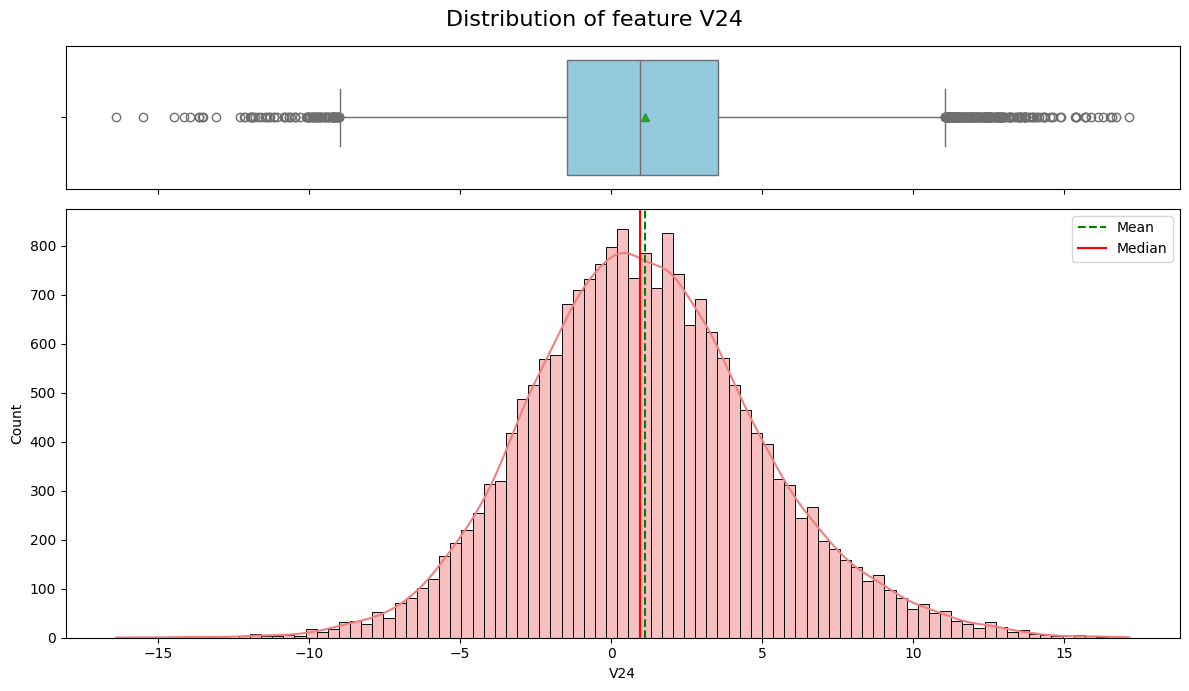

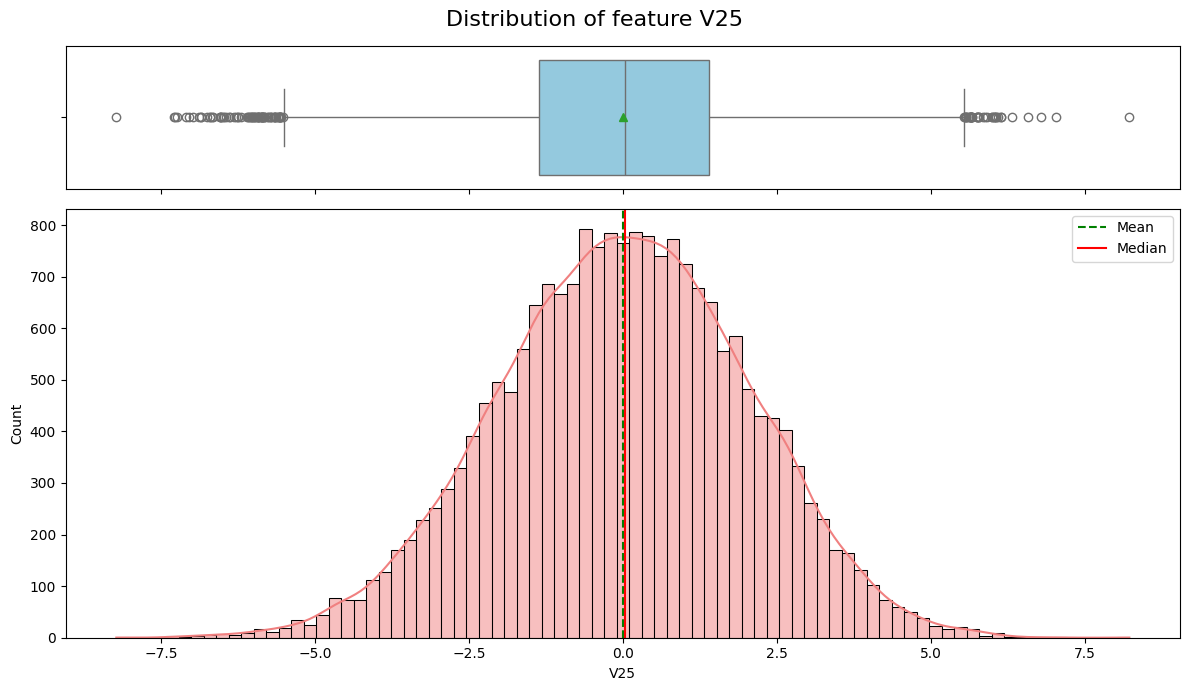

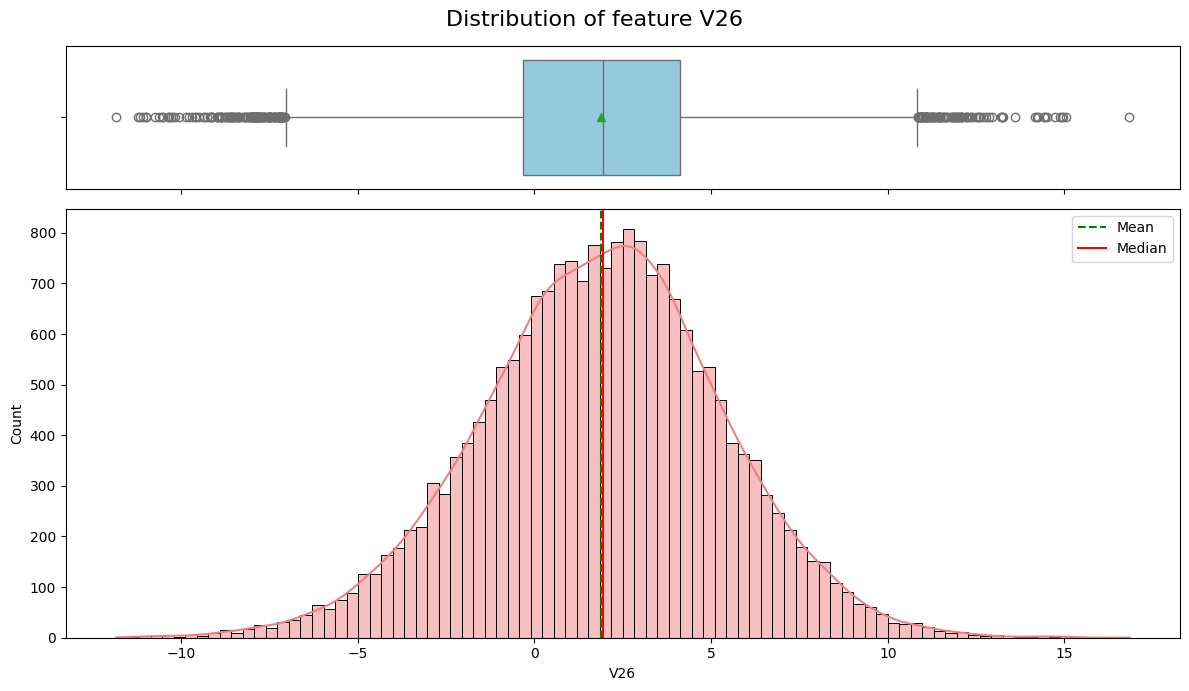

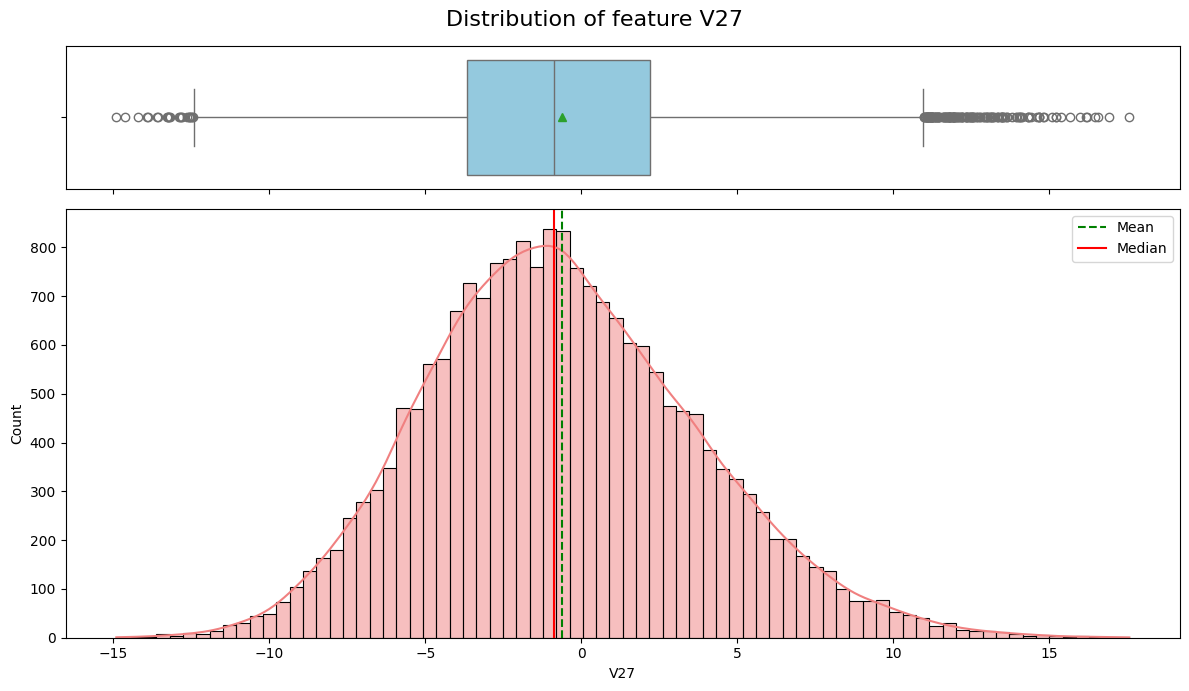

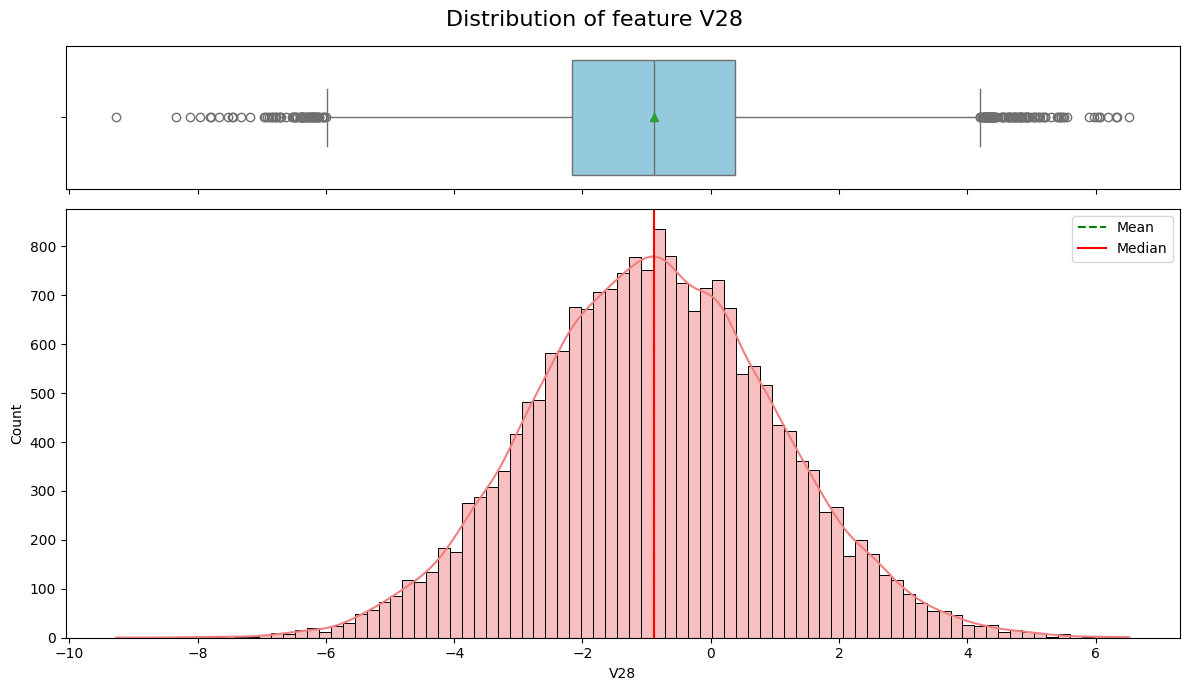

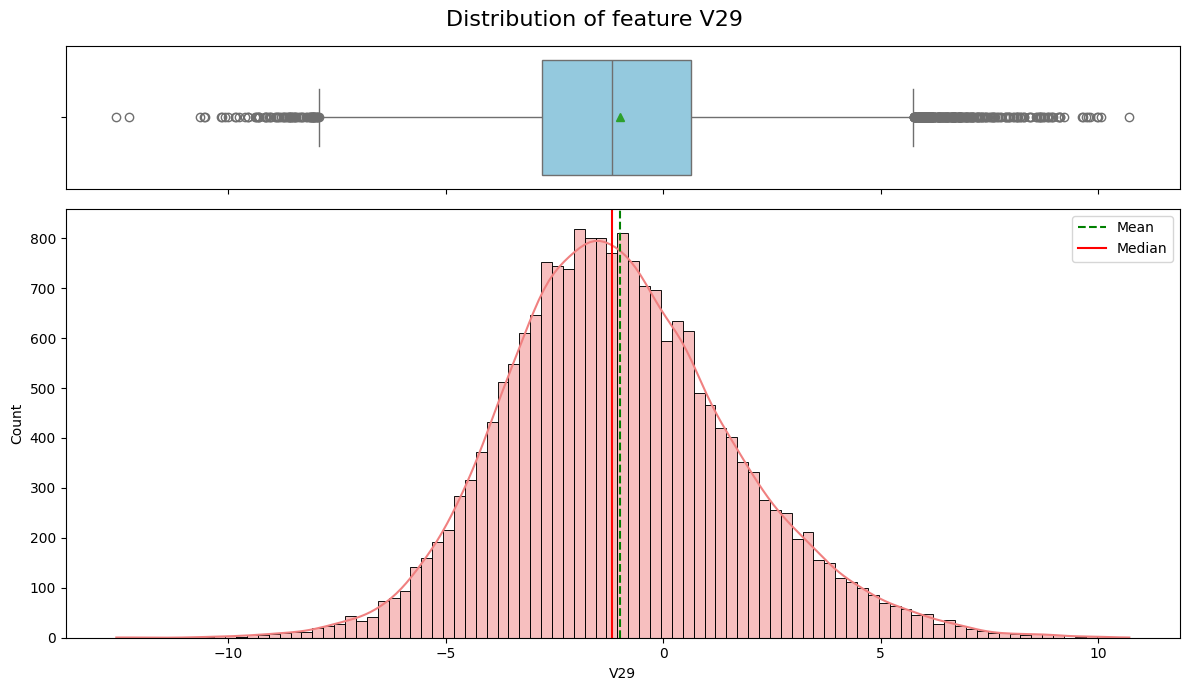

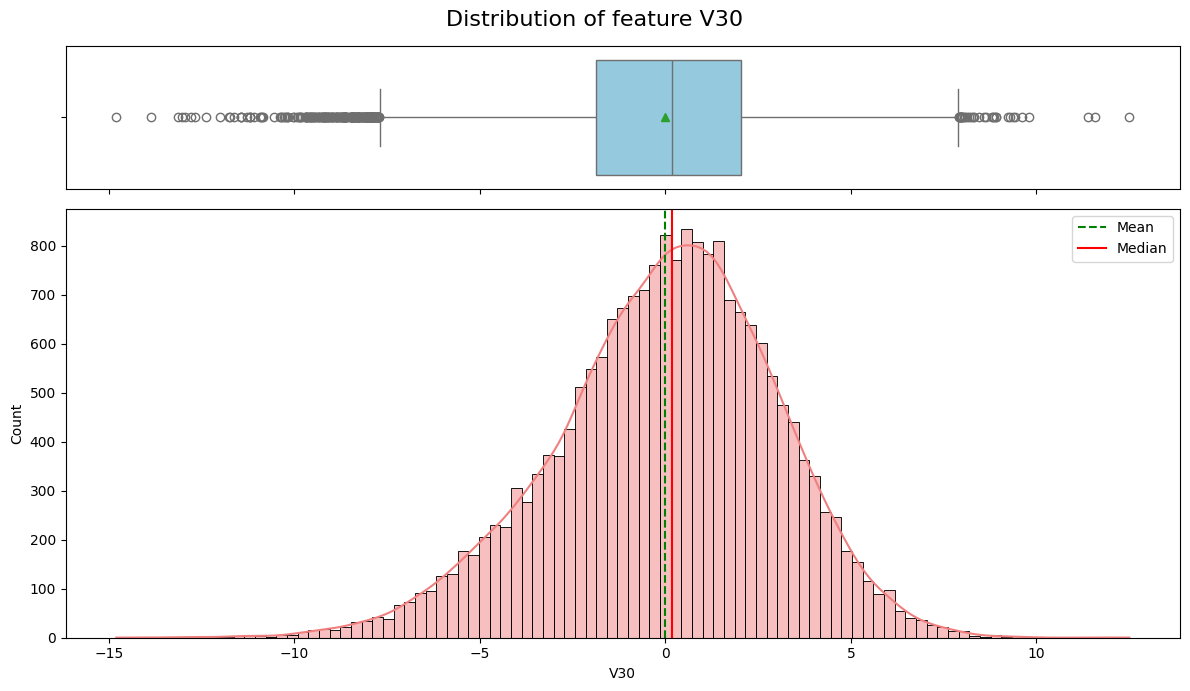

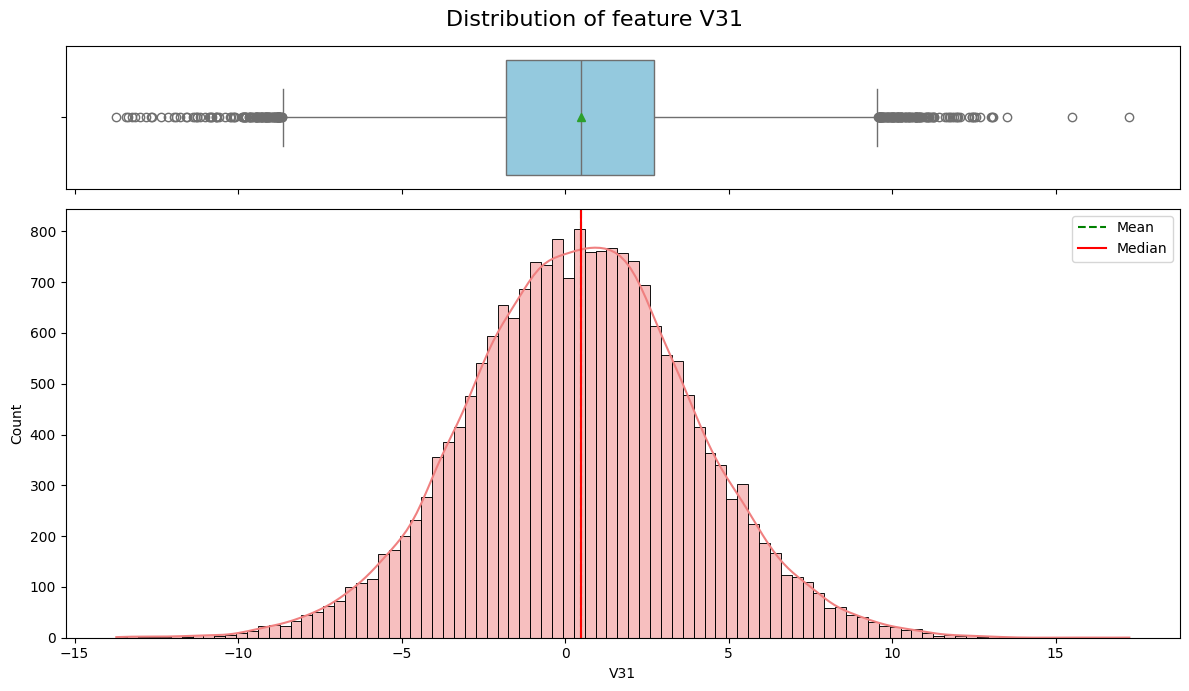

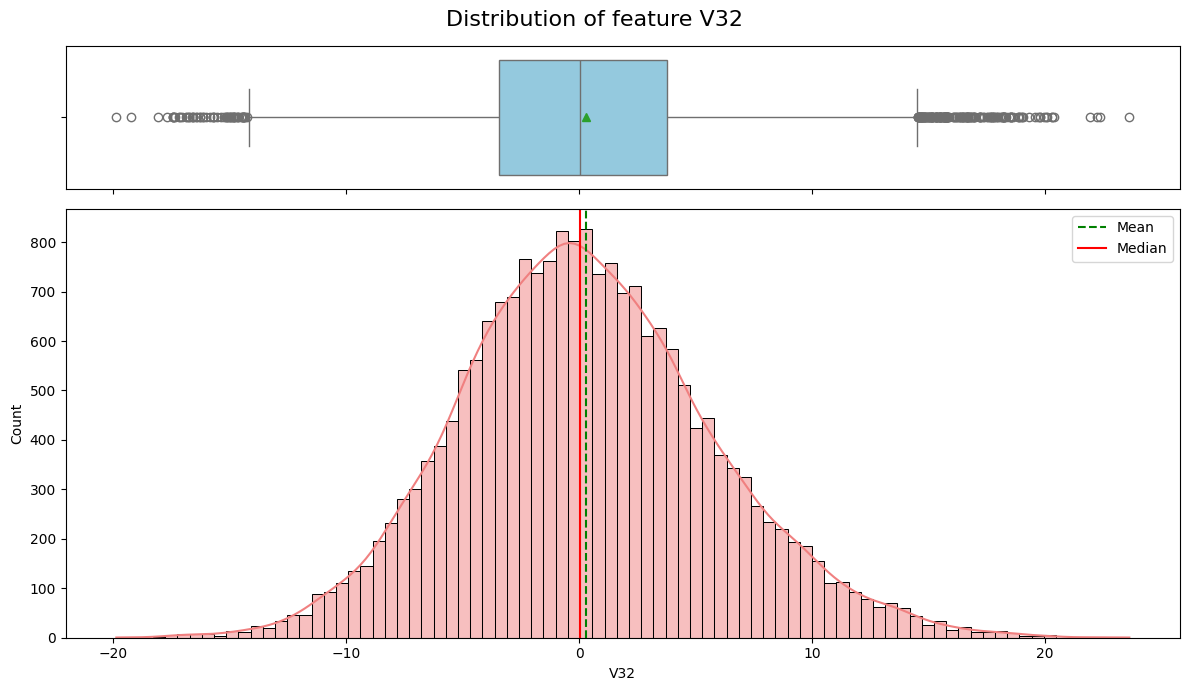

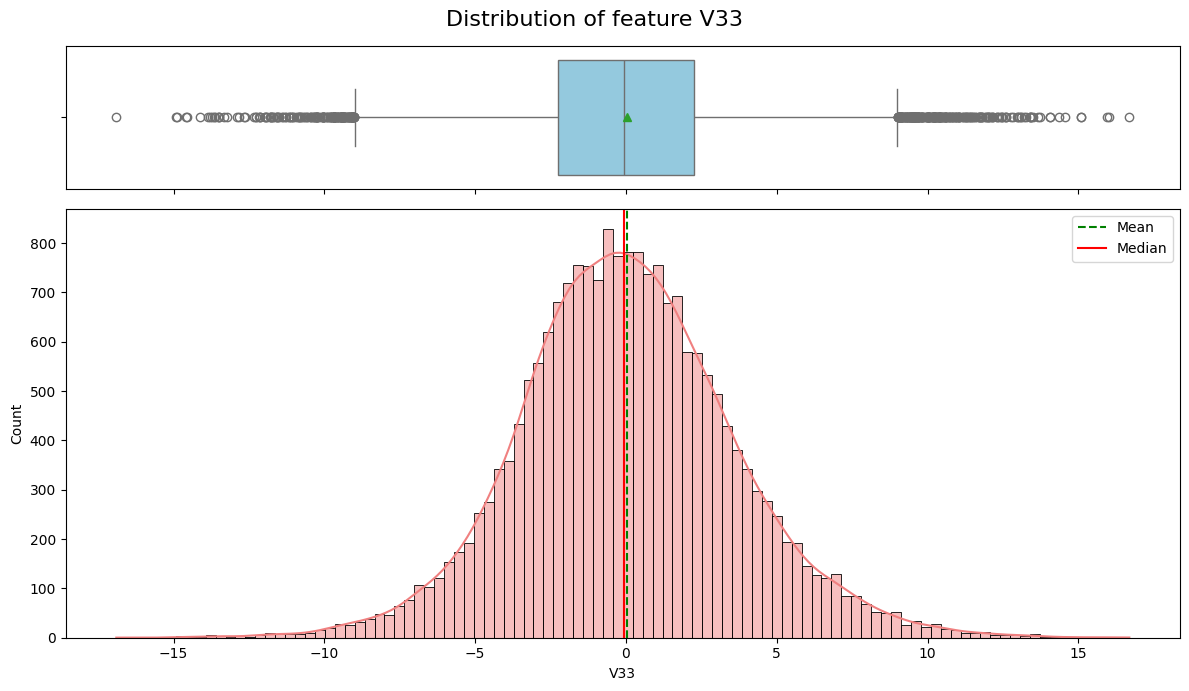

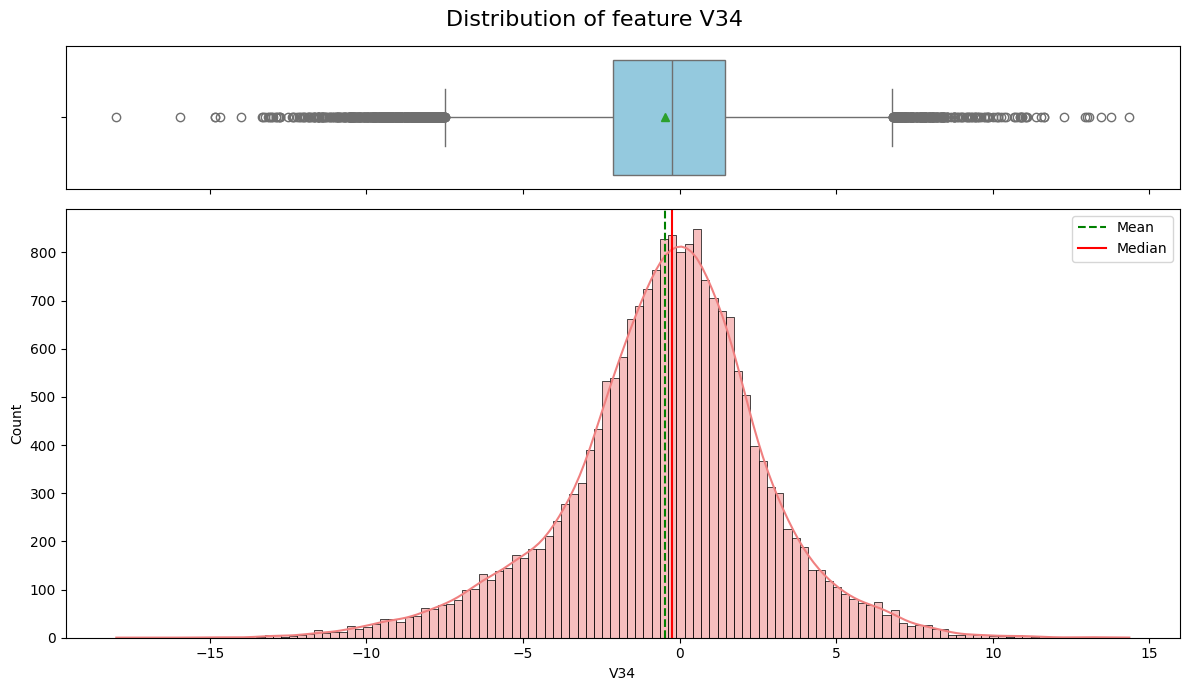

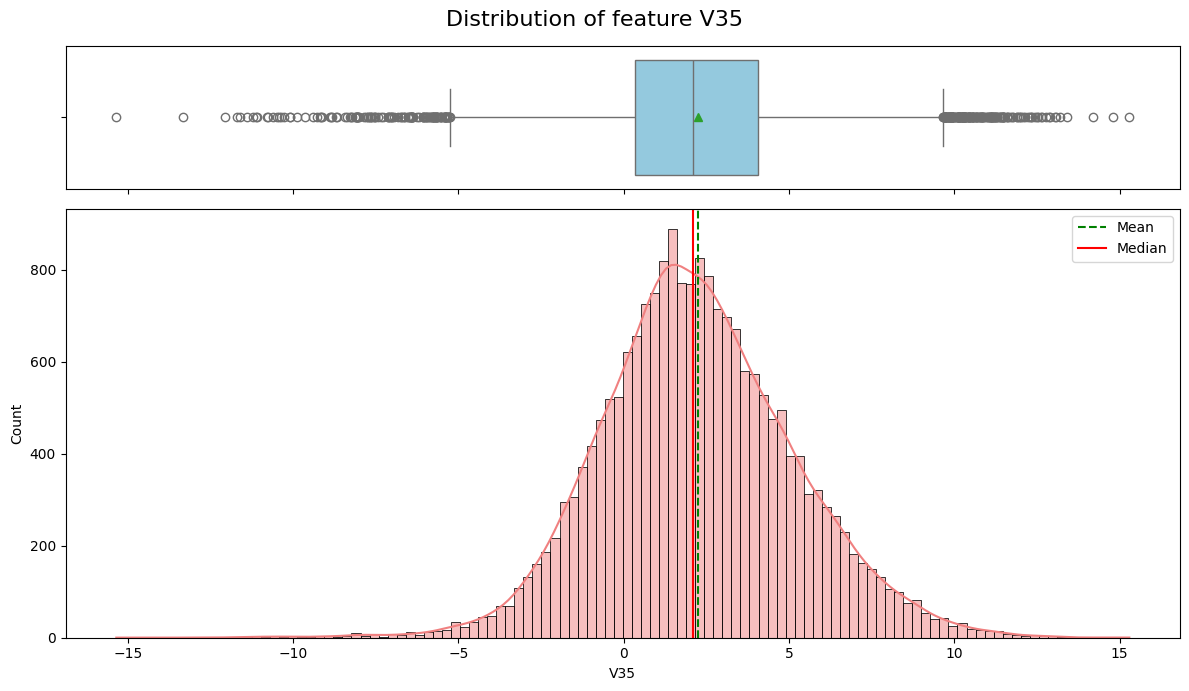

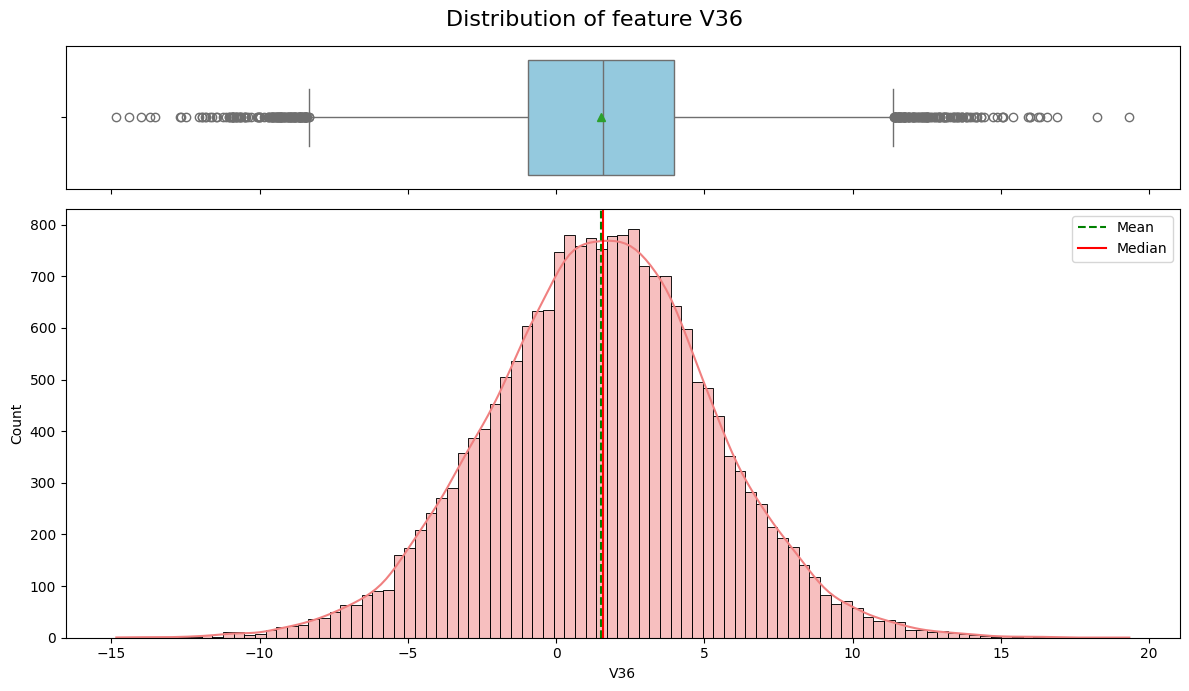

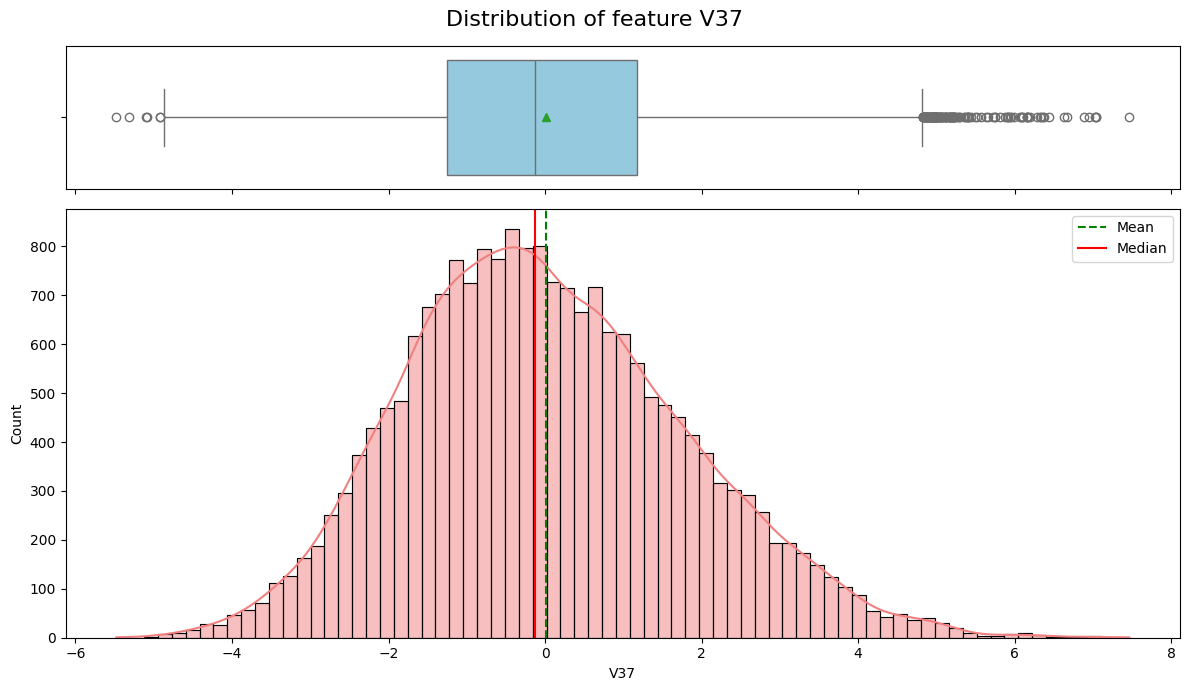

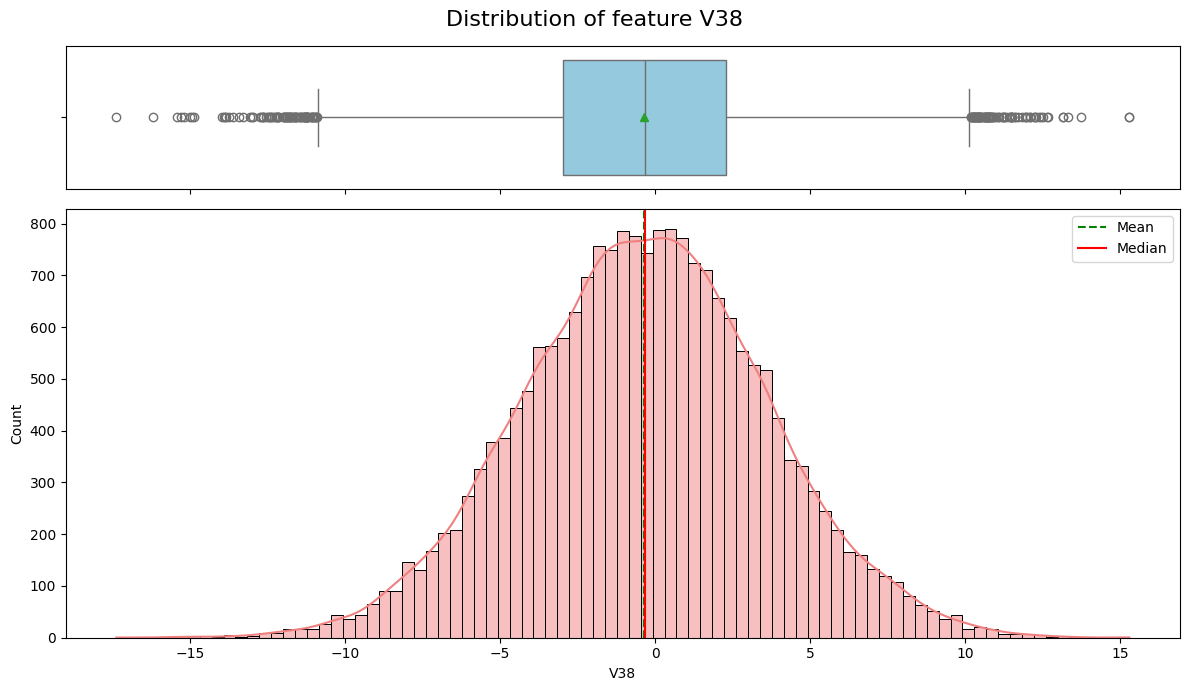

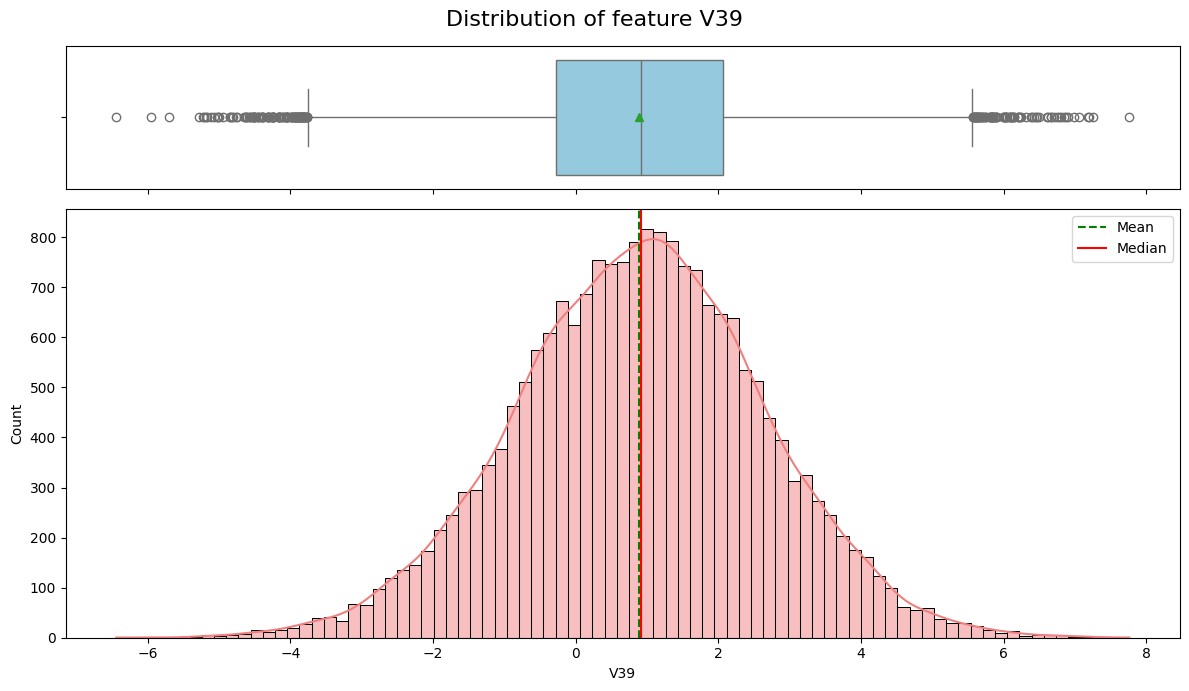

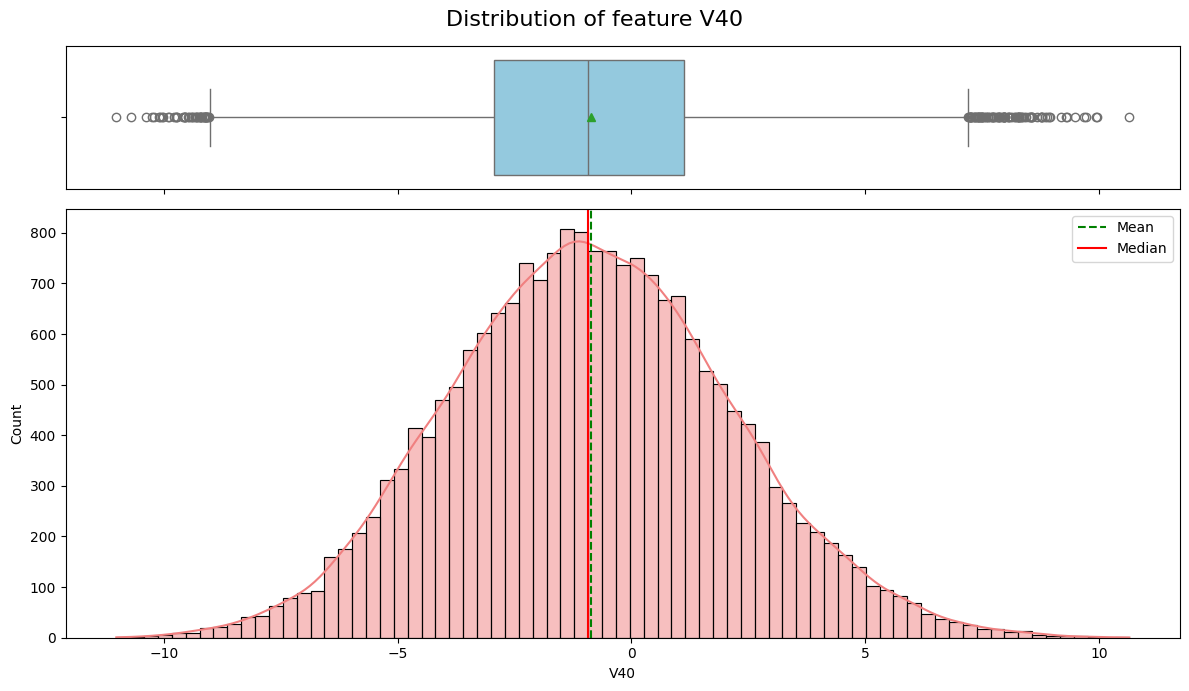

In [ ]:
for feature in train_df.columns.to_list()[:-1]:
    histogram_boxplot(train_df, feature, kde=True, bins=None, title=f"Distribution of feature {feature}")

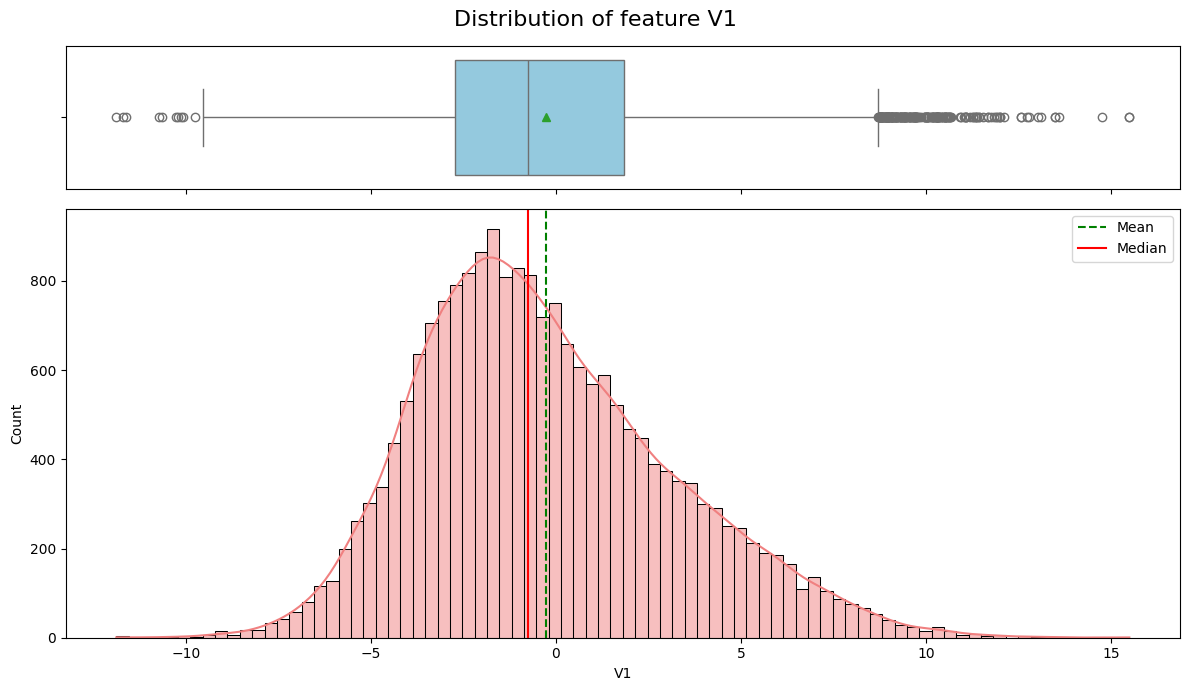

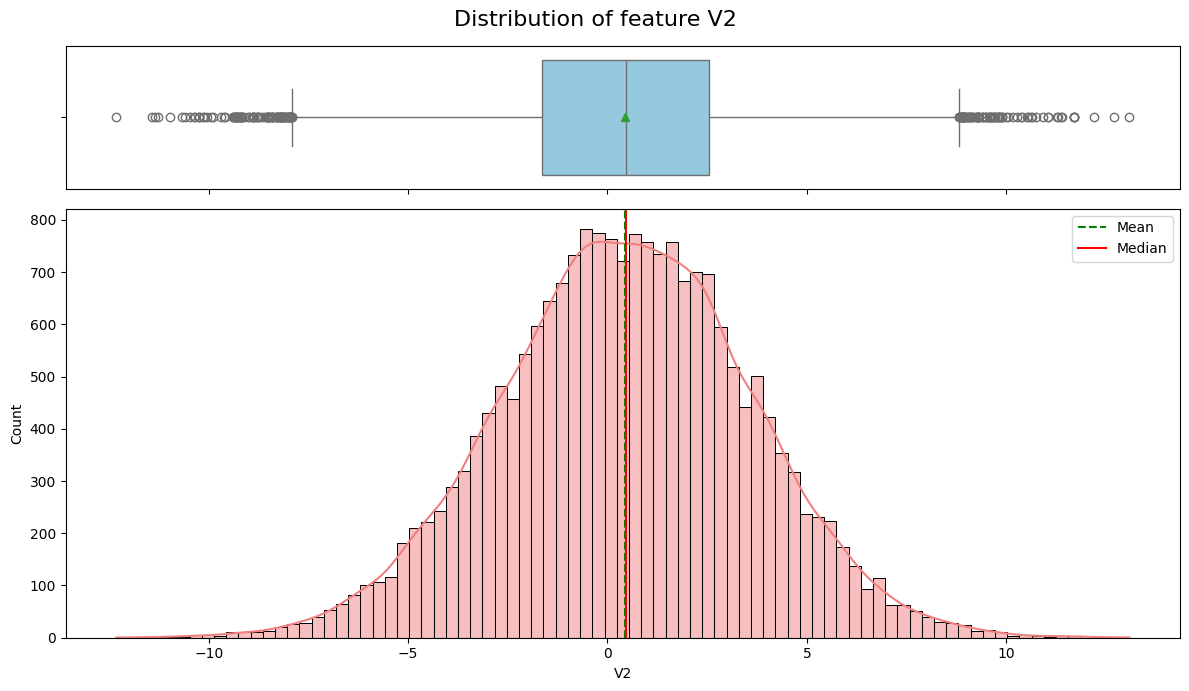

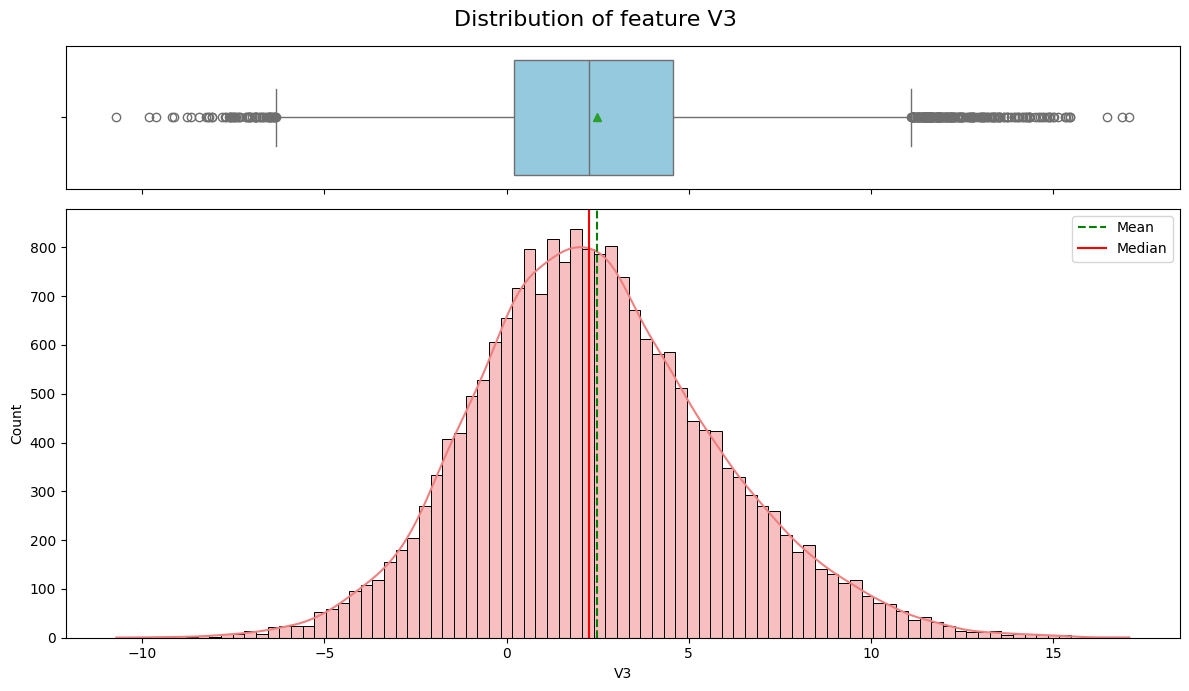

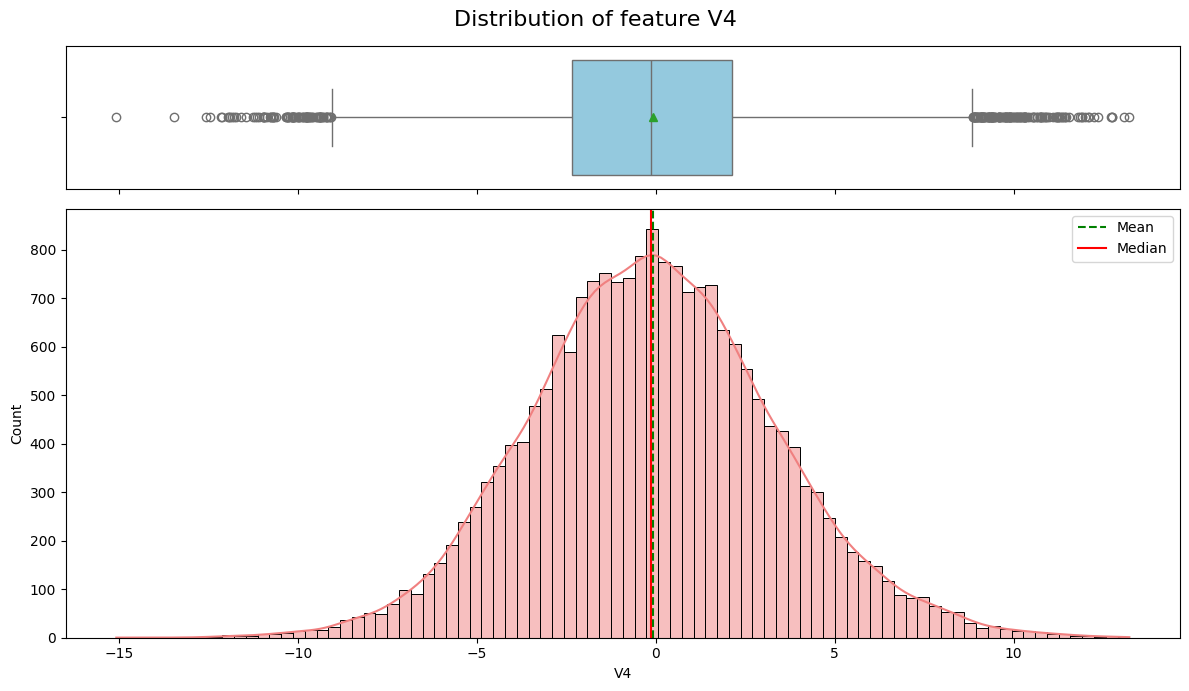

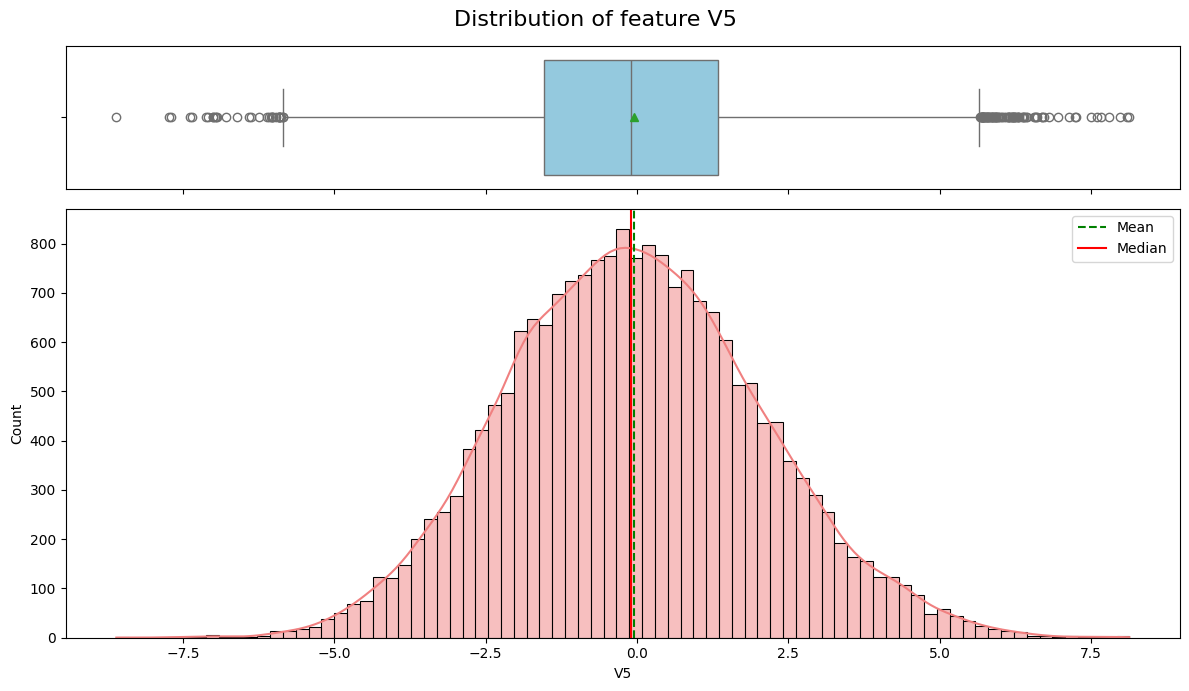

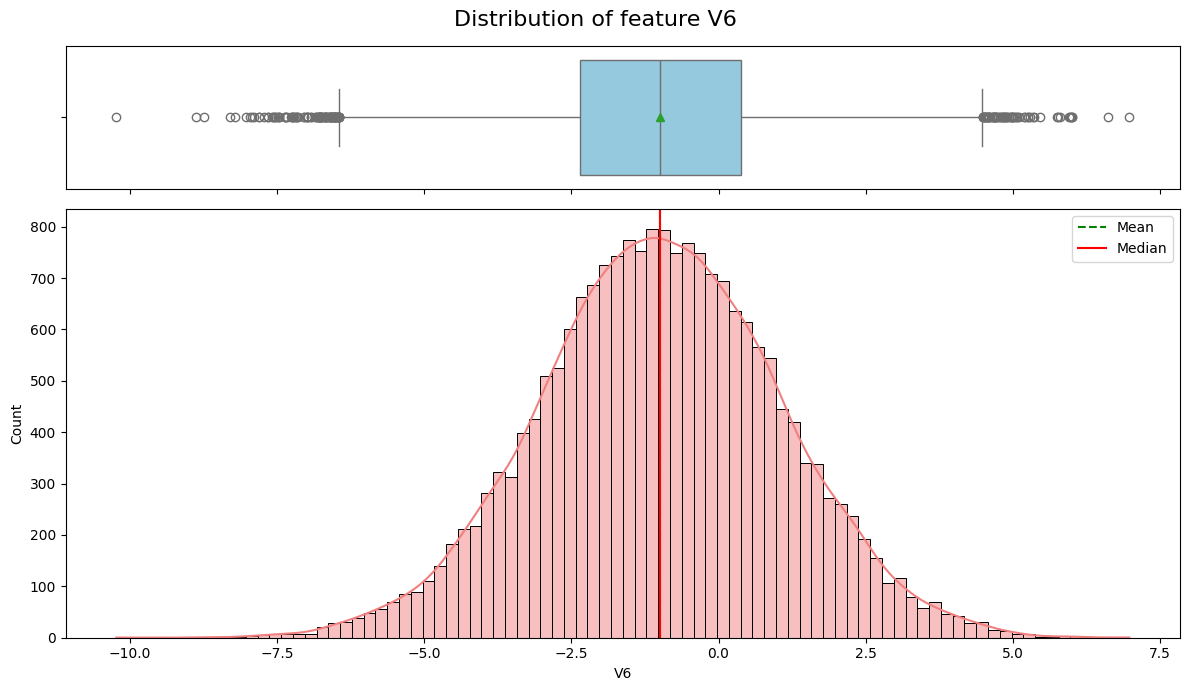

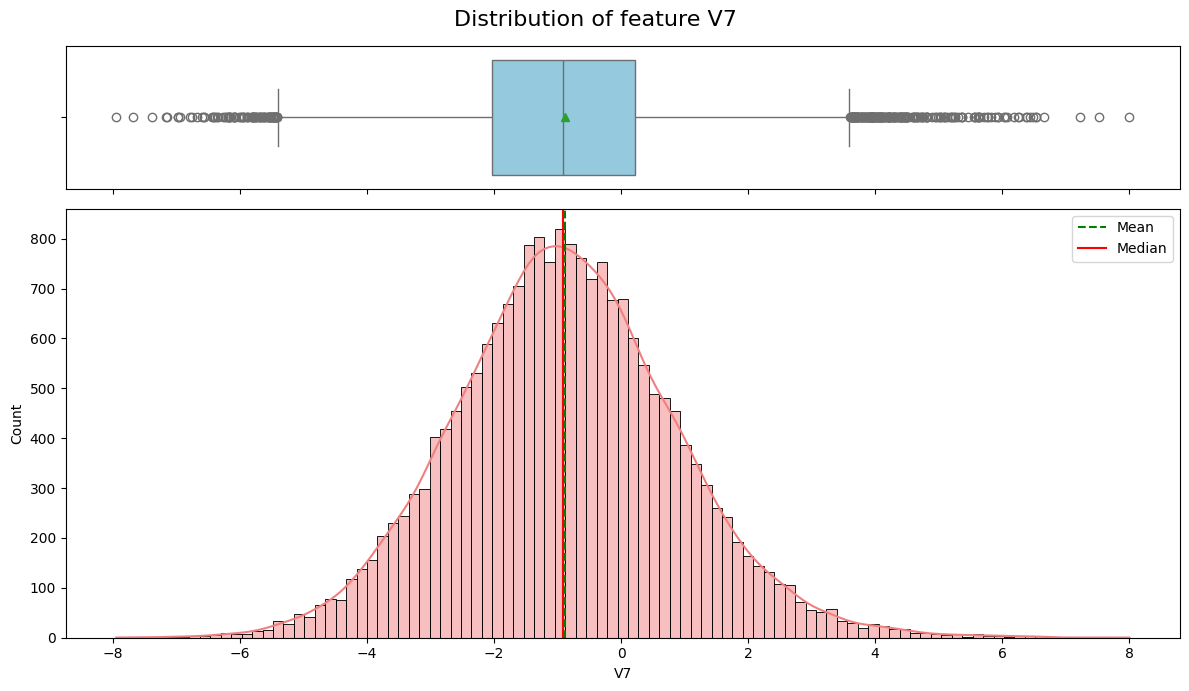

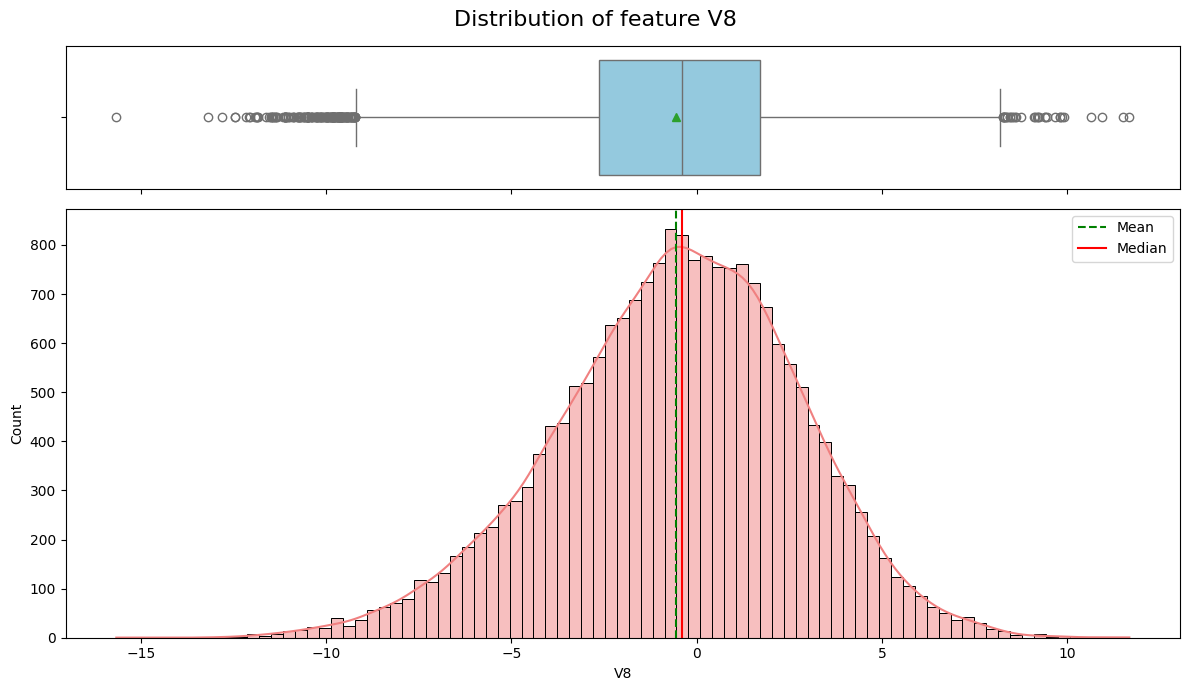

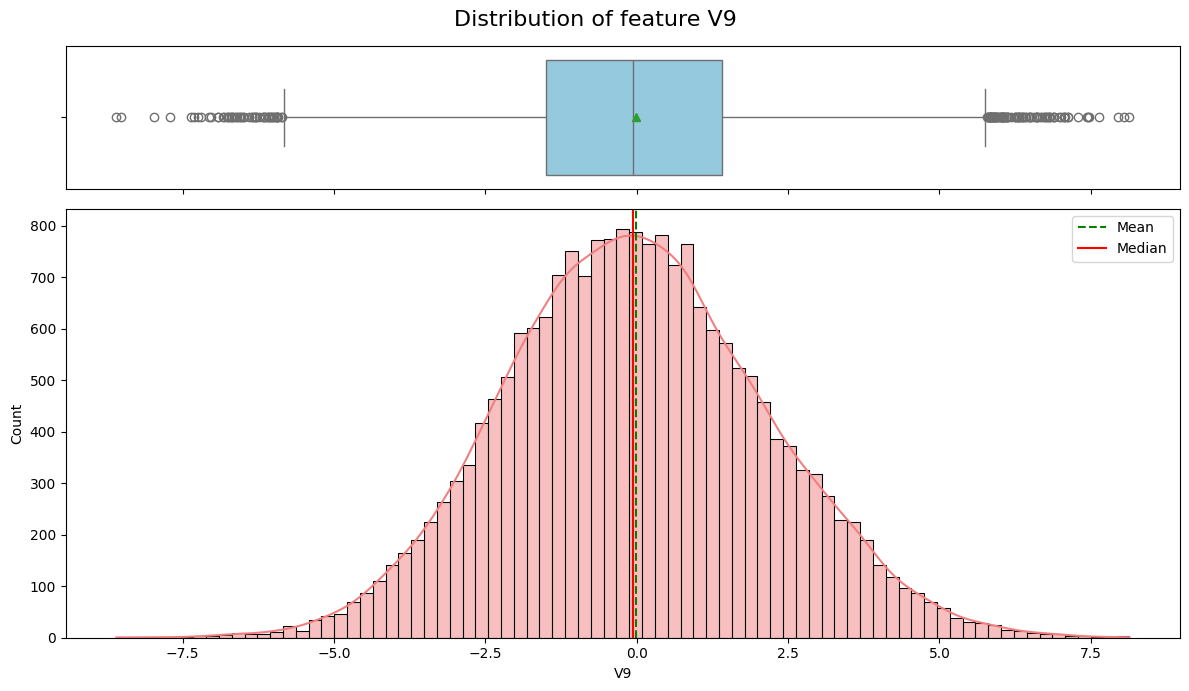

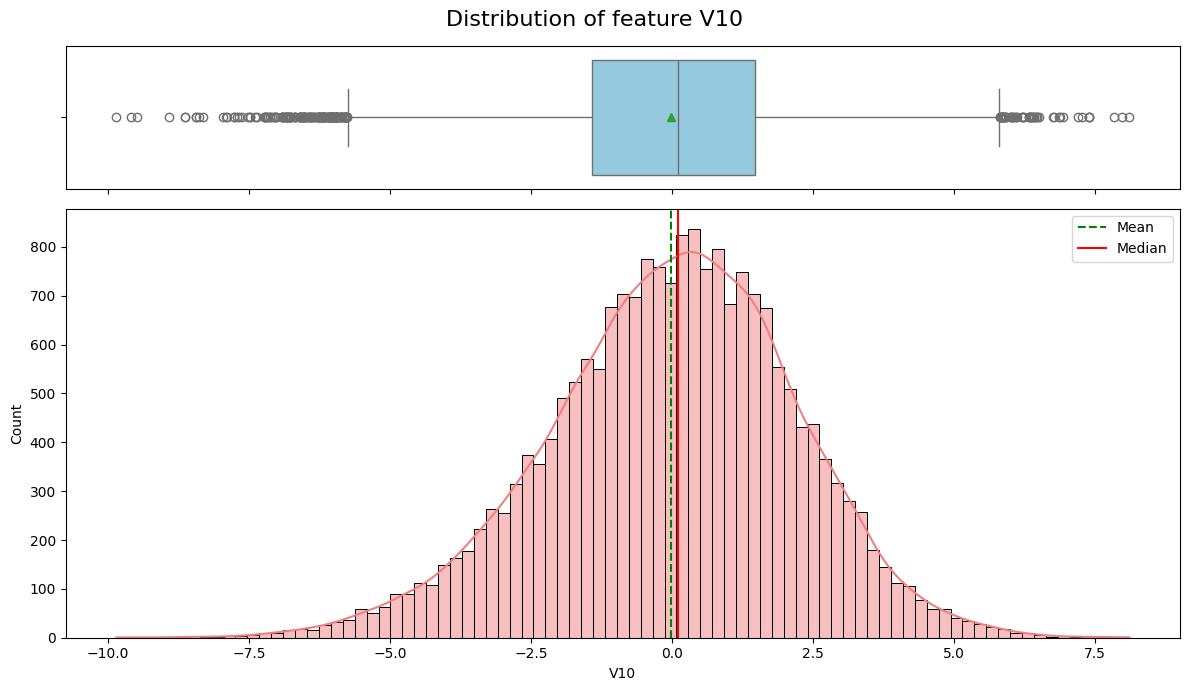

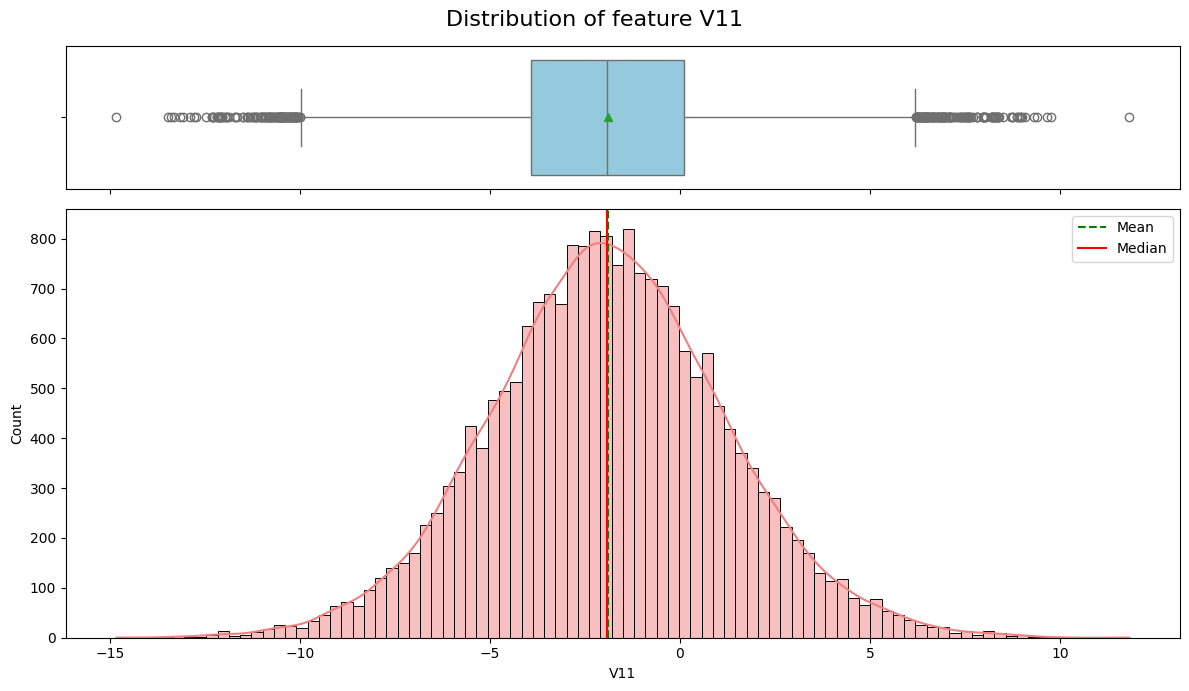

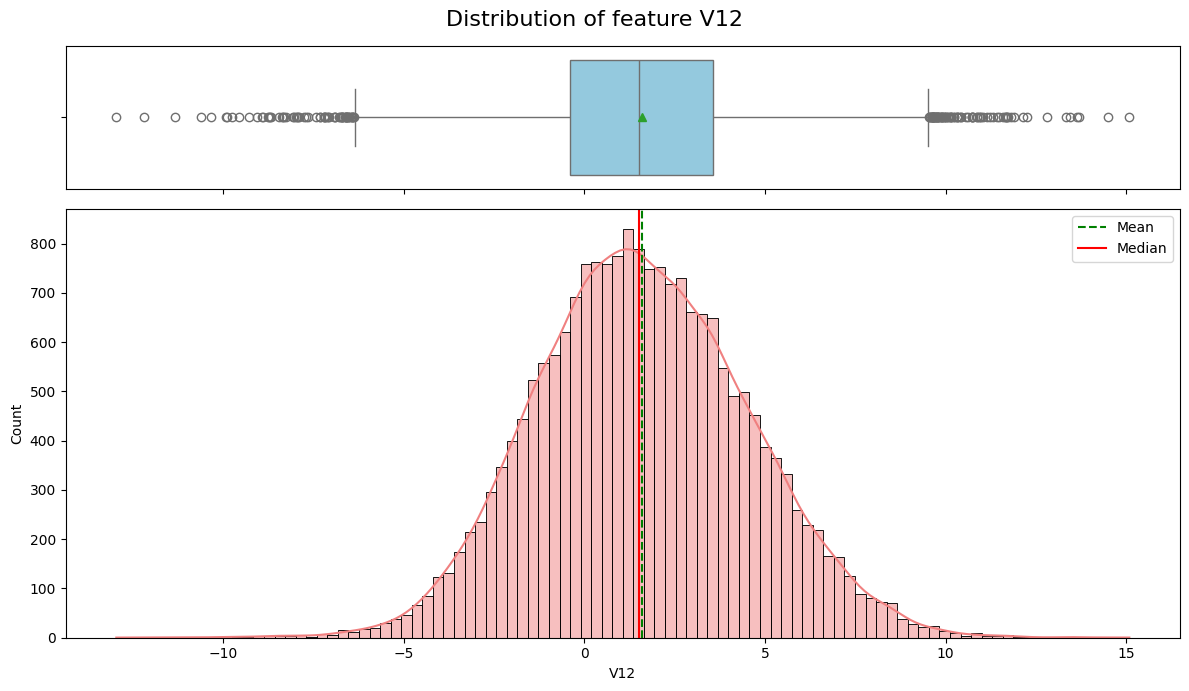

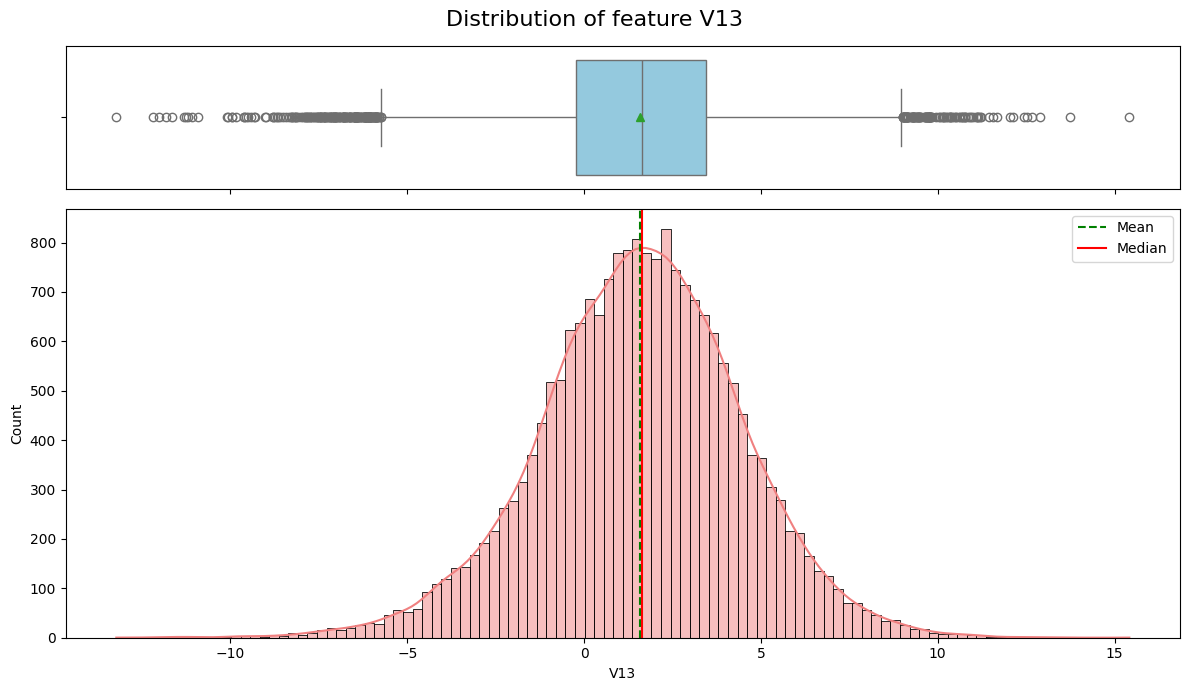

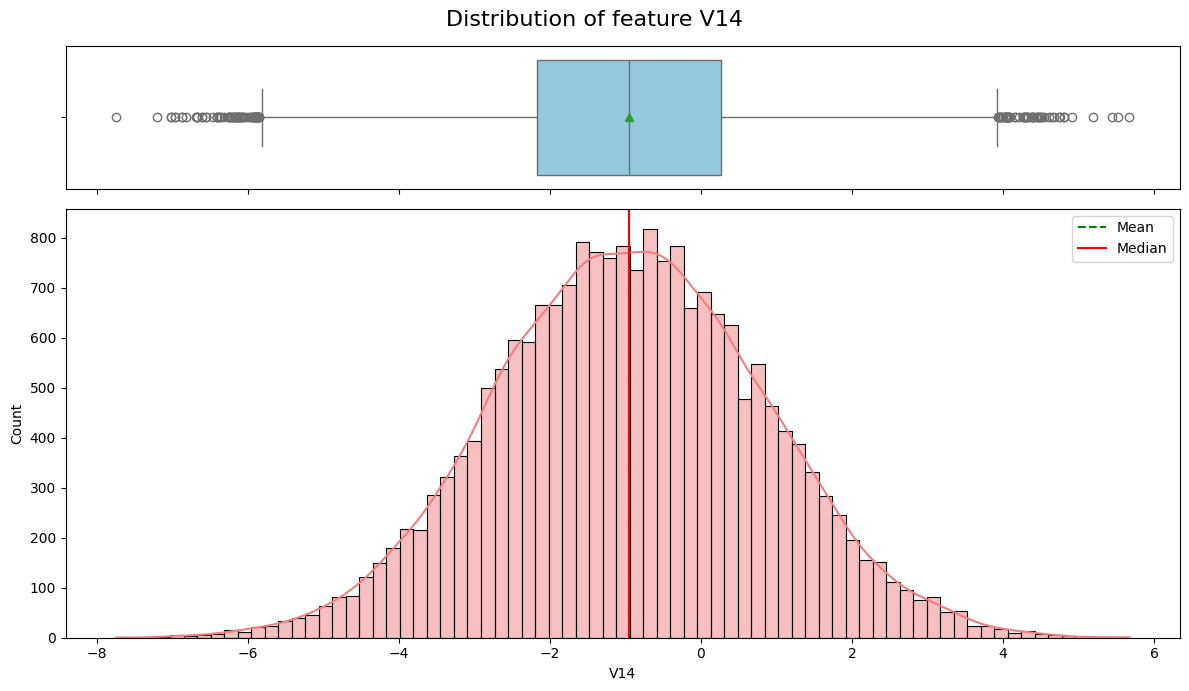

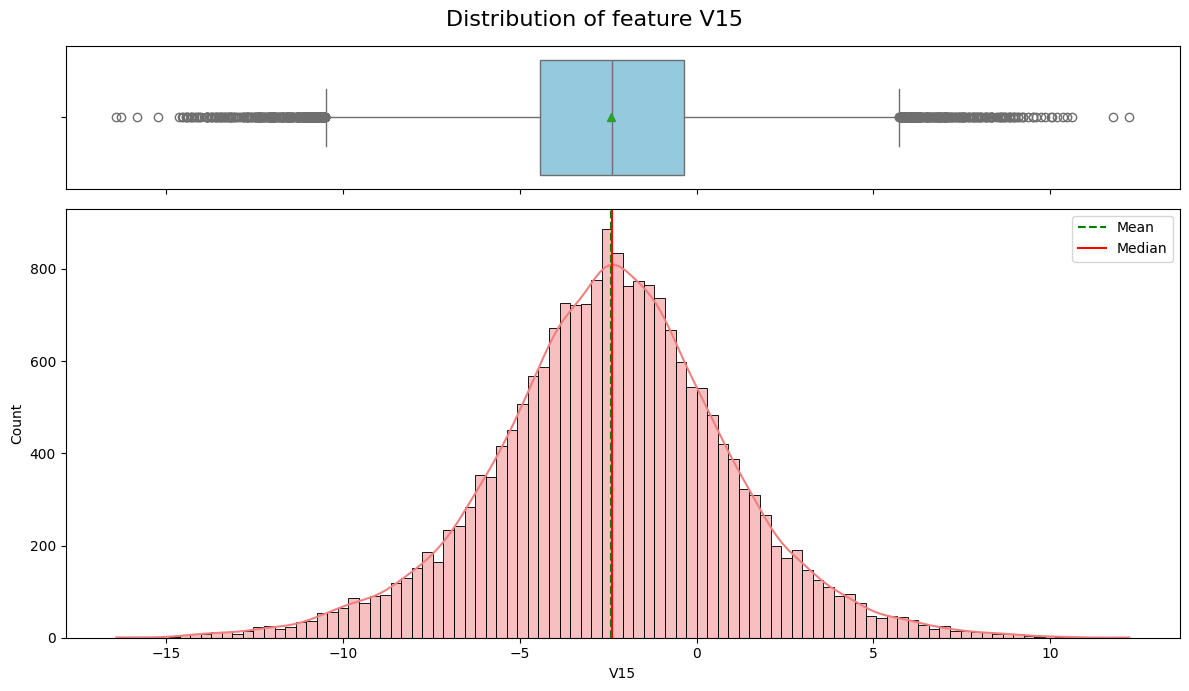

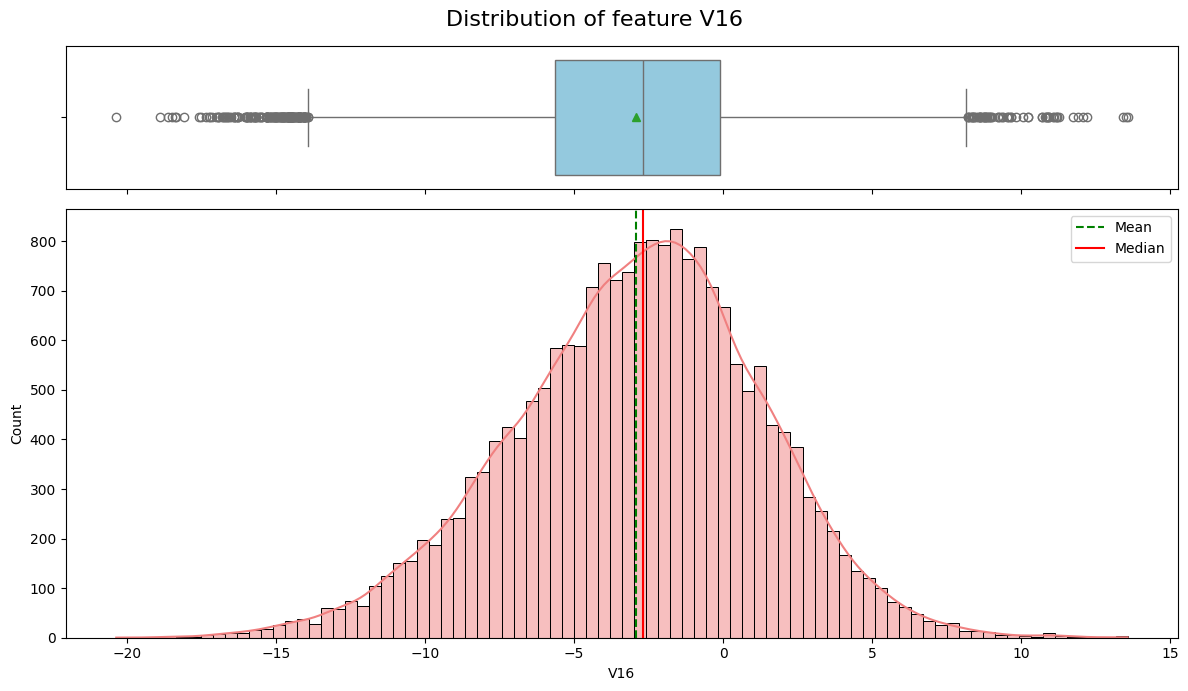

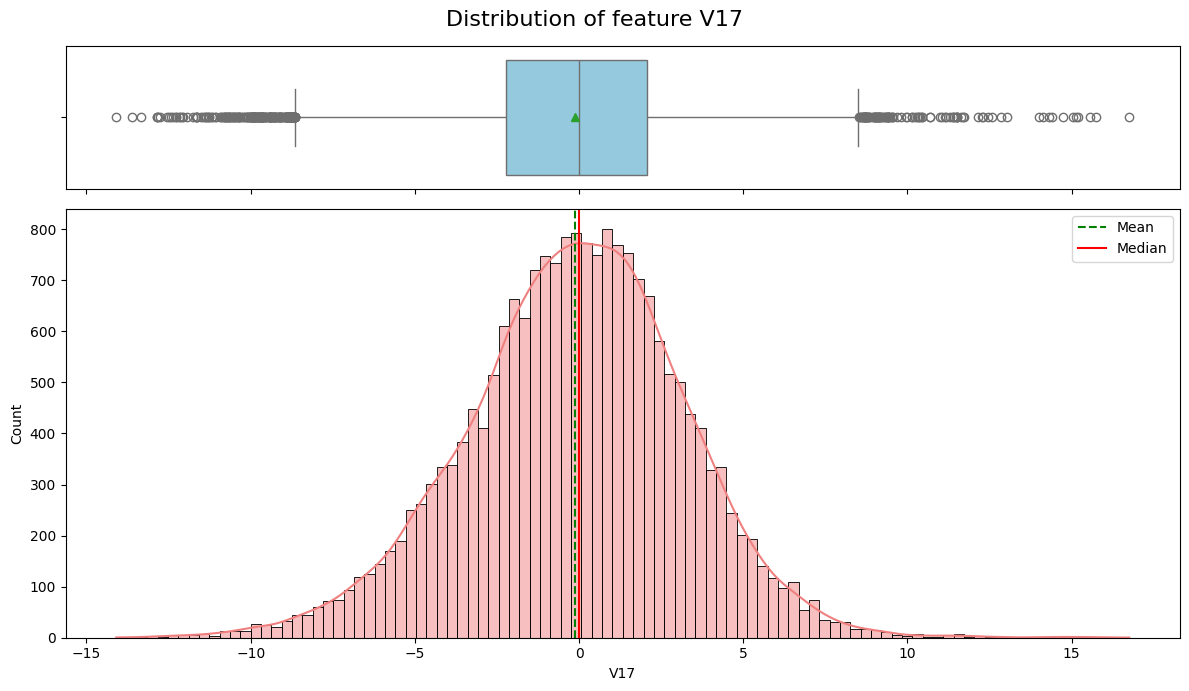

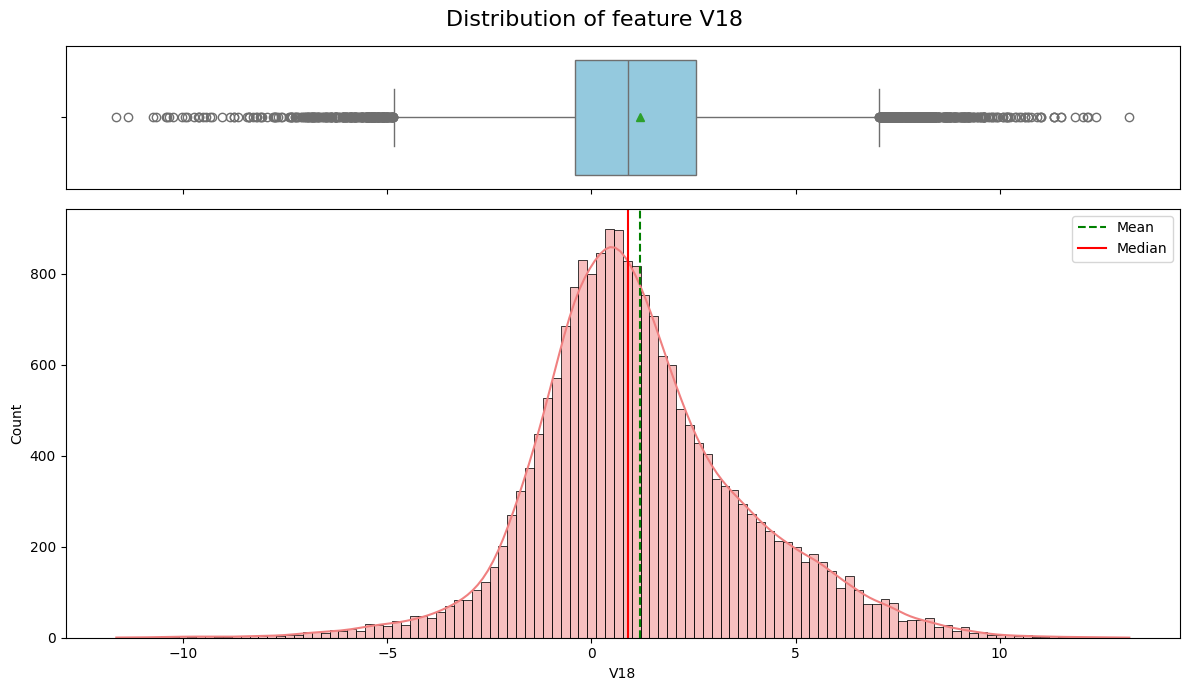

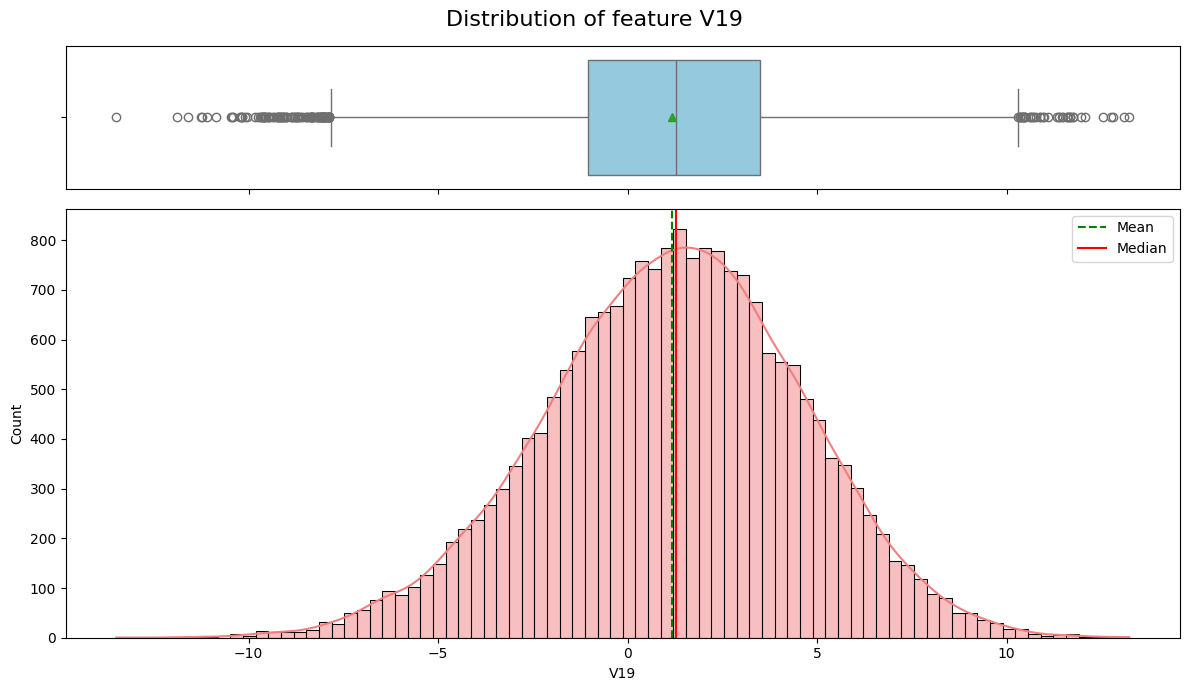

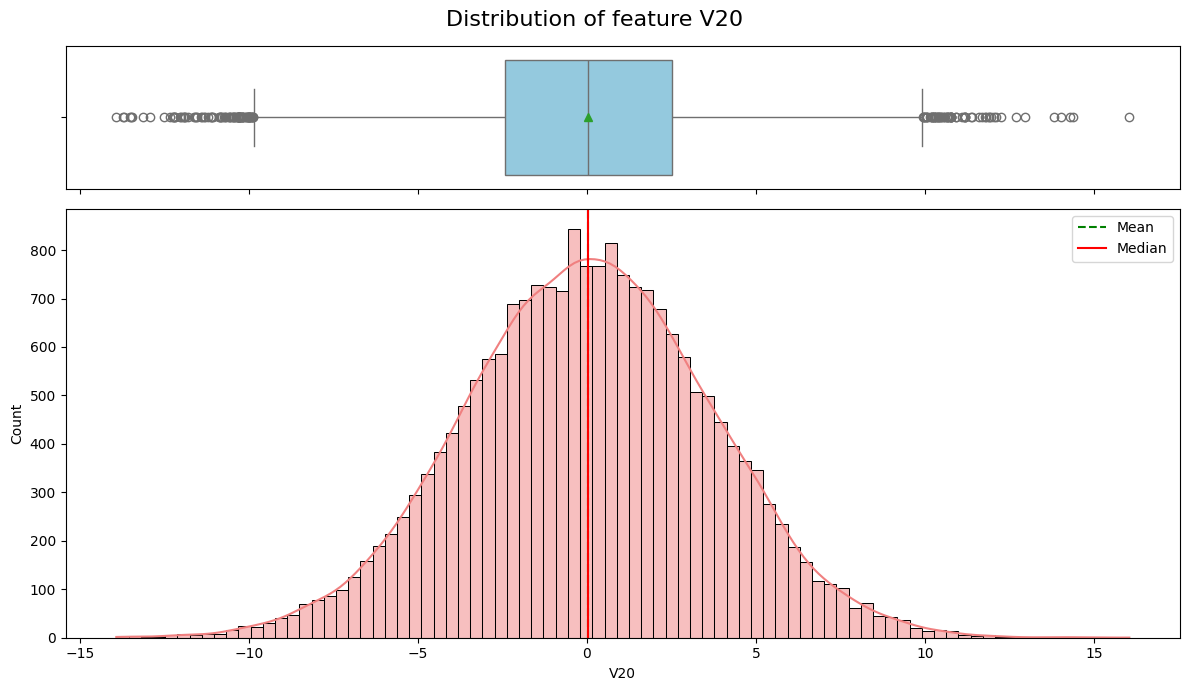

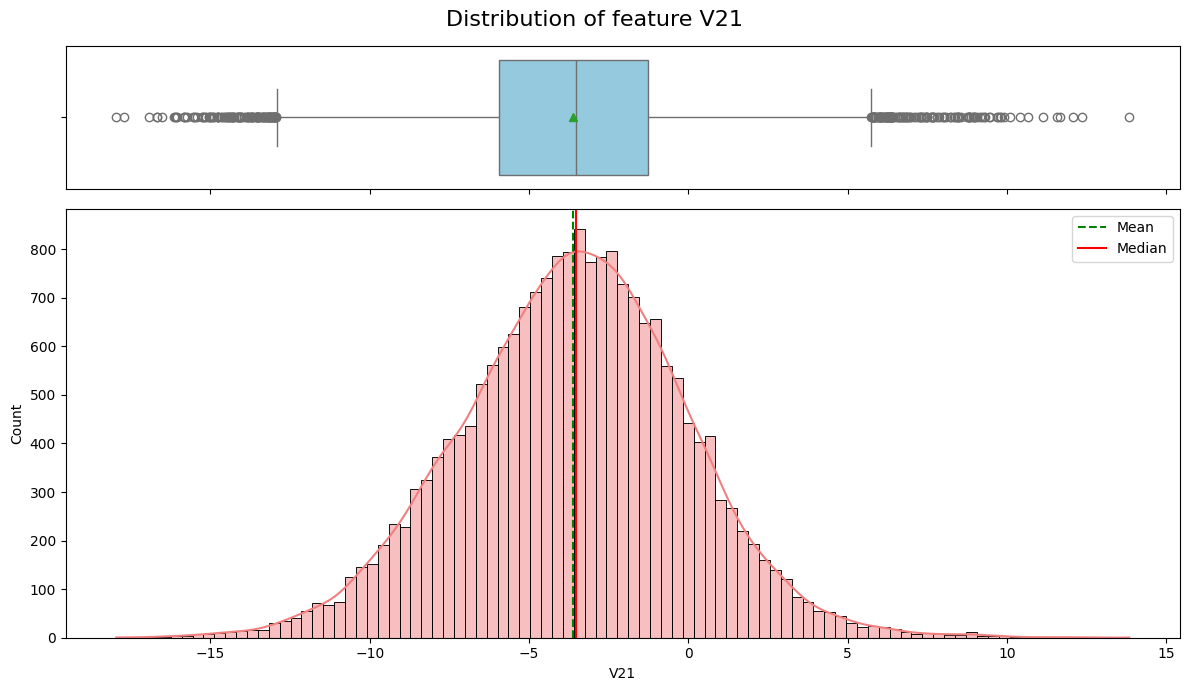

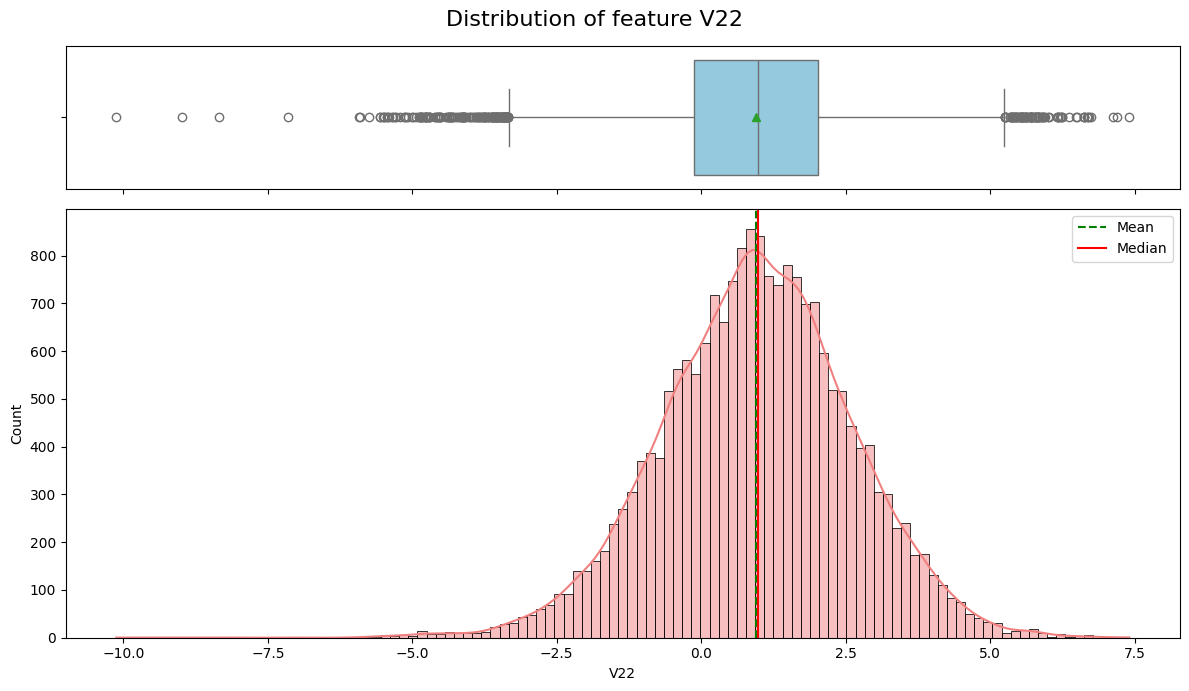

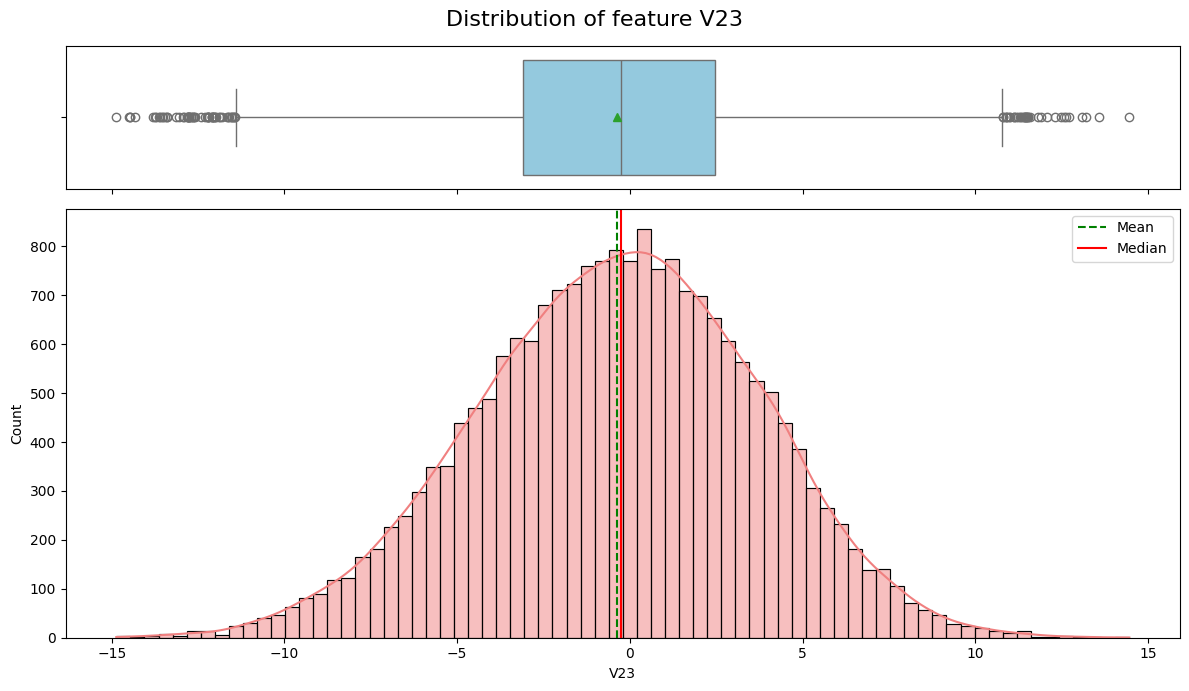

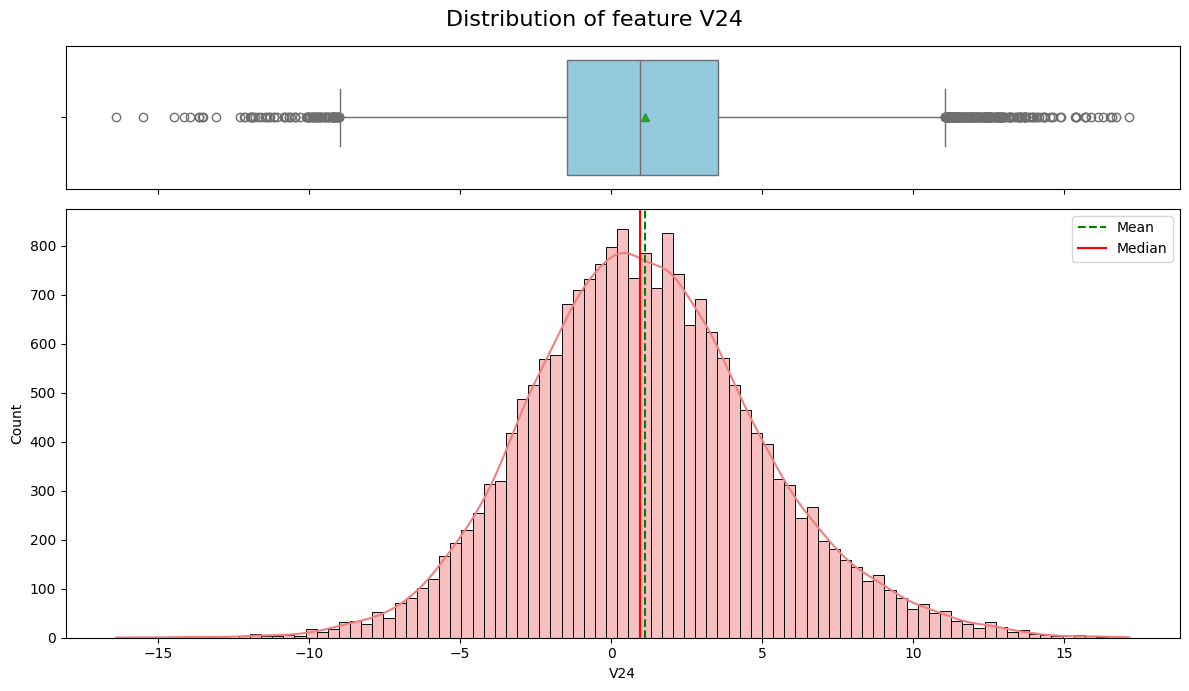

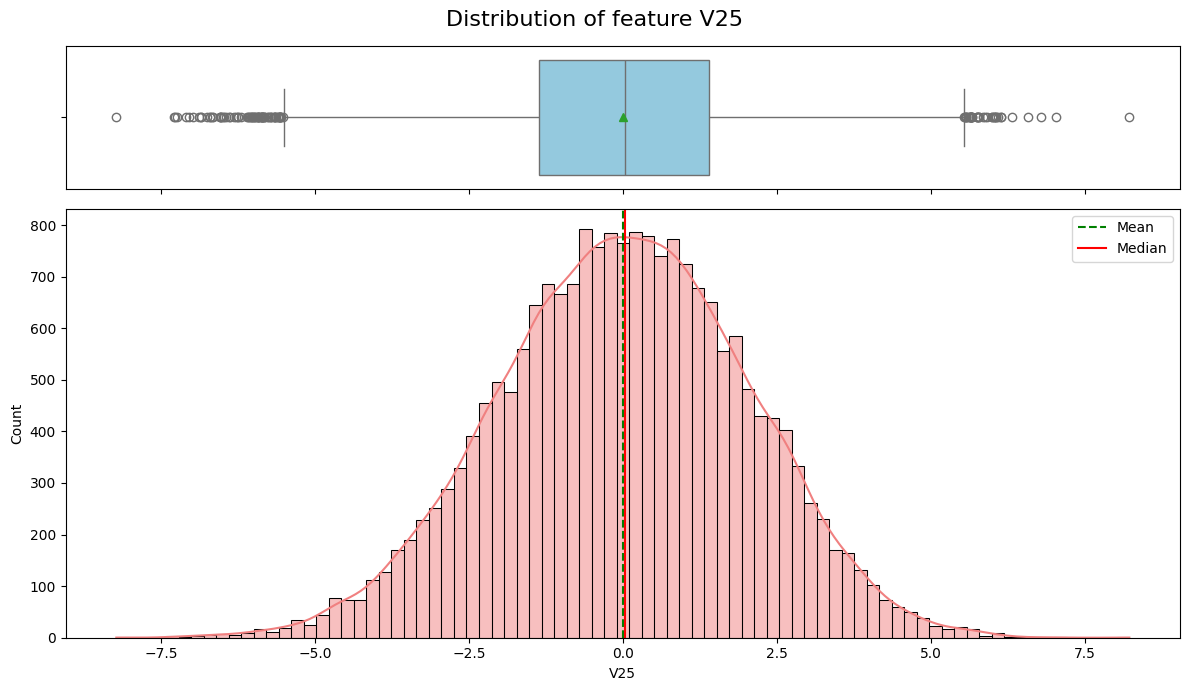

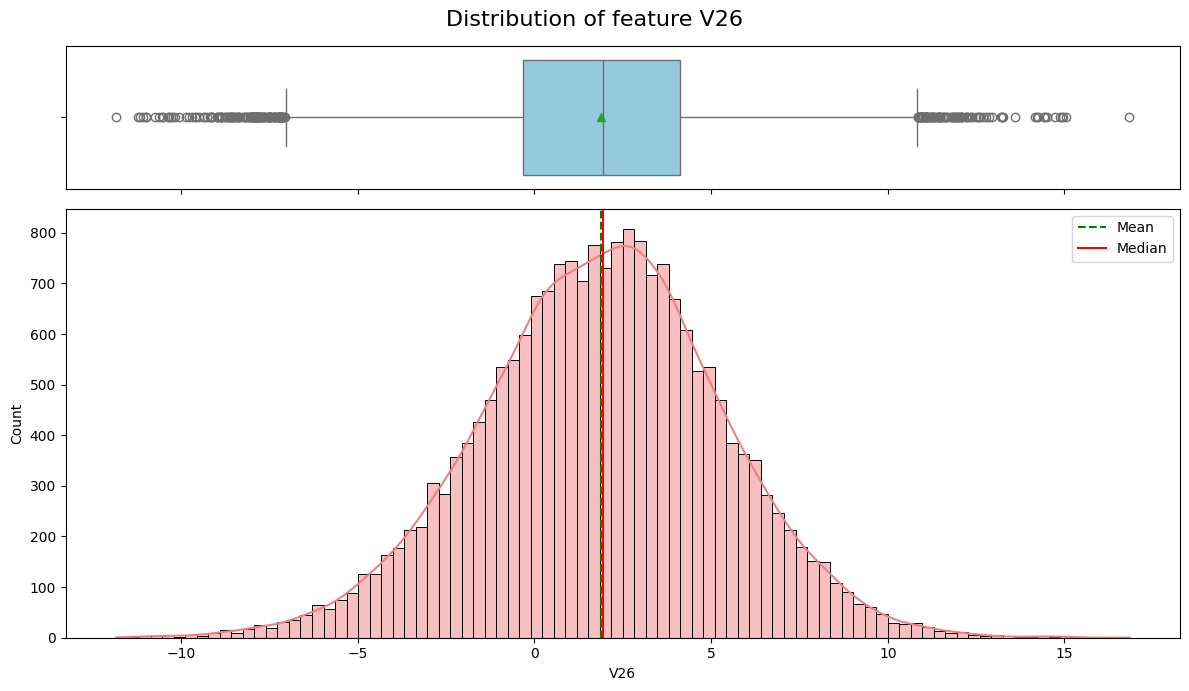

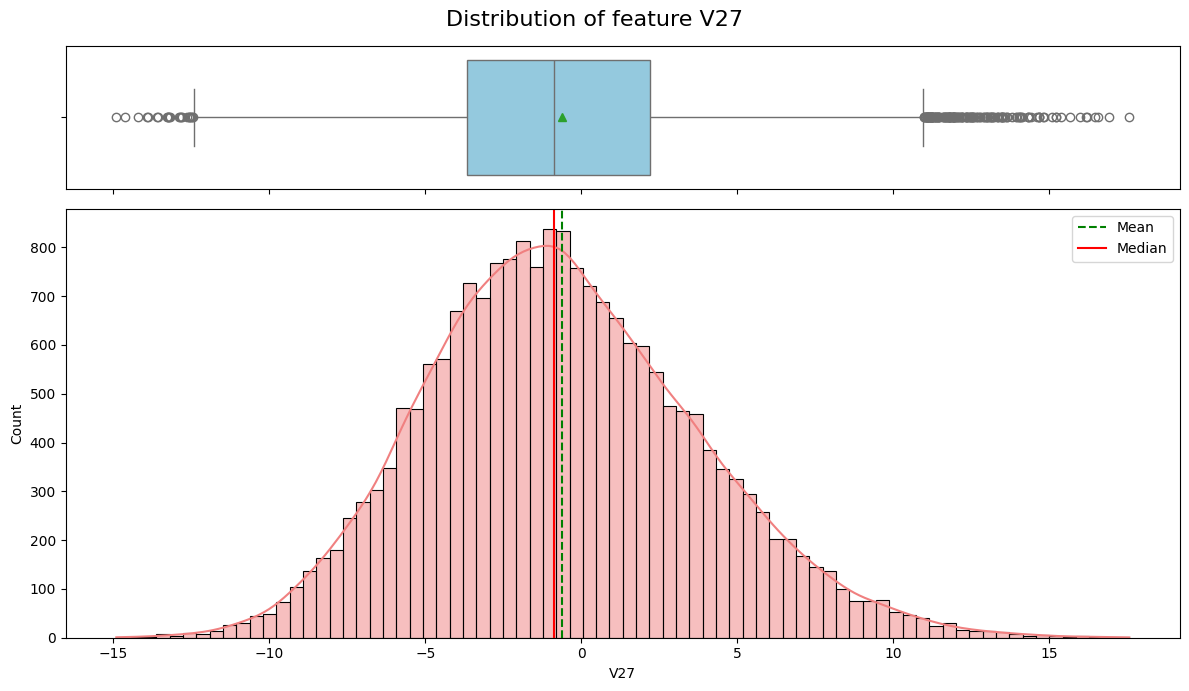

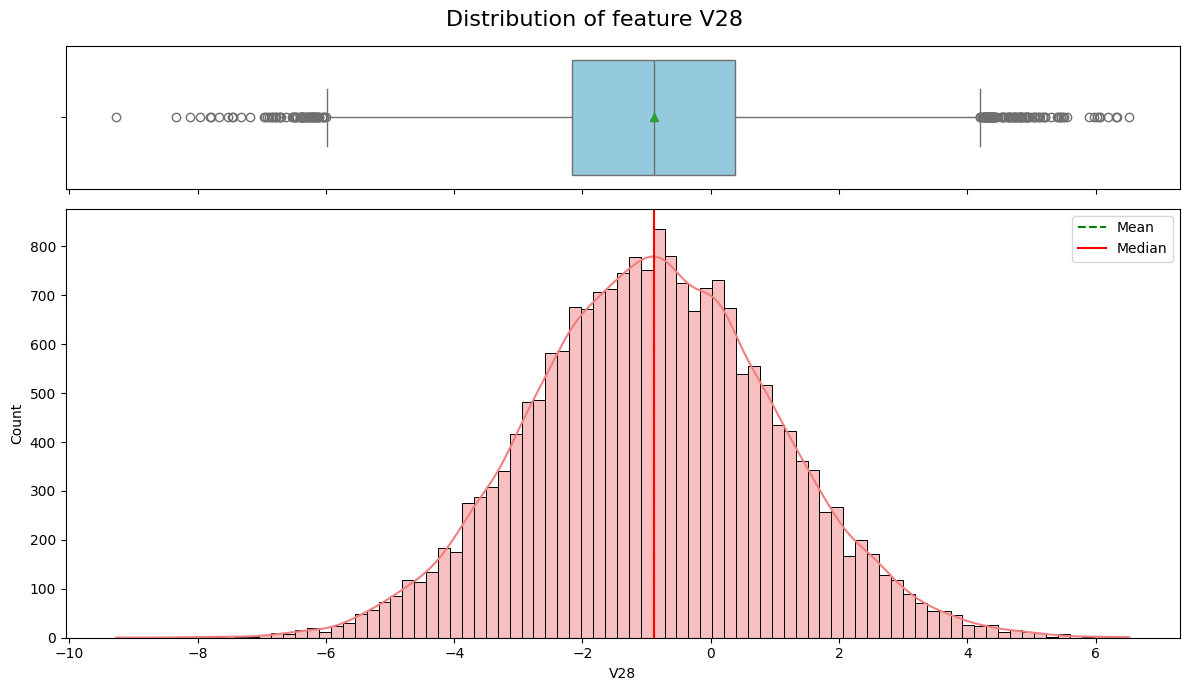

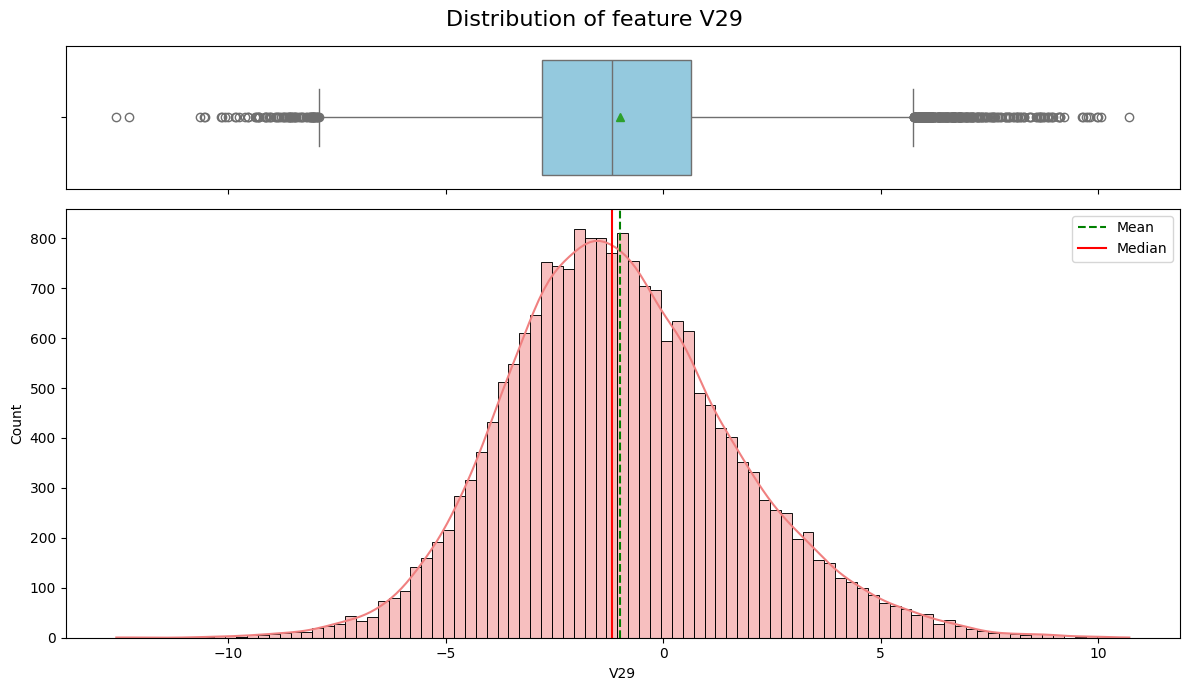

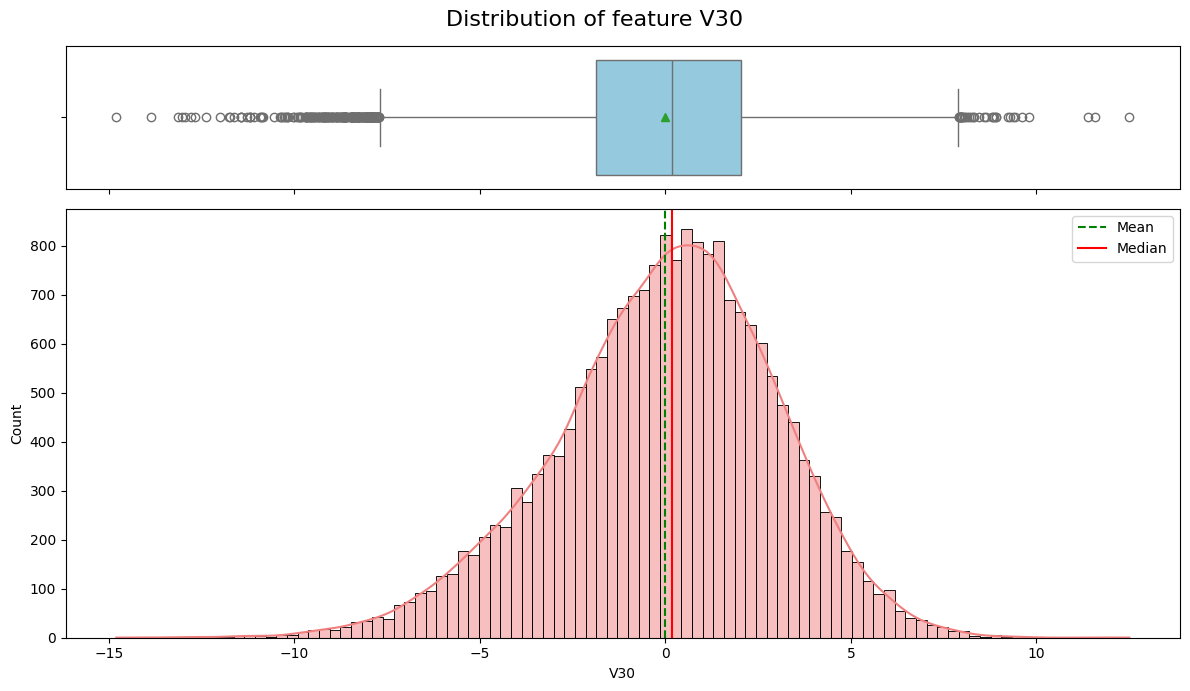

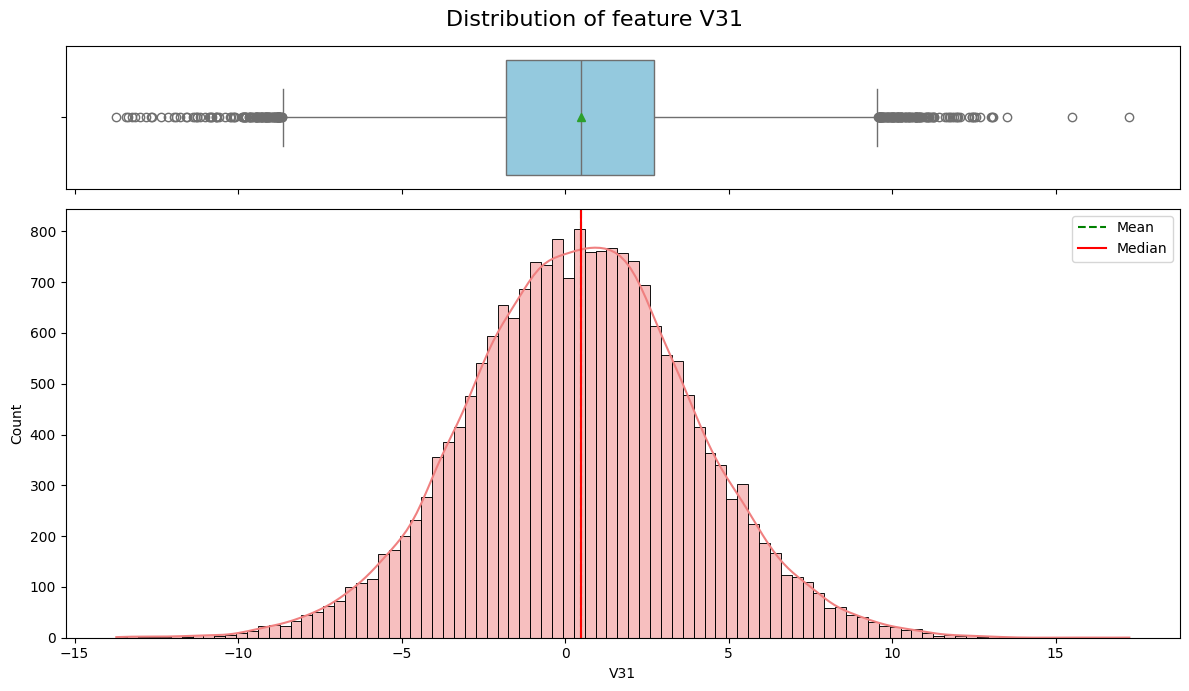

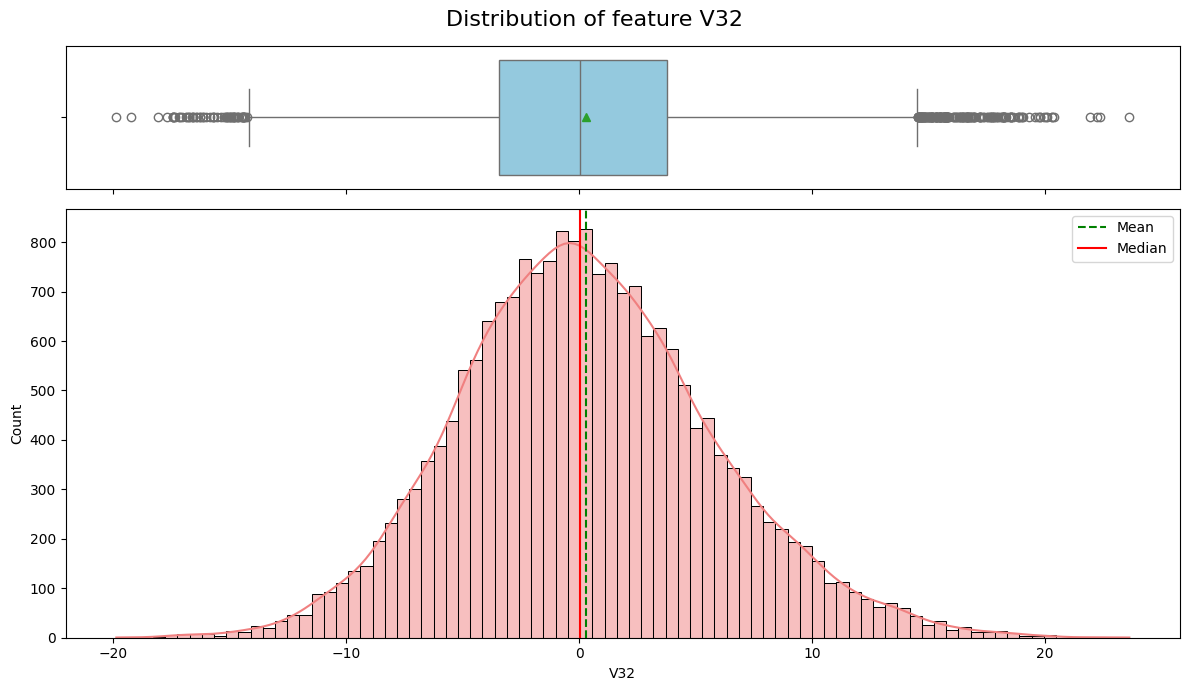

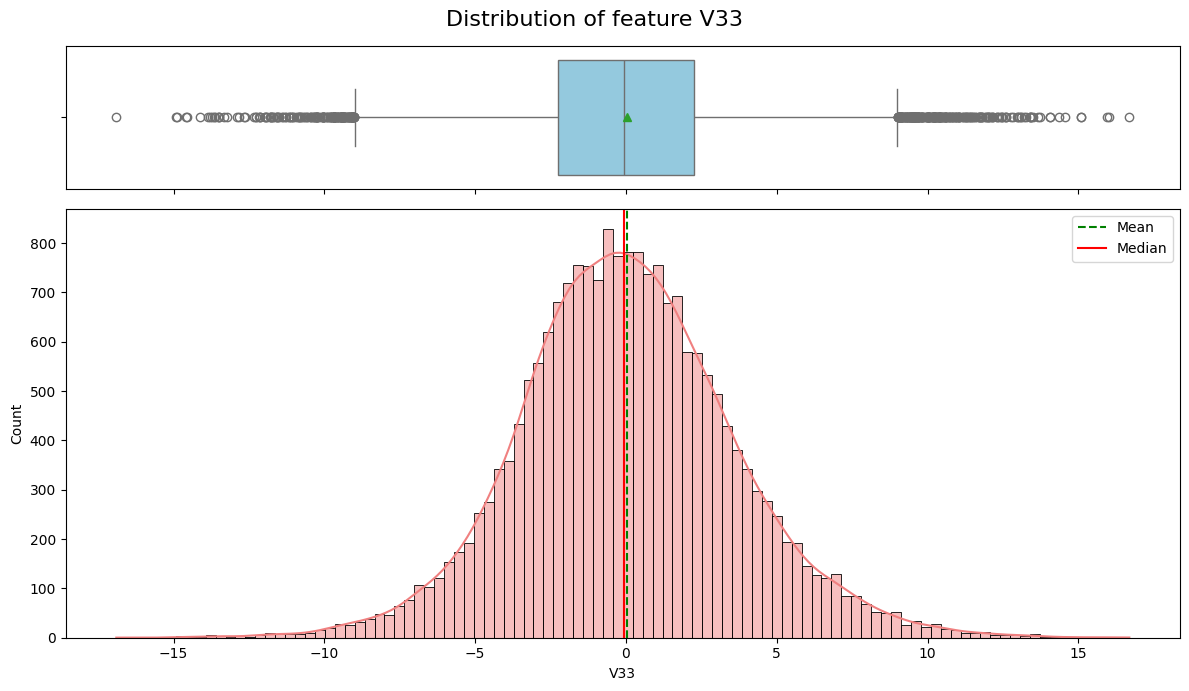

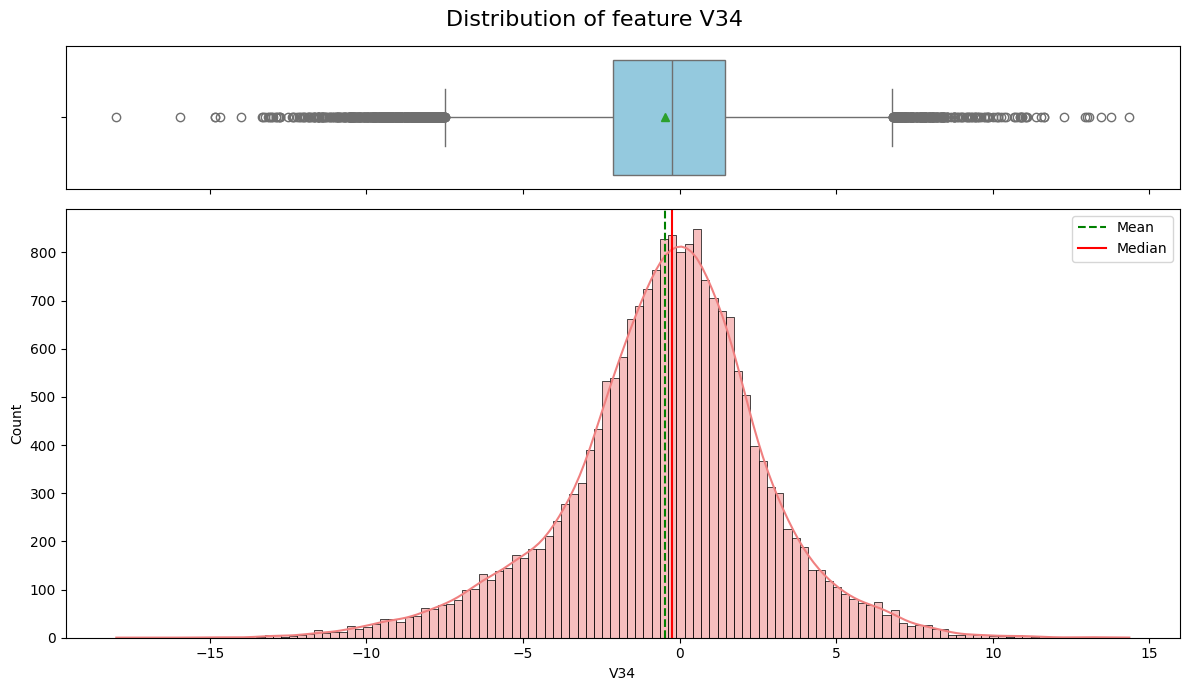

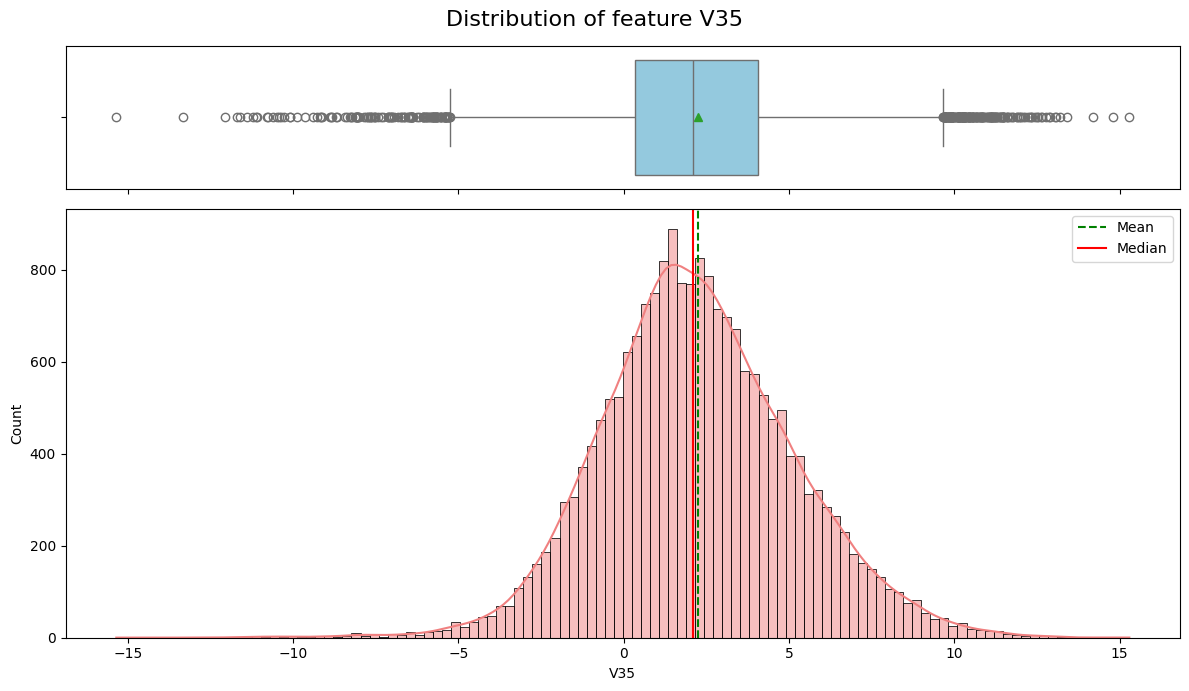

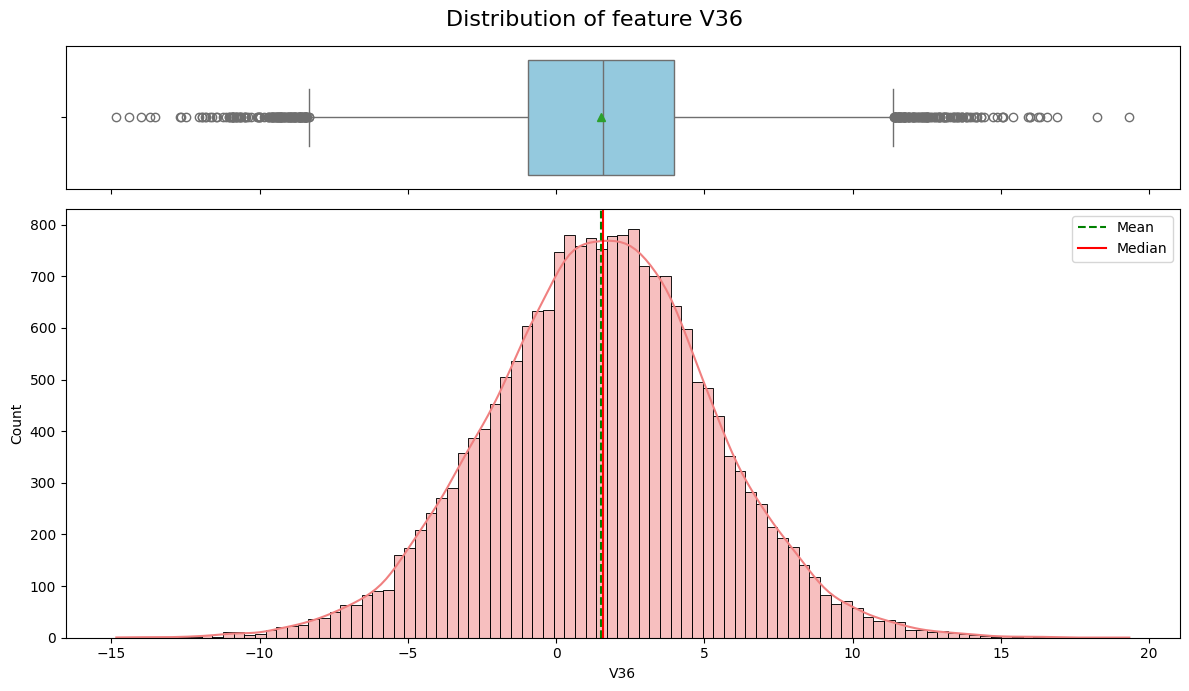

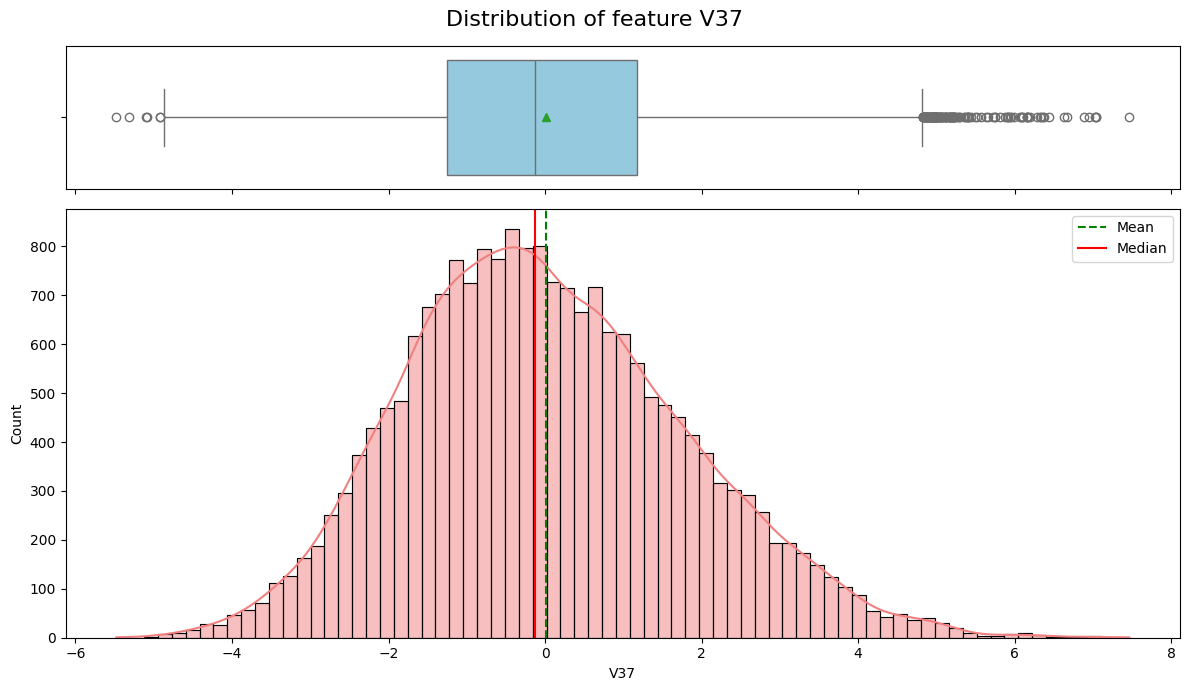

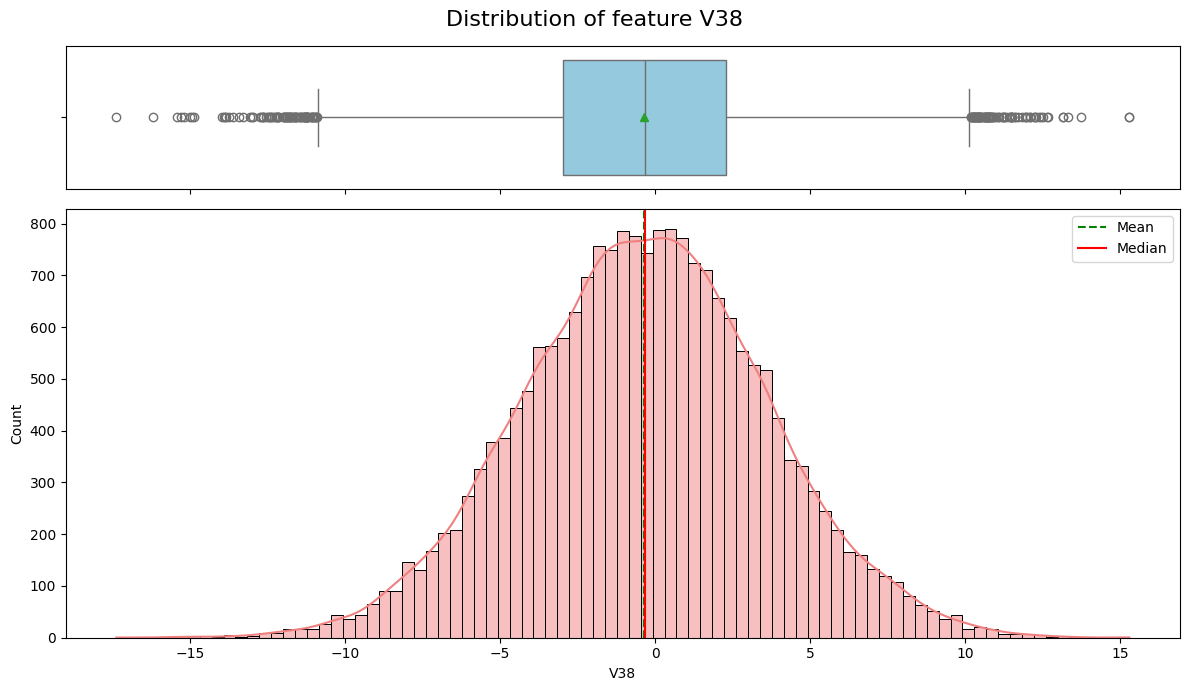

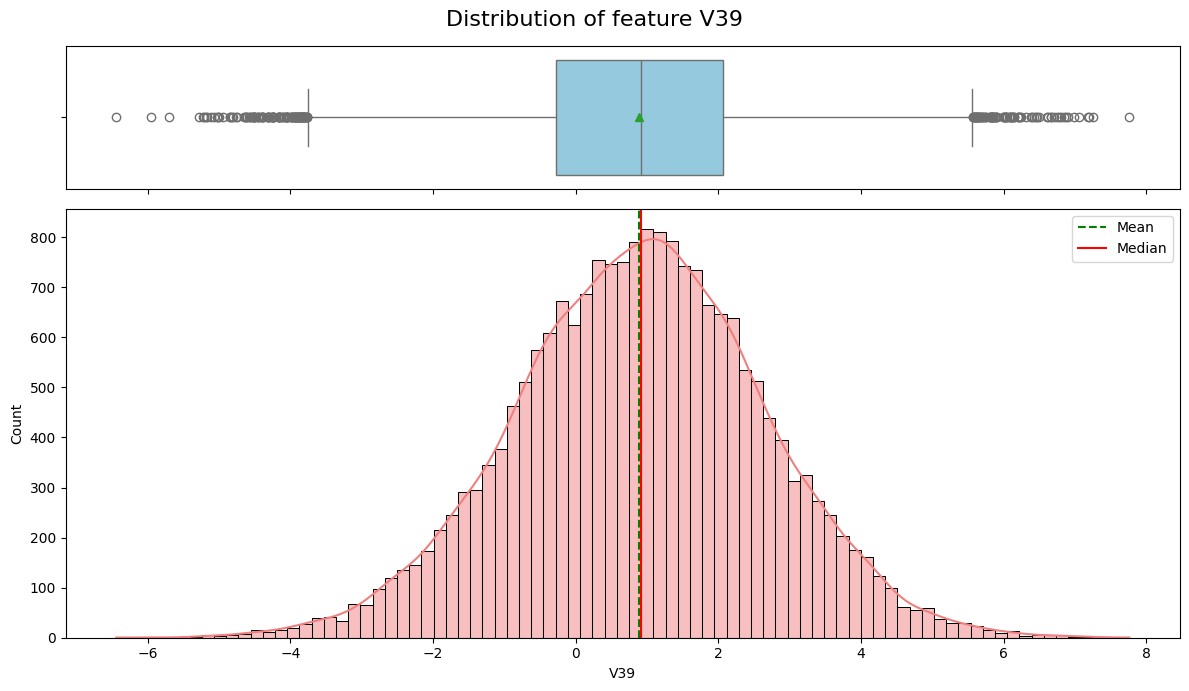

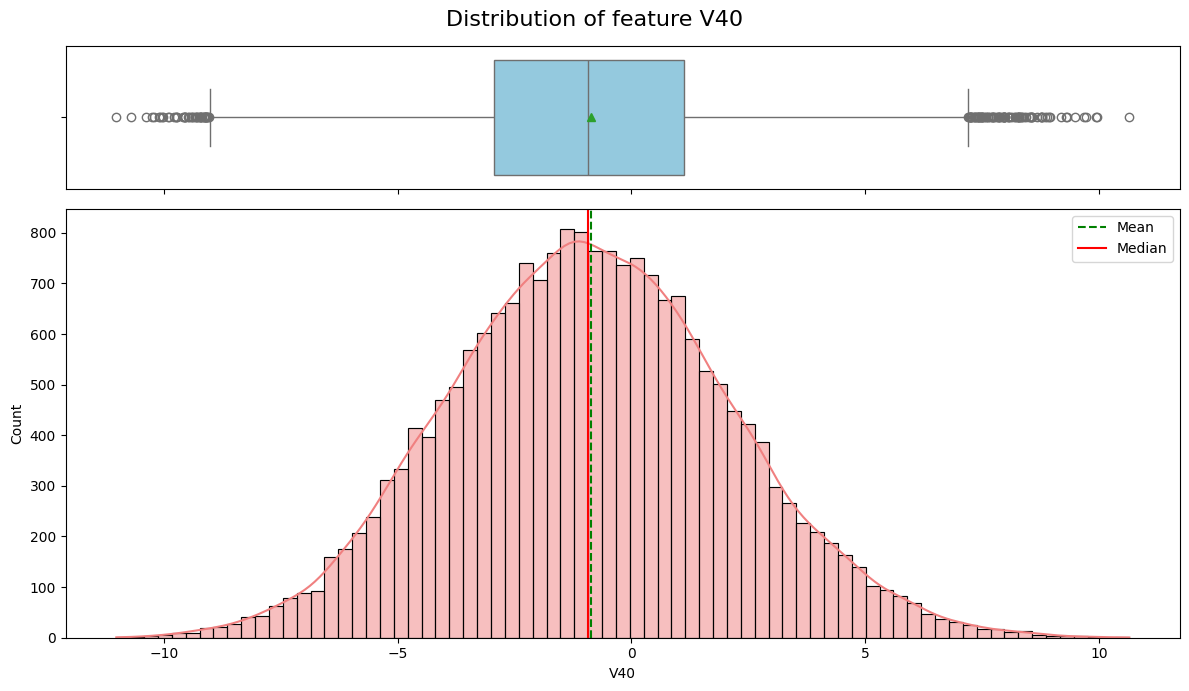

In [ ]:
for feature in test_df.columns.to_list()[:-1]:
    histogram_boxplot(train_df, feature, kde=True, bins=None, title=f"Distribution of feature {feature}")

PCA for Visualization:

type(features_2d) =  <class 'numpy.ndarray'>


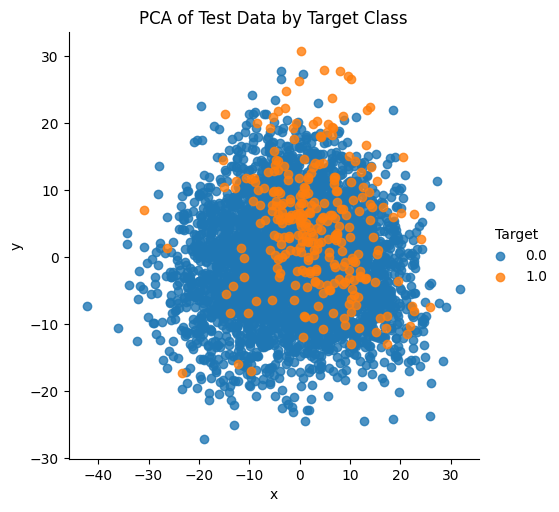

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize data imbalance in testing data using PCA from sklearn using test dataframe
pca = PCA(n_components=2)

# Columns 'V1' and 'V2' have missing values, which will cause an error in fitting.
# For visualization purposes only, we will use column indices from 2 to 39 using iloc.
# Imputation for missing values will be performed after splitting the data
features_2d = pca.fit_transform(test_df.iloc[:,2:39])
print("type(features_2d) = ", type(features_2d))

data_2d= pd.DataFrame(features_2d)
data_2d= pd.concat([data_2d, test_df['Target']], axis=1)
data_2d.columns= ['x', 'y', 'Target']
sns.lmplot(x='x', y='y', data=data_2d, fit_reg=False, hue='Target')
plt.title('PCA of Test Data by Target Class') # Updated title to reflect test data
plt.show() # Ensure the plot is displayed after adding the title

type(features_2d) =  <class 'numpy.ndarray'>


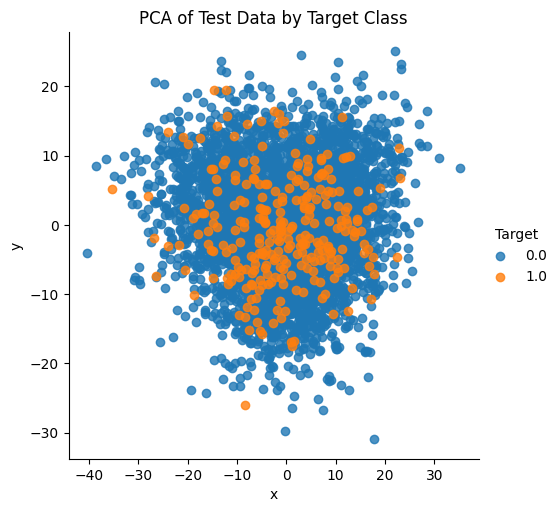

In [ ]:
# Visualize data imbalance using PCA- using train dataframe
pca = PCA(n_components=2)

# Columns 'V1' and 'V2' have missing values, which will cause an error in fitting.
# For visualization purposes only, we will use column indices from 2 to 39.
# Imputation will be performed after splitting the data.
features_2d = pca.fit_transform(train_df.iloc[:,2:39])
print("type(features_2d) = ", type(features_2d))

data_2d= pd.DataFrame(features_2d)
data_2d= pd.concat([data_2d, test_df['Target']], axis=1)
data_2d.columns= ['x', 'y', 'Target']
sns.lmplot(x='x', y='y', data=data_2d, fit_reg=False, hue='Target')
plt.title('PCA of Test Data by Target Class') # Updated title to reflect test data
plt.show() # Ensure the plot is displayed after adding the title

## Bivariate Analysis

Check Correlations

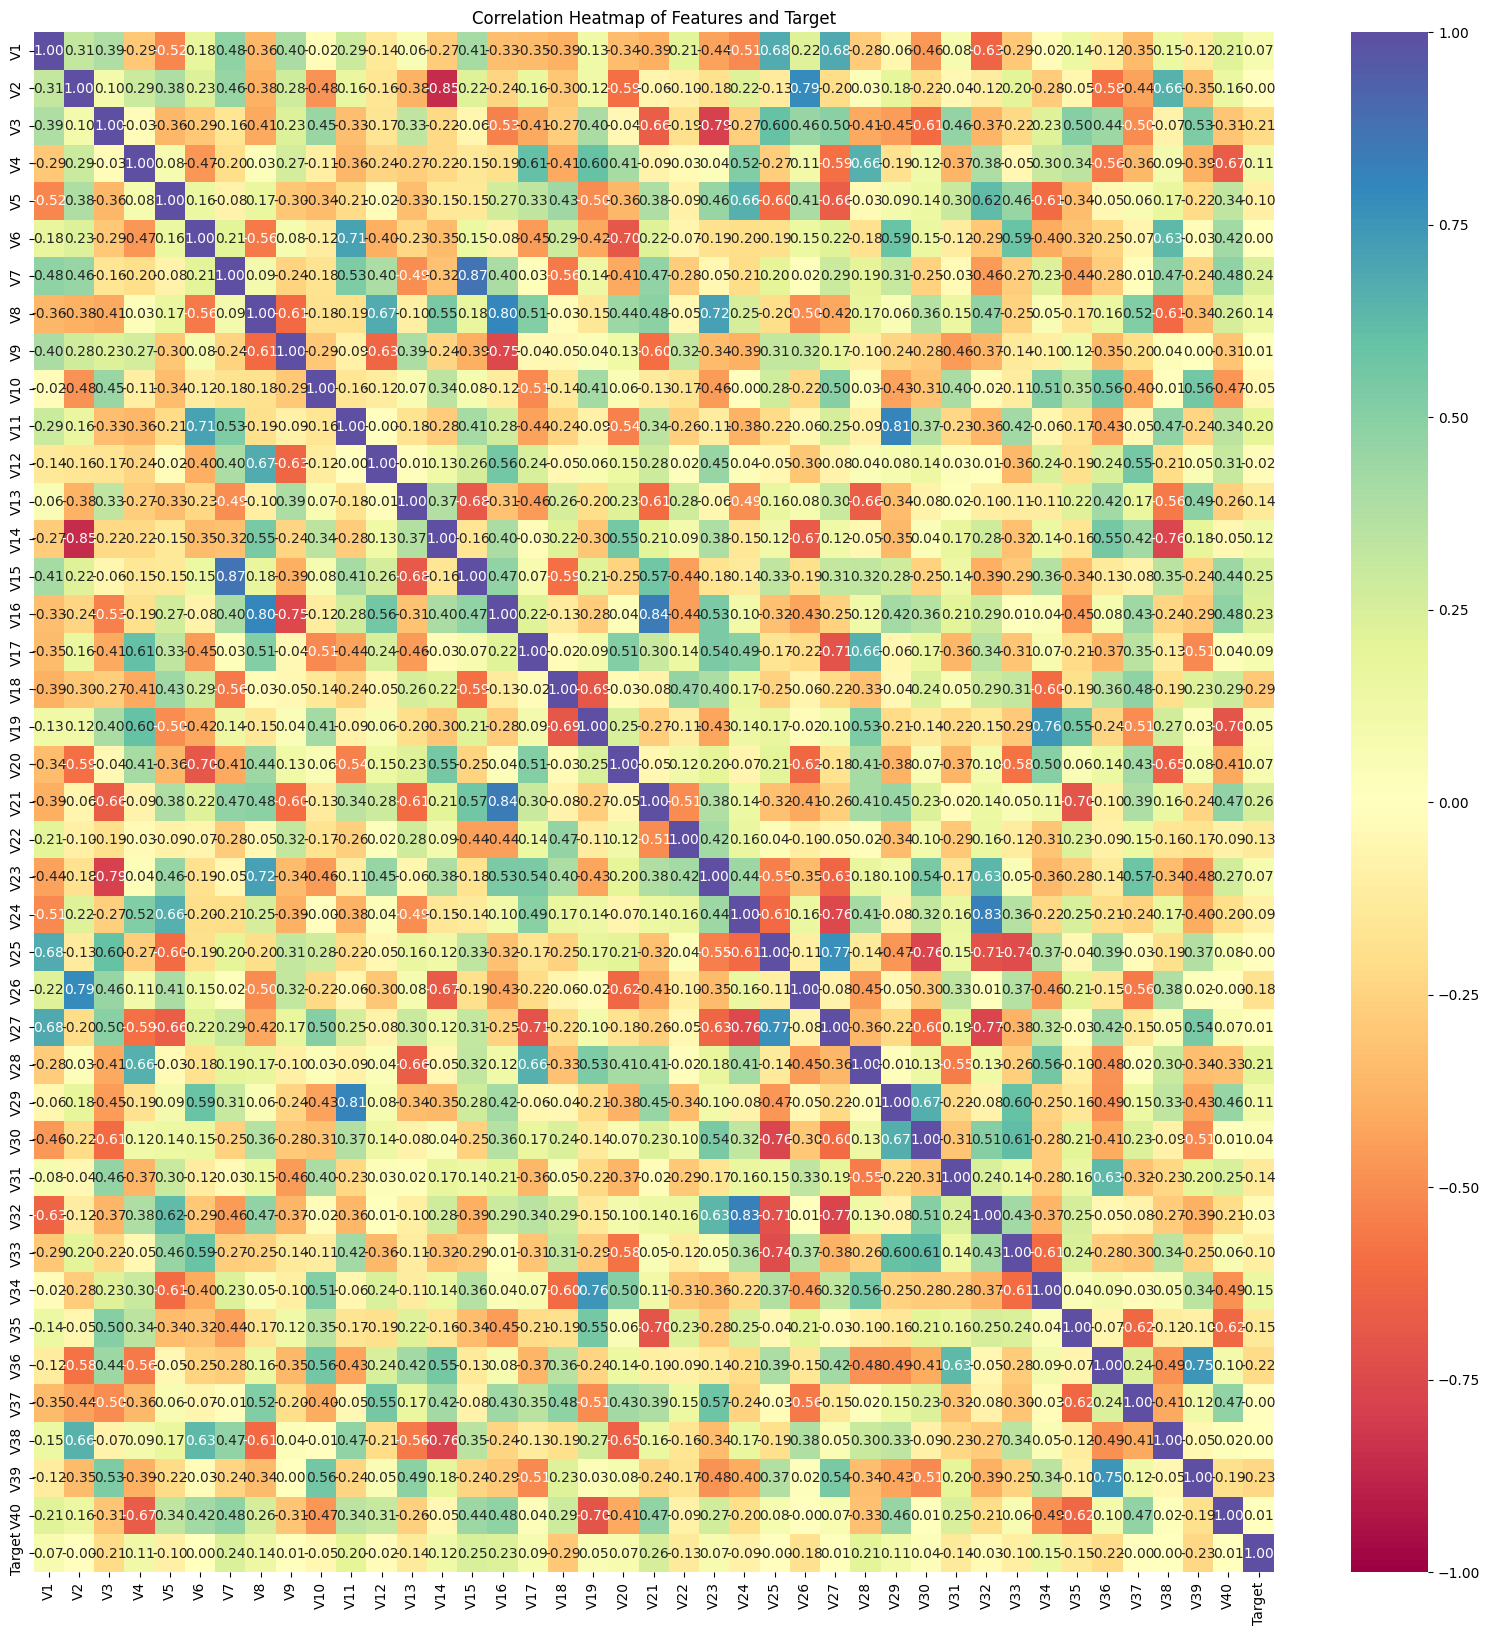

In [ ]:
cols_list = train_df.columns.tolist()

plt.figure(figsize=(20, 20))
sns.heatmap(
    train_df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.title('Correlation Heatmap of Features and Target')
plt.show()

# **Data Preprocessing**

Data Preprocessing for Modeling:

In [ ]:
# Divide train data into X and Y

# Drop the 'Target' column
X = train_df.drop(columns = ["Target"] , axis=1)

# Column named 'Target' becomes y
y = train_df["Target"]

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and validation set with 20% of the data allocated to validation set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [ ]:
# Check the shape of X_train and y_train
print(X_train.shape)
print(y_train.shape)

(16000, 40)
(16000,)


In [ ]:
# Check the shape of X_val and y_val
print(X_val.shape)
print(y_val.shape)

(4000, 40)
(4000,)


In [ ]:
# Divide test data into X_test and y_test

# Drop the 'Target' column for X
X_test = test_df.drop(columns = ['Target'] , axis= 1)

# Retain only 'Target' column for y
y_test = test_df["Target"]

In [ ]:
# Check the shape of X_test and y_test
print(X_test.shape)
print(y_test.shape)

(5000, 40)
(5000,)


In [ ]:
# Check the percentage of classes in target column in training, validation and test set
print("Percentage of classes in Target column in train set : ", y_train.value_counts(1))
print("Percentage of classes in Target column in validation set : ", y_val.value_counts(1))
print("Percentage of classes in Target column in test set : ", y_test.value_counts(1))

Percentage of classes in Target column in train set :  Target
0    0.9445
1    0.0555
Name: proportion, dtype: float64
Percentage of classes in Target column in validation set :  Target
0    0.9445
1    0.0555
Name: proportion, dtype: float64
Percentage of classes in Target column in test set :  Target
0    0.9436
1    0.0564
Name: proportion, dtype: float64


Missing Value Treatment: Using imputation method

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

#Fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transform the validation data using the median calculated from the training data
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)

# Transform the test data using the median calculated from the training data
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

In [ ]:
# Verify that no data set has any values missing
print("Missing values in X_train : ", X_train.isnull().sum())
print("-" * 30)
print("Missing values in X_val : ", X_val.isnull().sum())
print("-" * 30)
print("Missing values in X_test : ", X_test.isnull().sum())

Missing values in X_train :  V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
Missing values in X_val :  V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
Missing values in X_test :  V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0


In [ ]:
# Backup the column names
column_names = X_train.columns.to_list()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardizing all the columns as they have different ranges.
# This is to ensure that all features contribute equally, training becomes more stable, and the network can learn faster

# Initialize StandardScaler
scaler = StandardScaler()

## Scaling the data

In [ ]:
# Fit on X_train and transform X_train, X_val, and X_test
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames with original column names
X_train = pd.DataFrame(X_train_scaled, columns=column_names)
X_val = pd.DataFrame(X_val_scaled, columns=column_names)
X_test = pd.DataFrame(X_test_scaled, columns=column_names)

print("X_train head after scaling:")
display(X_train.head())
print("X_val head after scaling:")
display(X_val.head())
print("X_test head after scaling:")
display(X_test.head())

X_train head after scaling:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40
0,-1.043445,1.511736,-0.387066,0.426921,2.296652,1.194937,-0.137020,-0.081175,-1.302522,-0.354429,...,1.585892,2.097429,3.362098,-1.941270,0.933575,-1.021786,-1.786154,1.176764,-1.401164,0.318215
1,0.010685,-0.558751,0.519278,0.023675,-0.856683,-0.595229,0.163699,0.104608,-0.111118,0.899867,...,0.125800,-0.307970,-0.510204,1.072352,0.228258,0.489994,-0.261596,-0.352934,0.776804,-0.832094
2,-1.498367,-0.999657,-0.670058,-0.023376,0.822463,-0.175202,-1.337900,0.065482,-0.513450,0.947043,...,0.029970,1.468229,0.448939,-0.243510,0.135999,0.866981,0.303072,-0.226521,0.904054,-0.994467
3,1.134798,0.144321,0.481816,-0.210240,-1.016803,0.568228,0.022231,-0.500912,0.076963,0.083444,...,0.006590,-0.318387,0.870166,-0.337173,1.611444,-0.719574,-0.931073,0.364466,-0.861633,-0.015317
4,0.423661,-0.143821,-0.129503,-0.068830,0.148792,-0.404846,0.282059,0.719736,-0.718584,0.297875,...,0.707346,0.589142,-0.270301,-0.195501,0.357480,0.167025,-0.248245,-0.294554,-0.739500,0.346116


X_val head after scaling:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40
0,2.116751,0.683794,2.778608,-0.886828,-1.107947,-0.405846,0.635081,-1.150031,0.885629,0.794183,...,1.583833,-1.891359,-1.168266,0.390895,0.457515,1.293155,-1.177100,-0.179595,1.366135,0.212321
1,1.381619,0.549722,-0.245696,1.041919,-1.133420,0.271992,-0.317997,-0.746294,1.931956,-0.843328,...,-1.215331,-0.017929,0.517652,-0.559742,1.416326,-2.033165,-1.164937,-0.031351,-1.809777,-0.884958
2,-1.006213,-0.450402,-1.242606,-0.657499,0.700961,1.476927,-0.239068,-0.549950,-0.721050,0.502107,...,-0.508019,0.409292,1.079048,-0.295086,-0.617562,0.044931,0.432949,1.120350,0.475594,0.122456
3,-1.174659,0.373290,1.439868,1.373928,0.534154,-1.362923,-0.805973,-0.367344,0.215173,0.690569,...,0.375288,0.182881,-0.679164,1.083469,0.171457,0.774933,-0.470337,0.018709,1.400264,-1.330981
4,0.267139,-0.686989,-1.213498,-0.070388,-0.205630,-0.074807,0.985768,1.382657,0.026763,-0.609017,...,-0.112530,-0.347591,-1.072189,0.394450,-1.846395,-0.273059,0.956017,-1.117705,-1.075039,1.151583


X_test head after scaling:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40
0,-0.097231,-1.346984,-0.081082,0.406552,-0.541413,-1.711811,-0.547878,1.600826,0.575237,-0.151860,...,0.319271,0.361813,-1.526058,0.416247,-0.559140,0.694879,0.790978,-2.577066,-0.252493,-0.191898
1,0.194429,-0.300901,-0.577346,-0.727615,-0.461313,1.581336,0.245526,-1.175847,-0.142580,0.900571,...,-0.660871,-0.507469,0.687649,0.242021,-0.053491,-0.222215,-0.281163,1.384305,0.473908,-0.205139
2,-0.173227,-0.341479,0.476398,-0.439093,0.273466,-0.469924,0.100976,0.574050,-0.795318,0.216656,...,0.703460,-0.296621,-0.850063,0.287390,-0.543715,1.084154,0.732382,-0.358455,0.524144,0.845610
3,0.150459,0.322501,0.455758,0.767542,0.593138,-1.037321,-0.029123,0.246213,0.629479,0.324167,...,0.965703,0.585549,-0.871520,0.053831,-0.429699,0.397080,-0.775196,-0.778912,0.006457,-0.524834
4,1.775758,0.736738,-1.099185,0.847923,-0.758956,-0.200402,0.820130,0.457777,0.907435,-1.260929,...,-1.187252,0.267452,-0.431154,-0.556054,0.871961,-2.134793,-0.460511,0.015438,-2.726961,0.110533


In [ ]:
print("type(X_train) : ", type(X_train))
print("type(X_val) : ", type(X_val))
print("type(X_test) : ", type(X_test))

type(X_train) :  <class 'pandas.core.frame.DataFrame'>
type(X_val) :  <class 'pandas.core.frame.DataFrame'>
type(X_test) :  <class 'pandas.core.frame.DataFrame'>


In [ ]:
print("X_train shape : ", X_train.shape)
print("X_val shape : ", X_val.shape)
print("X_test shape : ", X_test.shape)

X_train shape :  (16000, 40)
X_val shape :  (4000, 40)
X_test shape :  (5000, 40)


In [ ]:
# Convert target variables to NumPy arrays for compatibility with neural network libraries
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

In [ ]:
print("y_train shape : ", y_train.shape)
print("y_val shape : ", y_val.shape)
print("y_test shape : ", y_test.shape)

y_train shape :  (16000,)
y_val shape :  (4000,)
y_test shape :  (5000,)


Checking Data Transformations:

In [ ]:
print("type(X_train) : ", type(X_train), "type(y_train) = ", type(y_train))
print("type(X_val) : ", type(X_val), "type(y_val) = ", type(y_val))
print("type(X_test) : ", type(X_test), "type(y_test) = ", type(y_test))

type(X_train) :  <class 'pandas.core.frame.DataFrame'> type(y_train) =  <class 'numpy.ndarray'>
type(X_val) :  <class 'pandas.core.frame.DataFrame'> type(y_val) =  <class 'numpy.ndarray'>
type(X_test) :  <class 'pandas.core.frame.DataFrame'> type(y_test) =  <class 'numpy.ndarray'>


Observations:


# **Model Building**

## Model Evaluation Criterion

Write down the model evaluation criterion with rationale

In this problem, we are looking to predict generator failures. We split the outcome possibilities into two classes:


*   Class 1: Failure
*   Class 2: No Failure

In evaluating a classification model, we consider four possible model outcomes:


*   True Positive: Model predicts a failure and it is actually a failure. This outcome results in repair costs.
*   True Negative: The model predicts no failure and there is no faiure.
*   False Negative: The model incorrectly predicts no failure when it is actually failure. False negatives represent a high cost as they signify a generator replacement.
*   False Positive: The model predicts failure when there is no failure. This signifies inspection costs.

The economic cost value of a false negative (replacement)  is higher than that of a false positive (inspection).

The cost hierarchy is as follows: Replacement> Repair> Inspection.

Minimizing false negatives is crucial, so the model needs a high recall for the positive class (failure).

Recall measures the model's ability to identify all actual positive (failure) instances. A higher recall means the model is better at detecting failures, thus reducing the number of missed failures (False Negatives) and the associated high replacement costs.







## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

Function Plots to Evaluate Model Performance:

In [ ]:
def plot(history, name, model_config):
    """
    Function to plot loss/accuracy
    """
    #Creating a subplot with figure and axes.
    fig, ax = plt.subplots()
    #Plotting the train accuracy or train loss
    plt.plot(history.history[name])
    #Plotting the validation accuracy or validation loss
    plt.plot(history.history['val_'+name])

    #Defining the title of the plot
    ax.set_title(f"Model - {name.capitalize()}\n{model_config}", fontsize=10)
    #Capitalizing the first letter
    plt.ylabel(name.capitalize())
    #Defining the label for the x-axis
    plt.xlabel('Epoch')
    #Defining the legend, loc controls the position of the legend.
    fig.legend(['Train', 'Validation'], loc="outside lower right")

In [ ]:
# Define a function to compute different metrics to check performance of a classification model built using statsmodels
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    #print("type(pred) : ", type(pred), "Sample values : ", pred[0:5, :])
    #print("type(target) : ", type(target), "Sample values : ", target[0:5])

    acc = accuracy_score(target, pred)  # Compute Accuracy
    recall = recall_score(target, pred, average='macro')  # Compute Recall
    precision = precision_score(target, pred, average='macro')  # Compute Precision
    f1 = f1_score(target, pred, average='macro')  # Compute F1-score

    # Creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,}, index = [0]
    )

    return df_perf

In [ ]:
# Define function to plot sklearn confusion matrix using seaborn heatmap visalisation
def make_confusion_matrix(cf,
                          group_names=['True Negative','False Positive','False Negative','True Positive'],
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):
    print(cf)

    # Code to generate text inside each sqaure
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])

    # Code to generate summary statistics and text for summary stats
    if sum_stats:
        # Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))

        # Show some more stats for binary confusion matrix
        if len(cf)==2:
            # Metrics for Binary Confusion Matrices
            precision = cf[1,1] / sum(cf[:,1])
            recall    = cf[1,1] / sum(cf[1,:])
            f1_score  = 2*precision*recall / (precision + recall)
            stats_text = "\n\nAccuracy={:0.3f}\nPrecision={:0.3f}\nRecall={:0.3f}\nF1 Score={:0.3f}".format(
                accuracy,precision,recall,f1_score)
        else:
            stats_text = "\n\nAccuracy={:0.3f}".format(accuracy)
    else:
        stats_text = ""


    # Set figure parameters according to other arguments
    if figsize==None:
        # Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        # Do not show categories if xyticks is False
        categories=False

    # Plot heatmap visualisation
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)

    if xyplotlabels:
        plt.ylabel('True label')
        plt.xlabel('Predicted label' + stats_text)
    else:
        plt.xlabel(stats_text)

    if title:
        plt.title(title, fontsize=10)

In [ ]:
import numpy as np

# Since the class is imabalnced in the data, we'll use class weights in all the models
# Calculate class weights for imbalanced dataset. This gives higher weight to the minority class.
cw = (y_train.shape[0]) / np.bincount(y_train.astype(int))

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587612493382743), 1: np.float64(18.01801801801802)}

Baseline Model:

In [ ]:
# Define model configuration string to use in the title of graphs
model_0_config = "(1HL,7N,relu \n sgd \n bs32, 25E) "

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Initializing the sequential model
model_0 = Sequential()

# Add the first hidden layer with 7 neurons, ReLU activation, and input dimension matching the number of features in X_train
model_0.add(Dense(7, activation="relu",input_dim=X_train.shape[1]))

# Add the output layer with 1 neuron and sigmoid activation for binary classification probability output
model_0.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

# Define SGD as the optimizer to be used
optimizer = tf.keras.optimizers.SGD()

# Recall is the chosen metric to measure
model_0.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [ ]:
import time

start = time.time()
history = model_0.fit(X_train, y_train, validation_data=(X_val,y_val), batch_size=32, epochs=25, class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - Recall: 0.9020 - loss: 0.8449 - val_Recall: 0.9099 - val_loss: 0.3568
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.9009 - loss: 0.6161 - val_Recall: 0.8784 - val_loss: 0.2633
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8874 - loss: 0.5513 - val_Recall: 0.8829 - val_loss: 0.2423
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8941 - loss: 0.5120 - val_Recall: 0.8739 - val_loss: 0.2173
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.8941 - loss: 0.4926 - val_Recall: 0.8829 - val_loss: 0.1938
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - Recall: 0.8941 - loss: 0.4781 - val_Recall: 0.8829 - val_loss: 0.2090
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.8896 - loss: 0.4675 - val_Recall: 0.8694 - val_loss: 0.1746
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8941 - loss: 0.4628 - val_Recall: 0.8964 - val_loss: 0.2055
Epoch 9/

In [ ]:
print("Time taken in seconds ",end - start)

Time taken in seconds  36.78036284446716


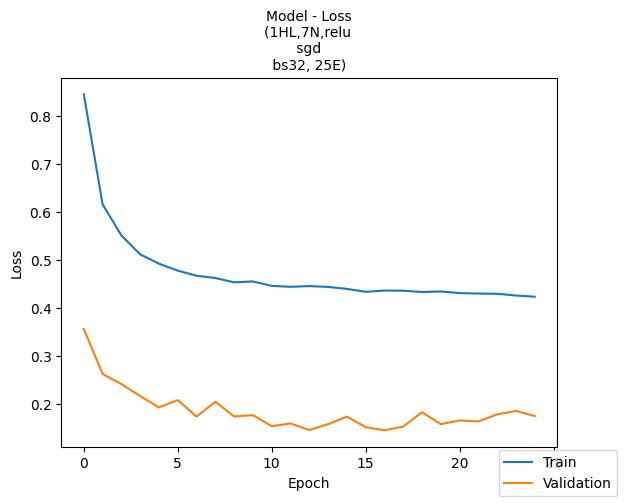

In [ ]:
plot(history,'loss', model_0_config)

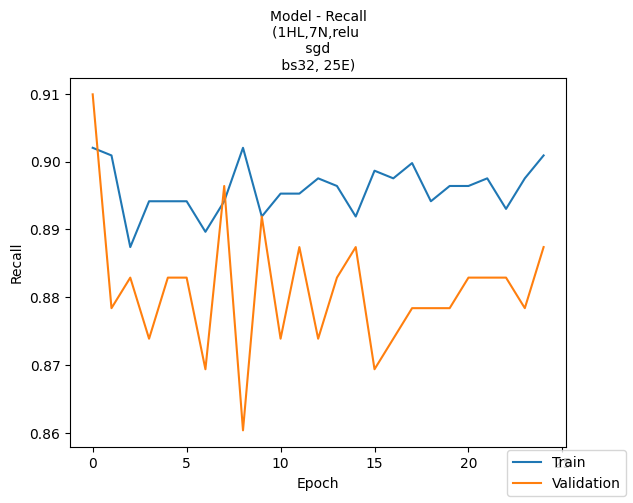

In [ ]:
plot(history,'Recall', model_0_config)

In [ ]:
model_0_train_perf = model_performance_classification(model_0, X_train, y_train)
model_0_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.954937,0.928977,0.776121,0.832399


In [ ]:
model_0_val_perf = model_performance_classification(model_0, X_val, y_val)
model_0_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.95425,0.922783,0.774035,0.829095


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[4532  186]
 [  40  242]]


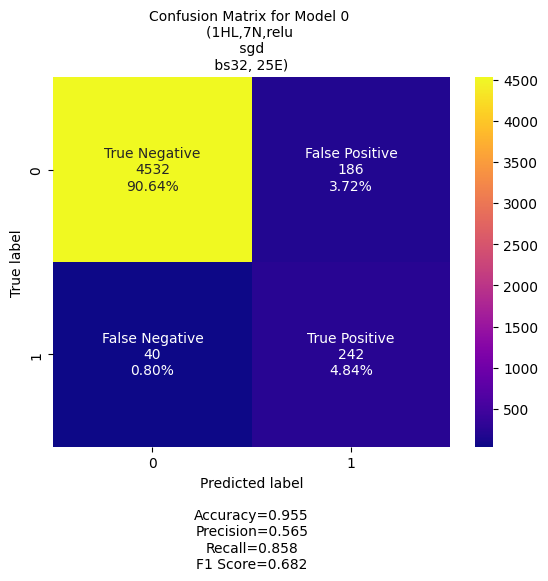

In [ ]:
# Evaluate model performance on the test set and visualize the confusion matrix.
y_test_pred = model_0.predict(X_test)
# y_test_pred[0:10, :]
for i in range(len(y_test)):
    if y_test_pred[i]>0.5:
        y_test_pred[i]=1
    else:
        y_test_pred[i]=0

cm2=confusion_matrix(y_test, y_test_pred)
make_confusion_matrix(
    cm2,
    cmap='plasma',
    title="Confusion Matrix for Model 0 \n" + model_0_config
    )

Baseline Model:


*   The loss function shows a steep decrease in the initial epochs and then stabilizes, indicating convergence.
*   Recall on the training set is: 92.89%
*   Recall on the validation set is: 92.27%
*   Recall on the test set is: 85.8%
*   The number of false negatives is 40, the number of false positives is 186.







# **Model Performance Improvement**

## Model 1: Increasing Epochs

In [ ]:
# Define model configuration string to use in the title of graphs
model_1_config = "(1HL,7N,relu \n sgd \n bs32, 50E) "

In [ ]:
# Initializing the sequential model
model_1 = Sequential()

# Add the first hidden layer with 7 neurons, ReLU activation, and input dimension matching the number of features in X_train
model_1.add(Dense(7, activation="relu",input_dim=X_train.shape[1]))

# Add the output layer with 1 neuron and sigmoid activation for binary classification probability output
model_1.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define SGD as the optimizer to be used
optimizer = tf.keras.optimizers.SGD()

# Recall is the chosen metric to measure
model_1.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [ ]:
start = time.time()
history = model_1.fit(X_train, y_train, validation_data=(X_val,y_val), batch_size=32, epochs=50, class_weight=cw_dict)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - Recall: 0.8514 - loss: 0.8672 - val_Recall: 0.8694 - val_loss: 0.3535
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - Recall: 0.8818 - loss: 0.6371 - val_Recall: 0.8694 - val_loss: 0.2727
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - Recall: 0.8851 - loss: 0.5748 - val_Recall: 0.8784 - val_loss: 0.2418
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - Recall: 0.8896 - loss: 0.5399 - val_Recall: 0.8739 - val_loss: 0.2384
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - Recall: 0.8941 - loss: 0.5188 - val_Recall: 0.8784 - val_loss: 0.2078
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - Recall: 0.8919 - loss: 0.5002 - val_Recall: 0.8874 - val_loss: 0.2177
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - Recall: 0.8930 - loss: 0.4899 - val_Recall: 0.8739 - val_loss: 0.1946
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - Recall: 0.8919 - loss: 0.4797 - val_Recall: 0.8874 - val_loss: 0.2088
Epoch 

In [ ]:
print("Time taken in seconds ",end - start)

Time taken in seconds  95.38610434532166


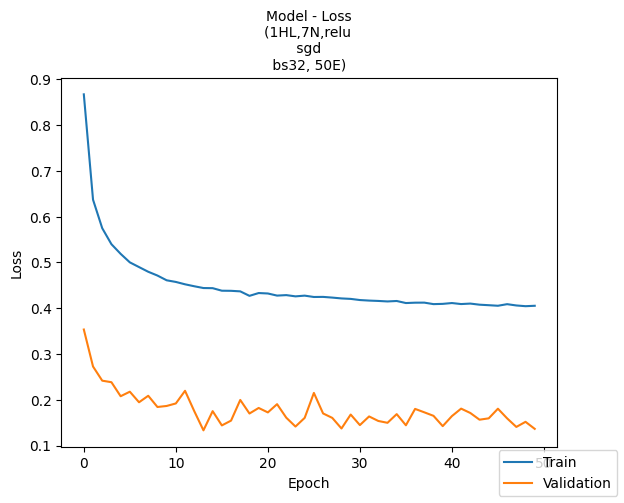

In [ ]:
plot(history,'loss', model_1_config)

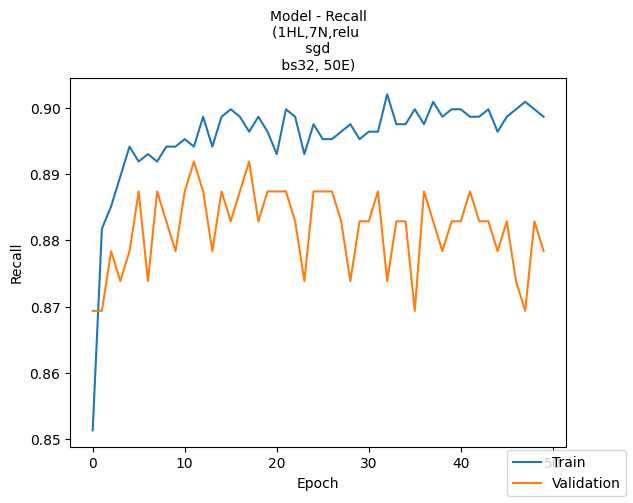

In [ ]:
plot(history,'Recall', model_1_config)

In [ ]:
model_1_train_perf = model_performance_classification(model_1, X_train, y_train)
model_1_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.972938,0.937446,0.846807,0.885969


In [ ]:
model_1_val_perf = model_performance_classification(model_1, X_val, y_val)
model_1_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.97425,0.929131,0.856158,0.888677


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[4622   96]
 [  47  235]]


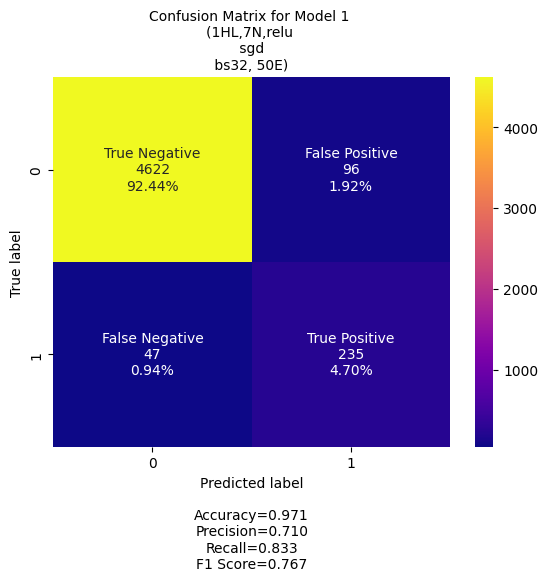

In [ ]:
# Evaluate Model 0 performance on the test set and visualize the confusion matrix.
y_test_pred = model_1.predict(X_test)
#print(y_test_pred[0:10, :])
for i in range(len(y_test)):
    if y_test_pred[i]>0.5:
        y_test_pred[i]=1
    else:
        y_test_pred[i]=0

cm2=confusion_matrix(y_test, y_test_pred)
make_confusion_matrix(
    cm2,
    cmap='plasma',
    title="Confusion Matrix for Model 1 \n" + model_1_config
    )

## Model 2: Increasing Batch Size

In [ ]:
# Define model configuration string to use in the title of graphs
model_2_config = "(1HL,7N,relu \n sgd \n bs64, 25E) "

In [ ]:
# Initializing the sequential model
model_2 = Sequential()

# Add the first hidden layer with 7 neurons, ReLU activation, and input dimension matching the number of features in X_train
model_2.add(Dense(7, activation="relu",input_dim=X_train.shape[1]))

# Add the output layer with 1 neuron and sigmoid activation for binary classification probability output
model_2.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define SGD as the optimizer to be used
optimizer = tf.keras.optimizers.SGD()

# Recall is the chosen metric to measure
model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [ ]:
start = time.time()
history = model_2.fit(X_train, y_train, validation_data=(X_val,y_val), batch_size=64, epochs=25, class_weight=cw_dict)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.7432 - loss: 0.9928 - val_Recall: 0.8694 - val_loss: 0.4130
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.8615 - loss: 0.7111 - val_Recall: 0.8694 - val_loss: 0.3257
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.8660 - loss: 0.6388 - val_Recall: 0.8649 - val_loss: 0.3024
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8851 - loss: 0.5950 - val_Recall: 0.8604 - val_loss: 0.2576
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8863 - loss: 0.5615 - val_Recall: 0.8649 - val_loss: 0.2470
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8863 - loss: 0.5384 - val_Recall: 0.8739 - val_loss: 0.2242
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8863 - loss: 0.5190 - val_Recall: 0.8694 - val_loss: 0.2108
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8885 - loss: 0.5064 - val_Recall: 0.8649 - val_loss: 0.2281
Epoch 9/

In [ ]:
print("Time taken in seconds ",end - start)

Time taken in seconds  20.206169366836548


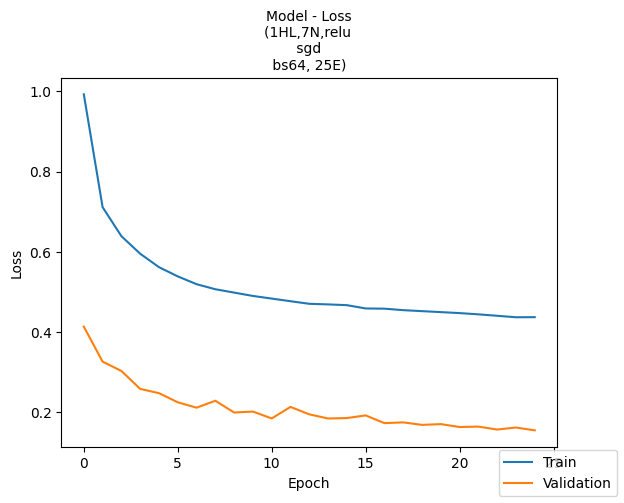

In [ ]:
plot(history,'loss', model_2_config)

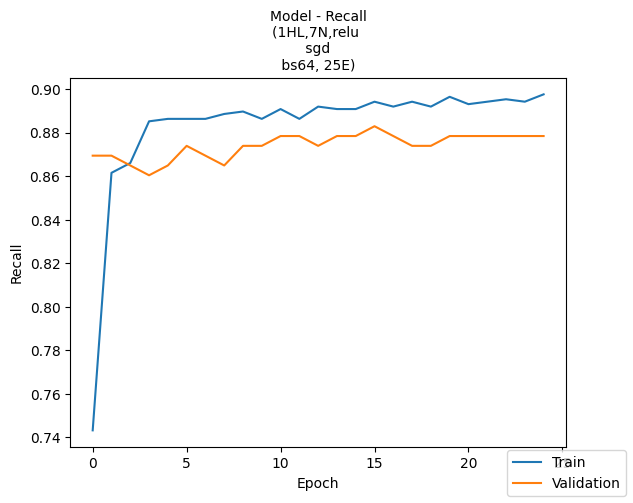

In [ ]:
plot(history,'Recall', model_2_config)

In [ ]:
model_2_train_perf = model_performance_classification(model_2, X_train, y_train)
model_2_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.964875,0.932118,0.811322,0.860009


In [ ]:
model_2_val_perf = model_performance_classification(model_2, X_val, y_val)
model_2_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.96725,0.925425,0.822439,0.865522


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[4586  132]
 [  41  241]]


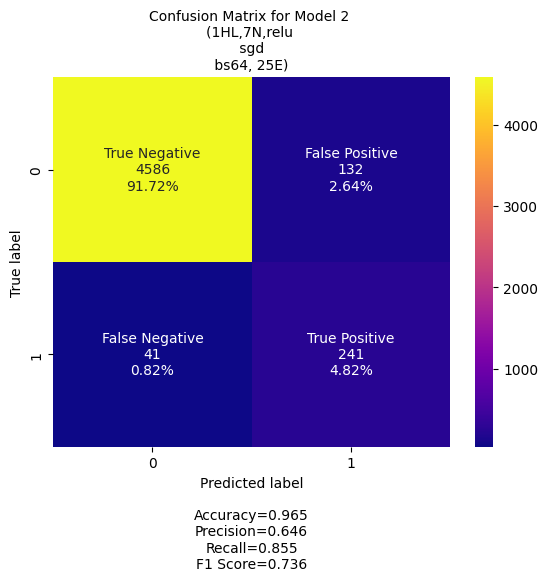

In [ ]:
# Evaluate model performance on the test set and visualize the confusion matrix.
y_test_pred = model_2.predict(X_test)
#print(y_test_pred[0:10, :])
for i in range(len(y_test)):
    if y_test_pred[i]>0.5:
        y_test_pred[i]=1
    else:
        y_test_pred[i]=0

cm2=confusion_matrix(y_test, y_test_pred)
make_confusion_matrix(
    cm2,
    cmap='plasma',
    title="Confusion Matrix for Model 2 \n" + model_2_config
    )

## Model 3: Add Additional Hidden Layer

In [ ]:
# Define model configuration string to use in the title of graphs
model_3_config = "(1HL,21N,leaky_relu + 2HL,14N,relu \n sgd \n bs32, 25E) "

In [ ]:
# Initializing the sequential model
model_3 = Sequential()

# Add the first hidden layer with 7 neurons, ReLU activation, and input dimension matching the number of features in X_train
model_3.add(Dense(21, activation="leaky_relu",input_dim=X_train.shape[1]))

# Additional hidden layer with 14 neurons, ReLU activation
model_3.add(Dense(14, activation="relu"))

# Add the output layer with 1 neuron and sigmoid activation for binary classification probability output
model_3.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 21)             │           861 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 14)             │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,184 (4.62 KB)

 Trainable params: 1,184 (4.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define SGD as the optimizer to be used
optimizer = tf.keras.optimizers.SGD()

# Recall is the chosen metric to measure
model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [ ]:
batch_size = 32
epochs = 25

start = time.time()
history = model_3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - Recall: 0.8750 - loss: 0.7745 - val_Recall: 0.8874 - val_loss: 0.3288
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - Recall: 0.8941 - loss: 0.5881 - val_Recall: 0.8784 - val_loss: 0.2400
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.9032 - loss: 0.5039 - val_Recall: 0.8919 - val_loss: 0.2010
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9043 - loss: 0.4516 - val_Recall: 0.8829 - val_loss: 0.1450
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.9043 - loss: 0.4159 - val_Recall: 0.8919 - val_loss: 0.1330
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9043 - loss: 0.4030 - val_Recall: 0.8964 - val_loss: 0.1752
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9065 - loss: 0.3803 - val_Recall: 0.8919 - val_loss: 0.1681
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9099 - loss: 0.3646 - val_Recall: 0.8919 - val_loss: 0.1340
Epoch 9/

In [ ]:
print("Time taken in seconds ",end - start)

Time taken in seconds  42.17125201225281


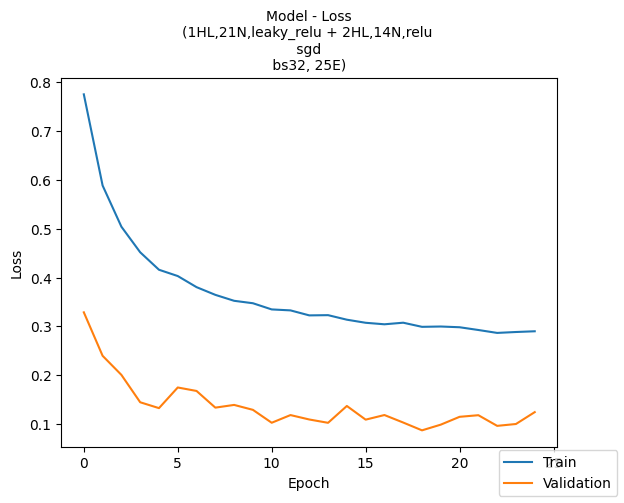

In [ ]:
plot(history,'loss', model_3_config)

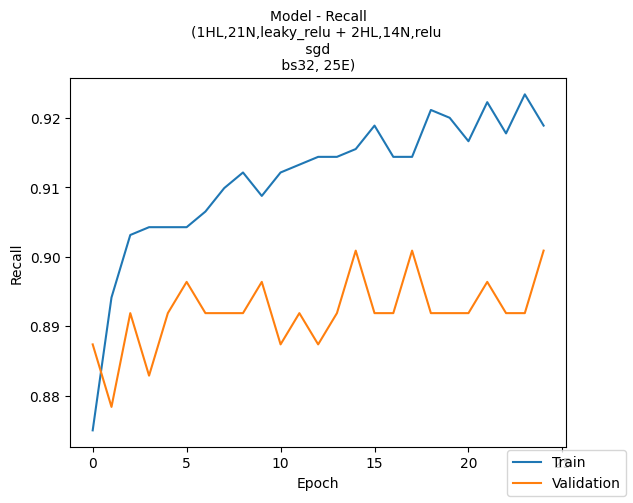

In [ ]:
plot(history,'Recall', model_3_config)

In [ ]:
model_3_train_perf = model_performance_classification(model_3,X_train,y_train)
model_3_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.976688,0.95374,0.861484,0.901498


In [ ]:
model_3_val_perf = model_performance_classification(model_3,X_val,y_val)
model_3_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9765,0.940922,0.864696,0.898597


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[4625   93]
 [  35  247]]


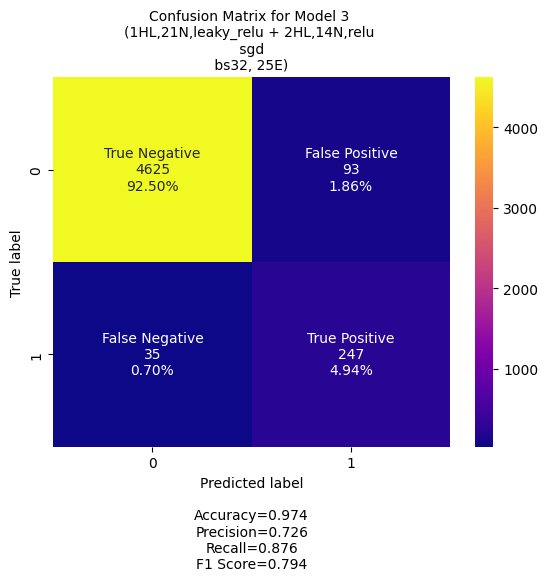

In [ ]:
# Evaluate model performance on the test set and visualize the confusion matrix.
y_test_pred = model_3.predict(X_test)
for i in range(len(y_test)):
    if y_test_pred[i]>0.5:
        y_test_pred[i]=1
    else:
        y_test_pred[i]=0

cm2=confusion_matrix(y_test, y_test_pred)
make_confusion_matrix(
    cm2,
    cmap='plasma',
    title="Confusion Matrix for Model 3 \n" + model_3_config
    )

## Model 4: Initialize Weights with he_normal

In [ ]:
# Define model configuration string to use in the title of graphs
model_4_config = "(1HL,21N,leaky_relu,he_normal + 2HL,14N,relu,he_normal \n sgd \n bs32, 50E) "

In [ ]:
# Initializing the sequential model
model_4 = Sequential()

# Add the first hidden layer with 7 neurons, ReLU activation, and input dimension matching the number of features in X_train
model_4.add(Dense(21, activation="leaky_relu",kernel_initializer='he_normal', input_dim=X_train.shape[1]))

# Additional hidden layer with 14 neurons, ReLU activation
model_4.add(Dense(14, activation="relu", kernel_initializer='he_normal'))

# Add the output layer with 1 neuron and sigmoid activation for binary classification probability output
model_4.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 21)             │           861 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 14)             │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,184 (4.62 KB)

 Trainable params: 1,184 (4.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define SGD as the optimizer to be used
optimizer = tf.keras.optimizers.SGD()

# Recall is the chosen metric to measure
model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [ ]:
start = time.time()
history = model_4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - Recall: 0.8626 - loss: 0.8119 - val_Recall: 0.8559 - val_loss: 0.2967
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.8795 - loss: 0.5743 - val_Recall: 0.8559 - val_loss: 0.2104
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8896 - loss: 0.4958 - val_Recall: 0.8604 - val_loss: 0.1689
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8964 - loss: 0.4467 - val_Recall: 0.8874 - val_loss: 0.1981
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9009 - loss: 0.4106 - val_Recall: 0.8874 - val_loss: 0.1535
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8998 - loss: 0.3967 - val_Recall: 0.8874 - val_loss: 0.1616
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.9020 - loss: 0.3817 - val_Recall: 0.8919 - val_loss: 0.1446
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.9009 - loss: 0.3720 - val_Recall: 0.8919 - val_loss: 0.1377
Epoch 9/

In [ ]:
print("Time taken in seconds ",end - start)

Time taken in seconds  42.949591636657715


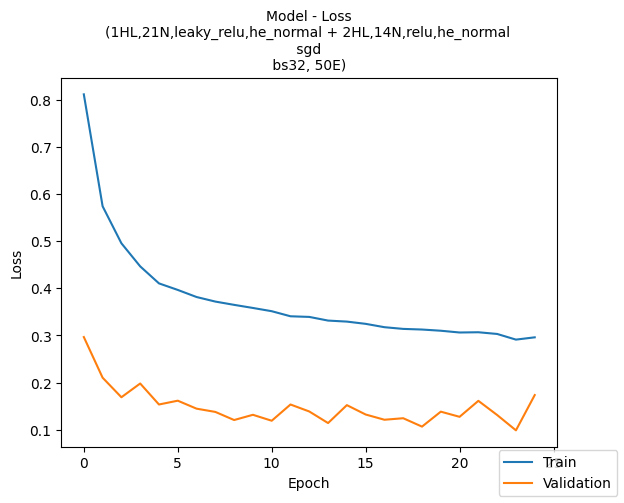

In [ ]:
plot(history,'loss', model_4_config)

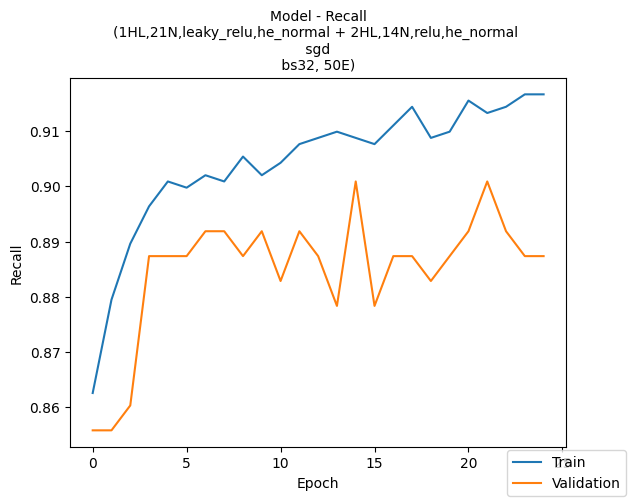

In [ ]:
plot(history,'Recall', model_4_config)

In [ ]:
model_4_train_perf = model_performance_classification(model_4,X_train,y_train)
model_4_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9605,0.944641,0.793819,0.85065


In [ ]:
model_4_val_perf = model_performance_classification(model_4,X_val,y_val)
model_4_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.95475,0.923048,0.775609,0.83042


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[4541  177]
 [  35  247]]


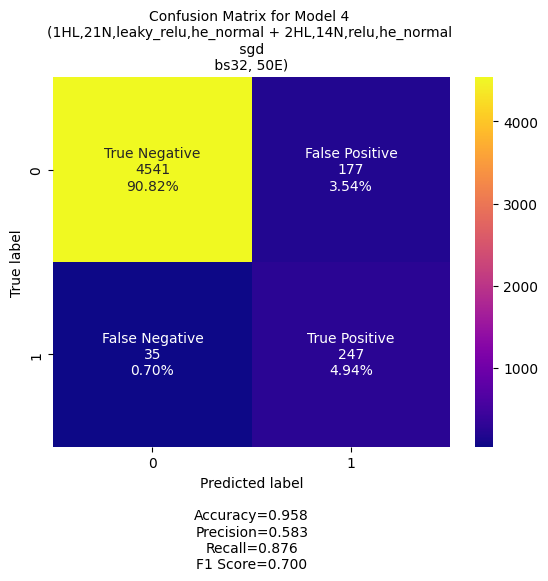

In [ ]:
# Evaluate model performance on the test set and visualize the confusion matrix.
y_test_pred = model_4.predict(X_test)
for i in range(len(y_test)):
    if y_test_pred[i]>0.5:
        y_test_pred[i]=1
    else:
        y_test_pred[i]=0

cm2=confusion_matrix(y_test, y_test_pred)
make_confusion_matrix(
    cm2,
    cmap='plasma',
    title="Confusion Matrix for Model 4 \n" + model_4_config
    )

## Model 5: Add Momentum

In [ ]:
# Define model configuration string to use in the title of graphs
model_5_config = "(1HL,21N,leaky_relu,he_normal + 2HL,14N,relu,he_normal \n sgd,mom \n bs32, 50E) "

In [ ]:
# Initializing the sequential model
model_5 = Sequential()

# Add the first hidden layer with 7 neurons, ReLU activation, and input dimension matching the number of features in X_train
model_5.add(Dense(21, activation="leaky_relu",kernel_initializer='he_normal', input_dim=X_train.shape[1]))

# Additional hidden layer with 14 neurons, ReLU activation
model_5.add(Dense(14, activation="relu", kernel_initializer='he_normal'))

# Add the output layer with 1 neuron and sigmoid activation for binary classification probability output
model_5.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_5.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 21)             │           861 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 14)             │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,184 (4.62 KB)

 Trainable params: 1,184 (4.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define SGD as the optimizer to be used
optimizer = tf.keras.optimizers.SGD(momentum=0.5)

# Recall is the chosen metric to measure
model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [ ]:
start = time.time()
history = model_5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - Recall: 0.8468 - loss: 0.7244 - val_Recall: 0.8919 - val_loss: 0.2610
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.8919 - loss: 0.5062 - val_Recall: 0.8829 - val_loss: 0.2002
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - Recall: 0.8986 - loss: 0.4366 - val_Recall: 0.9054 - val_loss: 0.1978
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - Recall: 0.9020 - loss: 0.4012 - val_Recall: 0.8874 - val_loss: 0.1801
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.8998 - loss: 0.3785 - val_Recall: 0.8964 - val_loss: 0.2059
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - Recall: 0.9054 - loss: 0.3622 - val_Recall: 0.8829 - val_loss: 0.1061
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.9065 - loss: 0.3502 - val_Recall: 0.9009 - val_loss: 0.2230
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9077 - loss: 0.3456 - val_Recall: 0.8919 - val_loss: 0.1208
Epoch 9/

In [ ]:
print("Time taken in seconds ",end - start)

Time taken in seconds  47.73054790496826


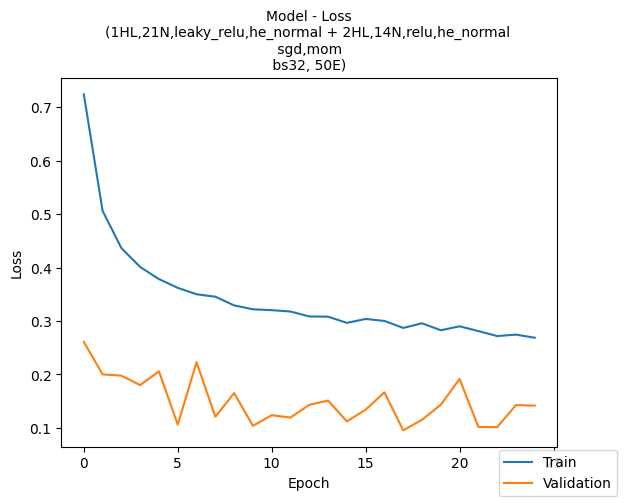

In [ ]:
plot(history,'loss', model_5_config)

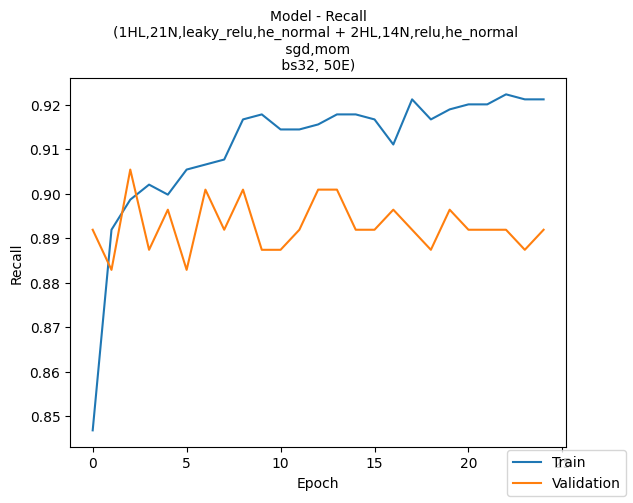

In [ ]:
plot(history,'Recall', model_5_config)

In [ ]:
model_5_train_perf = model_performance_classification(model_5,X_train,y_train)
model_5_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9695,0.949405,0.828054,0.877491


In [ ]:
model_5_val_perf = model_performance_classification(model_5,X_val,y_val)
model_5_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9665,0.931388,0.818178,0.864616


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[4582  136]
 [  39  243]]


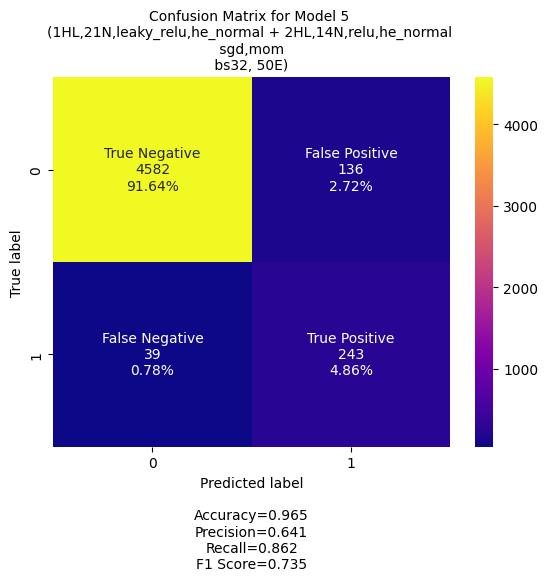

In [ ]:
# Evaluate model performance on the test set and visualize the confusion matrix.
y_test_pred = model_5.predict(X_test)
for i in range(len(y_test)):
    if y_test_pred[i]>0.5:
        y_test_pred[i]=1
    else:
        y_test_pred[i]=0

cm2=confusion_matrix(y_test, y_test_pred)
make_confusion_matrix(
    cm2,
    cmap='plasma',
    title="Confusion Matrix for Model 5 \n" + model_5_config
    )

## Model 6: Use Optimizer Adam

In [ ]:
# Define model configuration string to use in the title of graphs
model_6_config = "(1HL,21N,leaky_relu,he_normal + 2HL,14N,relu,he_normal + 3HL,7N,relu \n adam \n bs32,50E) "

In [ ]:
# Initializing the sequential model
model_6 = Sequential()

# Add the first hidden layer with 7 neurons, ReLU activation, and input dimension matching the number of features in X_train
model_6.add(Dense(21, activation="leaky_relu",kernel_initializer='he_normal', input_dim=X_train.shape[1]))

# Additional hidden layer with 14 neurons, ReLU activation
model_6.add(Dense(14, activation="relu", kernel_initializer='he_normal'))

# Additional hidden layer with 7 neurons, ReLU activation
model_6.add(Dense(7, activation="relu"))

# Add the output layer with 1 neuron and sigmoid activation for binary classification probability output
model_6.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_6.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 21)             │           861 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 14)             │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define Adam as the optimizer to be used
optimizer = tf.keras.optimizers.Adam()

# Recall is the chosen metric to measure
model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [ ]:
start = time.time()
history = model_6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - Recall: 0.8288 - loss: 0.8765 - val_Recall: 0.8604 - val_loss: 0.2934
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - Recall: 0.8874 - loss: 0.5218 - val_Recall: 0.8604 - val_loss: 0.2004
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - Recall: 0.8851 - loss: 0.4513 - val_Recall: 0.8694 - val_loss: 0.1785
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.8930 - loss: 0.4126 - val_Recall: 0.8649 - val_loss: 0.1528
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - Recall: 0.9009 - loss: 0.3794 - val_Recall: 0.8739 - val_loss: 0.1566
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - Recall: 0.9054 - loss: 0.3628 - val_Recall: 0.8919 - val_loss: 0.1454
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - Recall: 0.9054 - loss: 0.3510 - val_Recall: 0.8784 - val_loss: 0.1274
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - Recall: 0.9065 - loss: 0.3385 - val_Recall: 0.8964 - val_loss: 0.1308
Epoch 9

In [ ]:
print("Time taken in seconds ",end - start)

Time taken in seconds  56.653573751449585


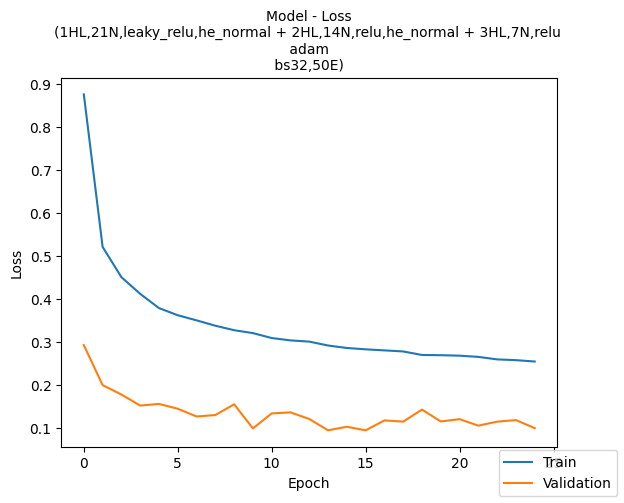

In [ ]:
plot(history,'loss', model_6_config)

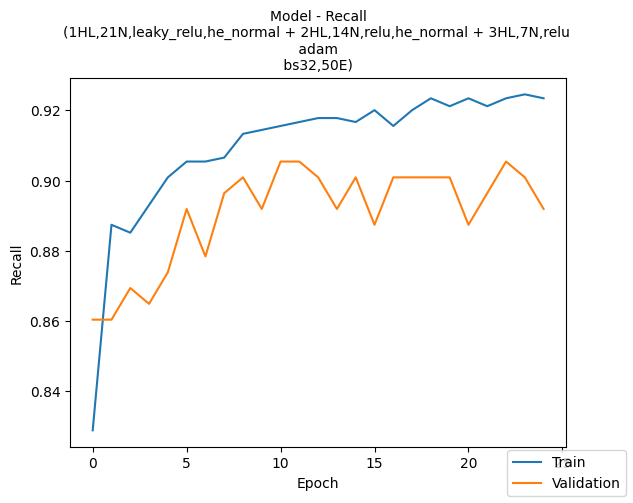

In [ ]:
plot(history,'Recall', model_6_config)

In [ ]:
model_6_train_perf = model_performance_classification(model_6,X_train,y_train)
model_6_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9895,0.959463,0.942616,0.95086


In [ ]:
model_6_val_perf = model_performance_classification(model_6,X_val,y_val)
model_6_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98775,0.942637,0.940769,0.941701


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[4685   33]
 [  37  245]]


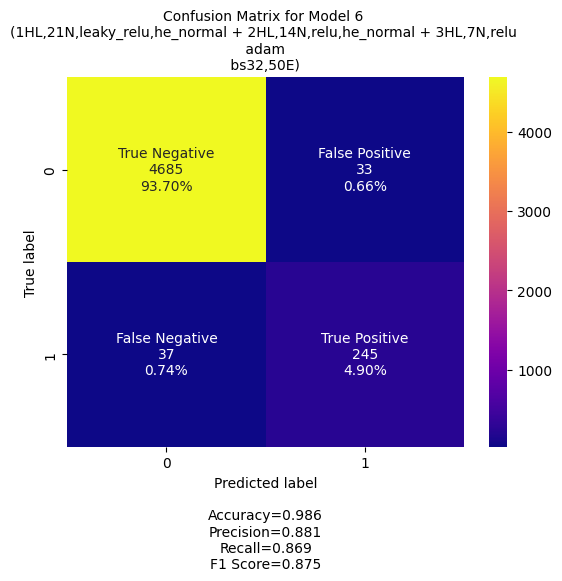

In [ ]:
# Evaluate model performance on the test set and visualize the confusion matrix.
y_test_pred = model_6.predict(X_test)
for i in range(len(y_test)):
    if y_test_pred[i]>0.5:
        y_test_pred[i]=1
    else:
        y_test_pred[i]=0

cm2=confusion_matrix(y_test, y_test_pred)
make_confusion_matrix(
    cm2,
    cmap='plasma',
    title="Confusion Matrix for Model 6 \n" + model_6_config
    )

# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [ ]:
# Create a dataframe of train set performaces

models_train_comp_df = pd.concat(
    [
        model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6",
]

In [ ]:
# Create a dataframe of val set performaces
models_val_comp_df = pd.concat(
    [
        model_0_val_perf.T,
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
        model_6_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6",
]

In [ ]:
print("Training set performance comparison:")
models_train_comp_df

Training set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.954937,0.972938,0.964875,0.976688,0.960500,0.969500,0.989500
Recall,0.928977,0.937446,0.932118,0.953740,0.944641,0.949405,0.959463
Precision,0.776121,0.846807,0.811322,0.861484,0.793819,0.828054,0.942616
F1 Score,0.832399,0.885969,0.860009,0.901498,0.850650,0.877491,0.950860


In [ ]:
print("Validation set performance comparison:")
models_val_comp_df

Validation set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.954250,0.974250,0.967250,0.976500,0.954750,0.966500,0.987750
Recall,0.922783,0.929131,0.925425,0.940922,0.923048,0.931388,0.942637
Precision,0.774035,0.856158,0.822439,0.864696,0.775609,0.818178,0.940769
F1 Score,0.829095,0.888677,0.865522,0.898597,0.830420,0.864616,0.941701




*   Model 3 and Model 6 exhibit comparable performance metrics
*   Model 6 exhibits overfitting since validation recall is lower than training recall by 2%
*   Model 3 and Model 4 show the same percentage of false negatives
*   Generalization (difference between validation recall and training recall) is 0.024 for Model 4, 0.02 for Model 6 and 0.014 for Model 3.
* We choose Model 3 for its low indices of false negatives, good generalization, and high recall on training and validation sets.





Now, let's check the performance of the final model on the test set.

In [ ]:
# Selecting Model_3 as the final best model.
best_model = model_3

In [ ]:
# Test set performance for the best model
best_model_test_perf = model_performance_classification(best_model, X_test, y_test)
best_model_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9744,0.928087,0.85948,0.890282


In [ ]:
from sklearn.metrics import classification_report

# Derive classification_report
y_test_pred_best = best_model.predict(X_test)

# Check the classification report of best model on test data.
cr_test_best_model = classification_report(y_test, y_test_pred_best>0.5)
print(cr_test_best_model)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4718
           1       0.73      0.88      0.79       282

    accuracy                           0.97      5000
   macro avg       0.86      0.93      0.89      5000
weighted avg       0.98      0.97      0.98      5000



# **Actionable Insights and Recommendations**

Write down some insights and business recommendations based on your observations.

* Model 3 demonstrates the best predictive measures with 0.98 recall for class 0 and 0.88 recall for class 1, as well as 0.94 recall for the validation set and 0.95 recall for training set.
* There is opportunity to develop further models to imrpove recall beyond, Renewind should invest in computation to hyperparameter tune the models.
* Renewind should implement Model 3 in order to optimize cost in their replacement vs repair costs, maximizing repair opportunities as opposed to the higher-cost replacement option.
* Real time sensorial monitors should be installed in generators in order to trigger alert systems for high risk generators.
* Preemptive maintenance should be institued and inspections should be constant to avoid more repairs and replacements, catching failures early is essential to prevent down time costs and revenue loss.